# VSE Simulation — standalone notebook

This notebook reproduces the **Voter Satisfaction Efficiency (VSE)** simulation methodology from the [`vse-sim`](https://github.com/electionscience/vse-sim) project for five voting systems — Plurality, Approval, IRV, STAR, and Condorcet (Schulze only; Ranked Pairs is dropped) — and extends it with three new sources of realistic voter degradation (epistemic noise, unfamiliarity, and ballot fatigue) and two new top-2 runoff hybrid methods (Approval Top 2 and Plurality Top 2).

**Standalone:** no dependency on the `vse-sim` package — every voter model, ballot rule, and the VSE formula itself are vendored directly into this notebook's own cells (Section 1), unmodified from the original project's code. Only `numpy`, `scipy`, and `matplotlib` are required.


## How this notebook is organized

The notebook proceeds in four parts: **(1)** a vendored, unmodified copy of the `vse-sim` methodology and the five baseline voting methods (Section 1); **(2)** the three new degradation mechanisms — epistemic noise and participation friction (unfamiliarity + ballot fatigue) — plus the four new top-2/top-3 runoff hybrid methods; **(3)** the simulation loop, baseline results, and a sanity check against `vse-sim`'s own published numbers; **(4)** the sweeps and diagnostics that produce this notebook's findings — individual and joint parameter sweeps, the runoff information-quality sweep, and the per-election runoff-betrayal diagnostic.


## 1. Vendored library

The code below is copied, with one small addition, from the `vse_sim` Python package at [electionscience/vse-sim](https://github.com/electionscience/vse-sim): the `Method` base class and VSE formula, the electorate/voter models needed for the "kitchen sink" (`KSModel`) model used for every published VSE number, the strategic-voting and media-noise machinery, and the 5 baseline voting methods. Anything only needed by voting methods this notebook doesn't use (Ranked Pairs, Majority Judgment, Borda, 3-2-1, IRNR, ...) is omitted.

**One deliberate modification:** `Method.resultsTable`/`vseOn` gain an optional `scoring_voters` parameter, used starting in Section 2.


### 1.1 Setup: shared imports

In [320]:
import random
import math
import time
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import Markdown, display


### 1.2 Utility decorators (from `decorators.py`)

In [321]:
from functools import update_wrapper, wraps
from inspect import getfullargspec, isfunction
from itertools import starmap


def decorator(d):
    """Make function d a decorator: d wraps a function fn."""
    def _d(fn):
        return update_wrapper(d(fn), fn)
    return _d
decorator = decorator(decorator)(decorator)


@decorator
def autoassign(*names, **kwargs):
    """
    autoassign(function) -> method
    autoassign(*argnames) -> decorator
    autoassign(exclude=argnames) -> decorator.

    Lets a method assign (some of) its arguments as attributes of ``self``
    automatically -- used throughout below instead of writing out
    ``self.x = x`` for every constructor argument.
    """
    if kwargs:
        exclude, f = set(kwargs['exclude']), None
        def sieve(values):
            return filter(lambda nv: nv[0] not in exclude, values)
    elif len(names) == 1 and isfunction(names[0]):
        f = names[0]
        def sieve(values):
            return values
    else:
        names, f = set(names), None
        def sieve(values):
            return [nv for nv in values if nv[0] in names]
    def decorator(f):
        spec = getfullargspec(f)
        fargnames, fdefaults = spec.args, spec.defaults
        fargnames, fdefaults = fargnames[1:], fdefaults or ()
        defaults = list(sieve(zip(reversed(fargnames), reversed(fdefaults), strict=False)))
        @wraps(f)
        def decorated(self, *args, **kwargs):
            assigned = dict(sieve(zip(fargnames, args, strict=False)))
            assigned.update(sieve(kwargs.items()))
            for _ in starmap(assigned.setdefault, defaults):
                pass
            self.__dict__.update(assigned)
            return f(self, *args, **kwargs)
        return decorated
    return f and decorator(f) or decorator


_missing = object()

@decorator
class cached_property(object):
    """Converts a function into a lazy property: computed once, then cached
    on the instance's own __dict__."""

    def __init__(self, func, name=None, doc=None):
        self.__name__ = name or func.__name__
        self.__module__ = func.__module__
        self.__doc__ = doc or func.__doc__
        self.func = func

    def __get__(self, obj, type=None):
        if obj is None:
            return self
        value = obj.__dict__.get(self.__name__, _missing)
        if value is _missing:
            value = self.func(obj)
            obj.__dict__[self.__name__] = value
        return value


### 1.3 Core: `Method` base class & VSE formula (from `core.py`)

`Method` is the shared base every voting method below subclasses. `normalized_vse` is the VSE formula this notebook reports throughout:
`vse = (util - rand) / (best - rand)`, where `best`/`rand` are the electorate's true mean social utility for the best and a random candidate.

`resultsTable`/`vseOn` accept an optional `scoring_voters` electorate: when ballots are cast on a *perceived* (possibly noisy) electorate but VSE should be scored against *true* utilities, the true electorate is passed as `scoring_voters` (Section 2).


In [322]:
from dataclasses import dataclass, field

from numpy import isclose, mean


def isnum(x):
    """Test whether an object is an instance of a built-in numeric type."""
    return next((1 for T in (int, float, complex) if isinstance(x, T)), 0)


class VseOneRun:
    @autoassign
    def __init__(self, result, tallyItems, strat):
        pass


class VseMethodRun:
    @autoassign
    def __init__(self, method, choosers, results):
        pass


@dataclass
class ElectionContext:
    """Mutable metadata scoped to one method instance and election."""
    extra_events: dict = field(default_factory=dict)


def normalized_vse(utility, best, random_baseline):
    """Normalize utility to VSE.

    When every candidate has the same social utility there is no possible
    improvement over random selection, so every method receives neutral VSE.
    """
    denominator = best - random_baseline
    if isclose(denominator, 0):
        return 0.0
    return (utility - random_baseline) / denominator


class SideTally(defaultdict):
    """Tracks how many voters are being strategic, etc.

    DO NOT use plain +; for this class it is equivalent to +=, but less readable.
    """
    def __init__(self):
        super().__init__(int)
        self._keys_initialized = False

    def initKeys(self, chooser):
        if self._keys_initialized:
            return
        try:
            self.keyList = chooser.allTallyKeys()
        except AttributeError:
            try:
                self.keyList = list(chooser)
            except TypeError:
                pass
        self._keys_initialized = True

    def serialize(self):
        try:
            return [self[key] for key in self.keyList]
        except AttributeError:
            return []

    def fullSerialize(self):
        try:
            return ([self[key] for key in self.keyList] +
                    [self[key] for key in self.keys() if key not in self.keyList])
        except AttributeError:
            return [self[key] for key in self.keys()]

    def itemList(self):
        try:
            kl = self.keyList
            return ([(k, self[k]) for k in kl] +
                    [(k, self[k]) for k in self.keys() if k not in kl])
        except AttributeError:
            return list(self.items())


class Tallies(list):
    """Used (ONCE) as an enumerator: gives an inexhaustible flow of SideTally
    objects. After that, use as a list to see those objects."""
    def __iter__(self):
        if hasattr(self, "used"):
            return super().__iter__()
        self.used = True
        return self

    def __next__(self):
        tally = SideTally()
        self.append(tally)
        return tally


class Method:
    """Base class for election methods. Holds some of the duct tape."""

    def __init__(self):
        self.context = ElectionContext()

    @property
    def extraEvents(self):
        """Compatibility view of metadata for this method's current election."""
        return self.context.extra_events

    @extraEvents.setter
    def extraEvents(self, value):
        self.context.extra_events = value

    def __str__(self):
        return self.__class__.__name__

    def results(self, ballots, **kwargs):
        """Combines ballots into results. Override for comparative methods."""
        if type(ballots) is not list:
            ballots = list(ballots)
        return list(map(self.candScore, zip(*ballots, strict=False)))

    @staticmethod  # cls is provided explicitly, not through binding
    def honBallot(cls, utils):
        """Takes utilities and returns an honest ballot."""
        raise NotImplementedError(f"{cls} needs honBallot")

    @staticmethod
    def winner(results):
        """Find the winner once scores are already calculated. Override for
        ranked methods."""
        winScore = max(result for result in results if isnum(result))
        winners = [cand for (cand, score) in enumerate(results) if score == winScore]
        return random.choice(winners)

    def honBallotFor(self, voters):
        """This is where you'd do any setup necessary and create an honBallot
        function. The base version just returns honBallot."""
        return self.honBallot

    def dummyBallotFor(self, polls):
        return lambda cls, utilities, stratTally: utilities

    def resultsFor(self, voters, chooser, tally=None, **kwargs):
        """Create ballots and get results."""
        if tally is None:
            tally = SideTally()
        tally.initKeys(chooser)
        return dict(results=self.results([chooser(self.__class__, voter, tally)
                                  for voter in voters],
                              **kwargs),
                chooser=chooser.__name__,
                tally=tally)

    def multiResults(self, voters, chooserFuns=(), media=(lambda x, t: x),
                checkStrat=True):
        """Runs the honest election, then the strategic election (based on the
        honest results filtered through media), then one-sided-strategic,
        'smart' one-sided, and any caller-supplied chooserFuns."""
        honTally = SideTally()
        self.context = ElectionContext()
        hon = self.resultsFor(voters, self.honBallotFor(voters), honTally, isHonest=True)

        stratTally = SideTally()
        polls = media(hon["results"], stratTally)
        winner, _w, target, _t = self.stratTargetFor(sorted(enumerate(polls), key=lambda x: -x[1]))

        strat = self.resultsFor(voters, self.stratBallotFor(polls), stratTally)

        ossTally = SideTally()
        oss = self.resultsFor(voters, self.ballotChooserFor(OssChooser()), ossTally)
        ossWinner = oss["results"].index(max(oss["results"]))
        ossTally["worked"] += (1 if ossWinner == target else
                                    (0 if ossWinner == winner else -1))

        smart = dict(results=(hon["results"] if ossTally["worked"] == 1 else oss["results"]),
                chooser="smartOss",
                tally=SideTally())

        extraTallies = Tallies()
        results = ([strat, oss, smart] +
                [self.resultsFor(voters, self.ballotChooserFor(chooserFun), aTally)
                    for (chooserFun, aTally) in zip(chooserFuns, extraTallies, strict=False)]
                  )
        return ([(hon["results"], hon["chooser"], list(self.extraEvents.items()))] +
                [(r["results"], r["chooser"], r["tally"].itemList()) for r in results])

    def vseOn(self, voters, chooserFuns=(), scoring_voters=None, perceived_voters=None,
              genuine_sets=None, primary_awareness_alpha=None, **args):
        """Finds honest and strategic VSE for this method on the given electorate.

        `scoring_voters` -- CHECKPOINT-2 ADDITION, not in the original: the
        electorate whose socUtils defines ground truth for VSE scoring.
        Defaults to `voters` (the original behavior) when not given -- pass a
        separate true electorate here when `voters` is a noisy *perceived*
        electorate (see make_perceived_electorate below), so ballots are cast
        on perception while VSE is still scored against ground truth.

        `perceived_voters` -- the primary's own perceived electorate (post-epistemic-noise,
        pre-participation-friction), i.e. `voters` before apply_participation_friction ran on
        it. Exposed for Top2Base's runoff_t=None case, which needs the primary's noise
        level without its friction baked in -- see Top2Base._runoff_electorate above.

        `genuine_sets` -- the per-voter genuinely-evaluated candidate sets returned alongside
        `voters` by apply_participation_friction (None if friction wasn't applied). Every method
        except Irv ignores this; Irv.honBallotFor reads it for honest-ballot exhaustion.

        `primary_awareness_alpha` -- the raw `awareness_alpha` value used to build this election's
        ballot electorate (a number, not an electorate). Every method except Top2Base's
        `runoff_frozen=True` option ignores this; Frozen needs the primary's actual awareness
        level, not just its already-friction-processed electorate, since it reapplies friction
        fresh for the runoff at that same level with fatigue pinned to 1.0 (see
        Top2Base._runoff_electorate).
        """
        truth_voters = voters if scoring_voters is None else scoring_voters  # <-- checkpoint 2
        self._scoring_voters = truth_voters  # <-- checkpoint 3: exposed for Top2Base's noiseless-runoff option.
        self._perceived_voters = perceived_voters
        self._genuine_sets = genuine_sets
        self._primary_awareness_alpha = primary_awareness_alpha
        # Must be set BEFORE multiResults() runs -- results() (called from deep inside
        # multiResults, via resultsFor) reads self._scoring_voters for this same election;
        # setting it after multiResults() returns would leave results() reading the PREVIOUS
        # election's true electorate (or None, on the very first call).
        multiResults = self.multiResults(voters, chooserFuns, **args)
        utils = truth_voters.socUtils
        best = max(utils)
        rand = mean(utils)

        vses = VseMethodRun(
            self.__class__,
            chooserFuns,
            [
                VseOneRun(
                    [normalized_vse(utils[self.winner(result)], best, rand)],
                    tally,
                    chooser,
                )
                for result, chooser, tally in multiResults
            ],
        )
        vses.extraEvents = dict(self.extraEvents)
        return vses

    def resultsTable(self, eid, emodel, cands, voters, chooserFuns=(), scoring_voters=None,
                      perceived_voters=None, genuine_sets=None, primary_awareness_alpha=None, **args):
        """As vseOn, but returns one CSV-row-shaped dict per chooser.
        See vseOn above for what `scoring_voters`, `perceived_voters`, `genuine_sets`, and
        `primary_awareness_alpha` do.
        """
        truth_voters = voters if scoring_voters is None else scoring_voters  # <-- checkpoint 2
        self._scoring_voters = truth_voters  # <-- checkpoint 3: exposed for Top2Base's noiseless-runoff option.
        self._perceived_voters = perceived_voters
        self._genuine_sets = genuine_sets
        self._primary_awareness_alpha = primary_awareness_alpha
        # Must be set BEFORE multiResults() runs -- see the identical note in vseOn above.
        multiResults = self.multiResults(voters, chooserFuns, **args)
        utils = truth_voters.socUtils
        best = max(utils)
        rand = mean(utils)
        rows = []
        nvot = len(voters)
        for (result, chooser, tallyItems) in multiResults:
            winner = self.winner(result)
            utility = utils[winner]
            row = {
                "eid": eid,
                "emodel": emodel,
                "ncand": cands,
                "nvot": nvot,
                "best": best,
                "rand": rand,
                "method": str(self),
                "chooser": chooser,
                "winner": winner,  # checkpoint-4 addition: ground-truth Condorcet efficiency
                                   # needs to know which candidate a method actually elected.
                "util": utility,
                "vse": normalized_vse(utility, best, rand),
            }
            for (i, (k, v)) in enumerate(tallyItems):
                row[f"tallyName{str(i)}"] = str(k)
                row[f"tallyVal{str(i)}"] = str(v)
            rows.append(row)
        return rows

    @staticmethod
    def ballotChooserFor(chooserFun):
        """Takes a chooserFun; returns a ballot chooser using that chooserFun."""
        def ballotChooser(cls, voter, tally):
            return getattr(voter, f"{cls.__name__}_{chooserFun(cls, voter, tally)}")

        ballotChooser.__name__ = chooserFun.getName()
        return ballotChooser

    def stratTarget2(self, places):
        ((frontId, frontResult), (targId, targResult)) = places[:2]
        return (frontId, frontResult, targId, targResult)

    def stratTarget3(self, places):
        ((frontId, frontResult), (targId, targResult)) = places[:3:2]
        return (frontId, frontResult, targId, targResult)

    stratTargetFor = stratTarget2

    def stratBallotFor(self, polls):
        """Returns a (function which takes utilities and returns a strategic
        ballot) for the given 'polling' info."""
        places = sorted(enumerate(polls), key=lambda x: -x[1])  # high to low
        (frontId, frontResult, targId, targResult) = self.stratTargetFor(places)
        n = len(polls)
        @rememberBallots
        def stratBallot(cls, voter):
            stratGap = voter[targId] - voter[frontId]
            ballot = [0] * len(voter)
            isStrat = stratGap > 0
            extras = cls.fillStratBallot(voter, polls, places, n, stratGap, ballot,
                                frontId, frontResult, targId, targResult)
            result = dict(strat=ballot, isStrat=isStrat, stratGap=stratGap)
            if extras:
                result.update(extras)
            return result
        return stratBallot


@decorator
def rememberBallot(fun):
    """Decorator for a function xxxBallot(cls, voter) which memoizes the vote
    onto the voter in an attribute named <methName>_xxx."""
    def getAndRemember(cls, voter, tally=None):
        ballot = fun(cls, voter)
        setattr(voter, f"{cls.__name__}_{fun.__name__[:-6]}", ballot)
        return ballot

    getAndRemember.__name__ = fun.__name__
    getAndRemember.allTallyKeys = lambda: []
    return getAndRemember


@decorator
def rememberBallots(fun):
    """As rememberBallot, but fun returns a dict of {ballotType: ballot}."""
    def getAndRemember(cls, voter, tally=None):
        ballots = fun(cls, voter)
        for bType, ballot in ballots.items():
            setattr(voter, f"{cls.__name__}_{bType}", ballot)
        return ballots[fun.__name__[:-6]]  # leave off the "...Ballot"

    getAndRemember.__name__ = fun.__name__
    getAndRemember.allTallyKeys = lambda: []
    return getAndRemember


class CandidateWithCount:
    def __init__(self, c=[], v=0):
        self.candidate = c
        self.votes = v


### 1.4 Voter models (from `voter_models.py`, trimmed to what `KSModel` needs)

`KSModel` ("kitchen sink") is the hierarchical-cluster electorate model used to generate every
published VSE number in the original project: issue dimensions are grouped into nested "issue
clusters," voters are assigned to per-cluster "identity clusters" via a Chinese-restaurant
process, and each identity cluster has its own mean position and caring level. `RandomModel` is
also included below (needed as `KSModel`'s own base electorate) — it's the simpler "Impartial
Culture" model (independent random utilities) if you want to compare against it.


In [323]:
from numpy import mean
from numpy.lib.scimath import sqrt
from scipy.stats import beta


class Voter(tuple):
    """A tuple of candidate utilities."""

    def __new__(cls, utilities=()):
        return super().__new__(
            cls, (utility.item() if hasattr(utility, "item") else utility for utility in utilities)
        )

    @classmethod
    def rand(cls, ncand):
        """Create a random voter with an independent standard normal utility
        for each candidate."""
        return cls(random.gauss(0, 1) for _ in range(ncand))

    def hybridWith(self, v2, w2):
        """Create a weighted average of two voters. The weight of self is
        always 1; w2 is v2's weight relative to that. If both are standard
        normal to start with, the result will be standard normal too."""
        assert len(self) == len(v2)
        return self.copyWithUtils((self[i] / sqrt(1 + w2 ** 2)) +
                                    (w2 * v2[i] / sqrt(1 + w2 ** 2))
                                 for i in range(len(self)))

    def copyWithUtils(self, utils):
        """Create a new voter with attrs as self and given utils."""
        return self.__class__(utils)

    def mutantChild(self, muteWeight):
        """Returns a copy hybridized with a random voter of weight muteWeight."""
        return self.hybridWith(self.__class__.rand(len(self)), muteWeight)


class PersonalityVoter(Voter):

    cluster_count = 0

    def __init__(self, *args, **kw):
        super().__init__()
        self.cluster = self.__class__.cluster_count
        self.__class__.cluster_count += 1
        self.personality = random.gauss(0, 1)

    @classmethod
    def resetClusters(cls):
        cls.cluster_count = 0

    def copyWithUtils(self, utils):
        voter = super().copyWithUtils(utils)
        voter.copyAttrsFrom(self)
        return voter

    def copyAttrsFrom(self, model):
        self.personality = model.personality
        self.cluster = model.cluster


class Electorate(list):
    """A list of voters. Each voter is a list of candidate utilities."""
    @cached_property
    def socUtils(self):
        """Mean utility across the electorate for each candidate: the
        candidates' social utilities."""
        return [value.item() for value in map(mean, zip(*self, strict=False))]


class RandomModel:
    """Electorate factory implementing 'Impartial Culture': every voter gets
    an independent random utility for each candidate."""

    def __str__(self):
        return self.__class__.__name__

    def __call__(self, nvot, ncand, vType=PersonalityVoter):
        return Electorate(vType.rand(ncand) for _ in range(nvot))


class DimVoter(PersonalityVoter):
    """A voter in an n-dimensional ideology model."""

    @classmethod
    def fromDims(cls, v, e, caring=None):
        if caring is None:
            caring = [1] * len(v)
            totCaring = e.totWeight
        else:
            totCaring = sum((c * w) ** 2 for c, w in zip(caring, e.dimWeights, strict=False))
        me = cls(-sqrt(
            sum(((vd - cd) * w * cares) ** 2
                for (vd, cd, w, cares) in zip(v, c, e.dimWeights, caring, strict=False)) /
                            totCaring)
          for c in e.cands)
        me.copyAttrsFrom(v)
        me.dims = v
        me.elec = e
        return me


class DimElectorate(Electorate):

    def asDims(self, v, *args):
        return v

    def fromDims(self, dimvoters, vType):
        for v in dimvoters:
            self.append(vType.fromDims(v, self))

    def calcTotWeight(self):
        self.totWeight = sum(w ** 2 for w in self.dimWeights)


class DimModel(RandomModel):
    """N-dimensional ideology model: voters and candidates each get a
    position in n-dimensional space; utility falls off with distance."""

    builtElectorate = DimElectorate

    @autoassign
    def __init__(self, ndims=3, dimWeights=None, baseElectorate=RandomModel()):
        if self.dimWeights is None:
            self.dimWeights = [2 ** (-n) for n in range(ndims)]
        assert len(self.dimWeights) == self.ndims

    def __call__(self, nvot, ncand, vType=DimVoter):
        elec = self.builtElectorate()
        elec.dimWeights = self.dimWeights
        return self.makeElectorate(elec, nvot, ncand, vType)

    def makeElectorate(self, elec, nvot, ncand, vType):
        elec.calcTotWeight()
        votersncands = self.baseElectorate(nvot + ncand, len(elec.dimWeights), vType)
        elec.base = [elec.asDims(v, i) for i, v in enumerate(votersncands[:nvot])]
        elec.cands = [elec.asDims(v, nvot + i) for i, v in enumerate(votersncands[nvot:])]
        elec.fromDims(elec.base, vType)
        return elec


def rbeta(a, b):
    return lambda: beta.rvs(a, b)


class KSElectorate(DimElectorate):

    def chooseClusters(self, n, alpha, caring):
        self.clusters = []
        for i in range(n):
            item = []
            for c in range(self.numClusters):
                r = (i + alpha) * random.random()
                if r > i:
                    item.append(self.numSubclusters[c])
                    self.numSubclusters[c] += 1
                else:
                    item.append(self.clusters[int(r)][c])
            self.clusters.append(item)
        self.clusterMeans = []
        self.clusterCaring = []
        for c in range(self.numClusters):
            subclusterMeans = []
            subclusterCaring = []
            for _ in range(self.numSubclusters[c]):
                cares = caring()
                subclusterMeans.append(
                    [random.gauss(0, sqrt(cares)) for _ in range(self.dcs[c])]
                )
                subclusterCaring.append(caring())
            self.clusterMeans.append(subclusterMeans)
            self.clusterCaring.append(subclusterCaring)

    def asDims(self, v, i):
        result = []
        cares = []
        for dim, c in enumerate(range(self.numClusters)):
            clusterMean = self.clusterMeans[c][self.clusters[i][c]]
            for m in clusterMean:
                acare = self.clusterCaring[c][self.clusters[i][c]]
                result.append(m + (v[dim] * sqrt(1 - acare)))
                cares.append(acare)
        v = PersonalityVoter(result)
        v.cares = cares
        return v

    def fromDims(self, dimvoters, vType):
        for v in dimvoters:
            self.append(vType.fromDims(v, self, v.cares))


class KSModel(DimModel):  # "Kitchen sink": hierarchical-cluster voter model
    """The hierarchical-cluster ('kitchen sink') voter model used for every
    published VSE number in this project."""

    builtElectorate = KSElectorate
    baseElectorate = RandomModel()

    @autoassign
    # dc = dimensional cluster; wc = within-cluster dimension
    def __init__(self, dcdecay=(1, 1), dccut=.2,
            wcdecay=(1, 1), wccut=.2,
            wcalpha=1, vccaring=(3, 1.5)):
        pass

    def __str__(self):
        return "_".join(str(x) for x in (self.__class__.__name__, self.wcalpha) + self.dcdecay + self.wcdecay + self.vccaring)

    def __call__(self, nvot, ncand, vType=DimVoter):
        vType.resetClusters()
        e = self.builtElectorate()
        e.dcs = []
        e.dimWeights = []
        clusterWeight = 1
        while clusterWeight > self.dccut:
            dimweight = clusterWeight
            dimnum = 0
            while dimweight > self.wccut:
                e.dimWeights.append(dimweight)
                dimnum += 1
                dimweight *= beta.rvs(*self.wcdecay)
            e.dcs.append(dimnum)
            clusterWeight *= beta.rvs(*self.dcdecay)
        e.numClusters = len(e.dcs)
        e.numSubclusters = [0] * e.numClusters
        e.chooseClusters(nvot + ncand, self.wcalpha, lambda: beta.rvs(*self.vccaring))
        return self.makeElectorate(e, nvot, ncand, vType)


### 1.5 Strategies: choosers & media noise (from `strategies.py`)

`Chooser`s decide which of a voter's already-computed ballots (honest, strategic, ...) actually
gets cast — e.g. `ProbChooser` makes a fixed fraction of voters strategic at random; `OssChooser`
implements "one-sided strategy" (only voters who prefer the runner-up strategize). Media
functions (`fuzzyMediaFor`, etc.) model imperfect *polling* information — a different kind of
uncertainty than the epistemic noise added in Section 2 below (see the note there).


In [324]:
from math import isclose as _math_isclose  # aliased: numpy.isclose is already bound to `isclose` above


class Chooser:
    """Choosers pick which of a voter's already-computed ballots (honest,
    strategic, ...) to actually cast."""
    tallyKeys = []

    @autoassign
    def __init__(self, choice, subChoosers=None):
        pass

    def getName(self):
        if hasattr(self, "choice"):  # only true for the base class
            return self.choice
        if not hasattr(self, "name") or not self.name:
            self.name = self.__class__.__name__[:-7]  # drop "Chooser"
        return self.name

    def __call__(self, cls, voter, tally):
        return self.choice

    def addTallyKeys(self, tally):
        for key in self.allTallyKeys:
            tally[key] = 0

    @cached_property
    def myKeys(self):
        prefix = f"{self.getName()}_"
        return [prefix + key for key in self.tallyKeys]

    @cached_property
    def allTallyKeys(self):
        keys = self.myKeys
        for subChooser in self.subChoosers:
            keys += subChooser.allTallyKeys
        return keys

    @cached_property
    def __name__(self):
        return self.__class__.__name__


beHon = Chooser("hon")
beStrat = Chooser("strat")
beX = Chooser("extraStrat")


class LazyChooser(Chooser):
    """Honest, if honest and strategic ballots are the same. Otherwise,
    extra-strategic."""
    tallyKeys = [""]

    @autoassign
    def __init__(self, subChoosers=None):
        if self.subChoosers is None:
            self.subChoosers = [beHon, beX]

    def __call__(self, cls, voter, tally):
        if getattr(voter, f"{cls.__name__}_hon") == getattr(voter, f"{cls.__name__}_strat"):
            tally[self.myKeys[0]] += 0
            return self.subChoosers[0](cls, voter, tally)
        tally[self.myKeys[0]] += 1
        return self.subChoosers[1](cls, voter, tally)


class OssChooser(Chooser):
    """One-sided strategy: strategic ballot for voters who prefer the
    strategic target, honest ballot for voters who prefer the honest
    winner."""
    tallyKeys = ["", "gap"]

    @autoassign
    def __init__(self, subChoosers=None):
        if self.subChoosers is None:
            self.subChoosers = [beHon, beStrat]

    def __call__(self, cls, voter, tally):
        hon, strat = self.subChoosers
        if not getattr(voter, f"{cls.__name__}_isStrat", False):
            return hon(cls, voter, tally) if callable(hon) else hon
        tally[self.myKeys[0]] += 1
        tally[self.myKeys[1]] += getattr(voter, f"{cls.__name__}_stratGap", 0)
        return strat(cls, voter, tally) if callable(strat) else strat

    def getName(self):
        baseName = super(OssChooser, self).getName()
        return f"{baseName}." + "_".join(s.getName() for s in self.subChoosers) + "."


class ProbChooser(Chooser):
    """A fixed fraction of voters (independently, at random) cast the
    strategic (or extra-strategic) ballot; the rest are honest."""

    @autoassign
    def __init__(self, probs):
        if not probs:
            raise ValueError("ProbChooser requires at least one choice")
        if any(probability < 0 for probability, _chooser in probs):
            raise ValueError("ProbChooser probabilities cannot be negative")
        if not _math_isclose(sum(probability for probability, _chooser in probs), 1.0):
            raise ValueError("ProbChooser probabilities must sum to 1")
        self.subChoosers = [chooser for (p, chooser) in probs]

    def __call__(self, cls, voter, tally):
        r = random.random()
        for (i, (p, chooser)) in enumerate(self.probs):
            r -= p
            if r < 0 or i == len(self.probs) - 1:
                if i > 0:
                    tally[f"{self.getName()}_{chooser.getName()}"] += 1
                return chooser(cls, voter, tally)

    def getName(self):
        baseName = super(ProbChooser, self).getName()
        return (
            f"{baseName}."
            + "_".join(s.getName() + str(round(p * 100)) for p, s in self.probs)
            + "."
        )


# ---- Media models: what voters/strategists know about how the race is polling ----

def truth(standings, tally=None):
    return standings


def topNMediaFor(n):
    def topNMedia(standings, tally=None):
        return list(standings[:n]) + [min(standings)] * (len(standings) - n)
    return topNMedia


def biaserAround(scale):
    def biaser(standings):
        return scale * np.std(standings, ddof=1)
    return biaser


def orderOf(standings):
    return [i for i, val in sorted(list(enumerate(standings)), key=lambda x: x[1], reverse=True)]


def fuzzyMediaFor(biaser=biaserAround(1)):
    def fuzzyMedia(standings, tally=None):
        if not tally:
            tally = SideTally()
        bias = biaser(standings) if callable(biaser) else biaser
        result = [s + random.gauss(0, bias) for s in standings]
        tally["changed"] += 0 if orderOf(result)[:2] == orderOf(standings)[:2] else 1
        return result
    return fuzzyMedia


def biasedMediaFor(biaser=biaserAround(1), numerator=1):
    def biasedMedia(standings, tally=None):
        if not tally:
            tally = SideTally()
        bias = biaser(standings) if callable(biaser) else biaser
        result = standings[:2] + [
            (standing - bias + numerator * (bias / max(i + 2, 1)))
            for i, standing in enumerate(standings[2:])
        ]
        tally["changed"] += 0 if orderOf(result)[:2] == orderOf(standings)[:2] else 1
        return result
    return biasedMedia


def skewedMediaFor(biaser):
    def skewedMedia(standings, tally=None):
        if not tally:
            tally = SideTally()
        bias = biaser(standings) if callable(biaser) else biaser
        result = [(standing - bias * i / (len(standings) - 1)) for i, standing in enumerate(standings)]
        tally["changed"] += 0 if orderOf(result)[:2] == orderOf(standings)[:2] else 1
        return result
    return skewedMedia


### 1.6 Voting methods: Plurality, Approval, IRV, STAR, Condorcet (Schulze)

`RankedMethod` (aliased `RatedMethod` in the original, despite that name actually being the base
for *ordinal*-ballot methods) is the shared base for Plurality and Schulze below.


In [325]:
# ---- methods/ranked.py ----

class RankedMethod(Method):
    """Base class for methods that use candidate-aligned rank vectors.
    Larger ballot values represent stronger preferences."""

    @staticmethod
    def fillPrefOrder(voter, ballot, whichCands=None, lowSlot=0, nSlots=None, remainderScore=None):
        """Fill ballot with candidates ordered by decreasing utility."""
        venum = list(enumerate(voter))
        if whichCands:
            venum = [venum[c] for c in whichCands]
        prefOrder = sorted(venum, key=lambda x: -x[1])
        RankedMethod.fillCands(ballot, prefOrder, lowSlot, nSlots, remainderScore)

    @staticmethod
    def fillCands(ballot, whichCands, lowSlot=0, nSlots=None, remainderScore=None):
        """Assign descending ranks to candidate tuples in whichCands.

        Candidates with EXACTLY EQUAL values (whichCands is presorted by fillPrefOrder, so
        ties are always adjacent) get the SAME rank, not distinct sequential ones -- needed
        so a genuine tie in the input (e.g. participation friction's floored/unaware
        candidates, which now all share one value -- see apply_participation_friction) is
        preserved as a real tie in the ballot for Schulze's sign()-based pairwise comparison
        to read as indifference, rather than being silently broken into an arbitrary strict
        order by whichCands's position. Ranks are consumed by GROUP SIZE, not by count, so
        the ranking stays consistent (e.g. a 3-way tie at the bottom occupies 3 slots' worth
        of "room" even though every tied candidate gets the same rank number). A tie that
        straddles the nSlots/remainderScore boundary is not specially handled -- rare enough
        (only possible when nSlots truncates a ranking, e.g. strategic ballots) not to be
        worth the extra complexity here.
        """
        if nSlots is None:
            nSlots = len(whichCands)
        cur = lowSlot + nSlots - 1
        i = 0
        while i < nSlots:
            j = i
            while j + 1 < nSlots and whichCands[j + 1][1] == whichCands[i][1]:
                j += 1
            for k in range(i, j + 1):
                ballot[whichCands[k][0]] = cur
            cur -= (j - i + 1)
            i = j + 1
        if remainderScore is not None:
            for candidate, *_ in whichCands[nSlots:]:
                ballot[candidate] = remainderScore

    @staticmethod
    @rememberBallot
    def honBallot(cls, utils):
        """Return a complete rank vector ordered by utility."""
        ballot = [0] * len(utils)
        cls.fillPrefOrder(utils, ballot)
        return ballot

    @classmethod
    def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                        frontId, frontResult, targId, targResult):
        """Mutate ballot with the default strategy for ranked methods."""
        nRanks = min(cls.nRanks, n)
        if stratGap <= 0:
            ballot[frontId], ballot[targId] = (nRanks - 1), 0
        else:
            ballot[frontId], ballot[targId] = 0, (nRanks - 1)
        nRanks -= 2
        if nRanks > 0:
            cls.fillCands(ballot, places[2:][::-1], lowSlot=1, nSlots=nRanks, remainderScore=0)


RatedMethod = RankedMethod


In [326]:
# ---- methods/plurality.py ----
from numpy import mean as _mean


class Plurality(RankedMethod):
    """Plurality voting: one vote for each voter's favorite. Ballots are
    binary candidate-aligned vectors: the favorite gets one, everyone else
    gets zero."""

    candScore = staticmethod(_mean)
    nRanks = 2

    @staticmethod
    def oneVote(utils, forWhom):
        ballot = [0] * len(utils)
        ballot[forWhom] = 1
        return ballot

    @staticmethod  # cls is provided explicitly, not through binding
    @rememberBallot
    def honBallot(cls, utils):
        """Takes utilities and returns an honest ballot."""
        ballot = [0] * len(utils)
        cls.fillPrefOrder(utils, ballot, nSlots=1, lowSlot=1, remainderScore=0)
        return ballot


In [327]:
# ---- methods/score.py ----
from numpy import floor as _floor, mean as _mean2


def Score(topRank=10, asClass=False):
    """Score voting with ratings from zero through topRank. Honest ballots
    linearly normalize each voter's utilities to that scale. Score(1) is
    Approval voting (a 0/1 scale) -- __str__ labels it 'IdealApproval'."""

    class Score0to(Method):
        candScore = staticmethod(_mean2)

        def __str__(self):
            if self.topRank == 1:
                return "IdealApproval"
            return self.__class__.__name__ + str(self.topRank)

        @staticmethod  # cls is provided explicitly, not through binding
        @rememberBallot
        def honBallot(cls, utils):
            """Takes utilities and returns an honest ballot (on 0..topRank)."""
            bot = min(utils)
            scale = max(utils) - bot
            if scale == 0:
                return [cls.topRank] * len(utils)
            return [_floor((cls.topRank + .99) * (util - bot) / scale) for util in utils]

        @classmethod
        def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                            frontId, frontResult, targId, targResult):
            cuts = [voter[frontId], voter[targId]]
            if stratGap > 0:
                cuts = (cuts[1], cuts[0])  # sort high to low
            if cuts[0] == cuts[1]:
                strat = [(cls.topRank if (util >= cuts[0]) else 0) for util in voter]
            else:
                strat = [max(0, min(cls.topRank, _floor(
                                (cls.topRank + .99) * (util - cuts[1]) / (cuts[0] - cuts[1])
                            )))
                        for util in voter]
            for i in range(n):
                ballot[i] = strat[i]

    Score0to.topRank = topRank
    return Score0to if asClass else Score0to()


In [328]:
# ---- methods/irv.py ----
from collections.abc import Set as _Set
from operator import index as _index


def build_preference_schedule(ballots):
    """Count identical candidate rankings."""
    preferences = {}
    for ballot in ballots:
        ranking = tuple(ballot)
        preferences[ranking] = preferences.get(ranking, 0) + 1
    return preferences


def eliminate_candidate(preferences, candidate_id):
    """Return a schedule with the indexed candidate removed from every ranking."""
    candidate_id = _index(candidate_id)
    updated_preferences = {}
    for ranking, votes in preferences.items():
        updated_ranking = tuple(candidate for candidate in ranking if candidate != candidate_id)
        if updated_ranking:
            updated_preferences[updated_ranking] = (
                updated_preferences.get(updated_ranking, 0) + votes
            )
    return updated_preferences


def candidate_votes(preference_schedule, remaining_candidates=None):
    """Return active candidates ordered from most to fewest first choices.

    remaining_candidates -- the set of candidate indices still in the race (not yet
    eliminated), if known: any of THOSE candidates absent from EVERY ranking entirely (not
    just absent as a first choice) still gets a 0-vote placeholder. This matters once
    ballots can be genuinely partial (see Irv.honBallotFor's participation-friction
    exhaustion below): a candidate every remaining voter happened to leave off their ballot
    would otherwise never surface as a trackable candidate at all, and runIrv's fixed
    ncand-round elimination loop would run out of candidates to eliminate partway through.
    Deliberately scoped to remaining_candidates rather than range(ncand): a candidate
    already eliminated in an earlier round is correctly absent from every ranking too (
    eliminate_candidate stripped it out), and must NOT be resurrected as a fresh 0-vote
    placeholder here, or runIrv would "eliminate" the same already-gone candidate over and
    over. A no-op when every ranking already covers every candidate (the ordinary,
    no-friction case) or remaining_candidates isn't passed.
    """
    candidates = {}
    for ranking, votes in preference_schedule.items():
        candidate = ranking[0]
        if candidate in candidates:
            candidates[candidate].votes += votes
        else:
            candidates[candidate] = CandidateWithCount(candidate, votes)

    # VSE needs a complete ranking even for candidates with no active first choices.
    alternates = []
    tracked_alternates = set()
    for ranking in preference_schedule:
        for alternate in ranking[1:]:
            if alternate not in candidates and alternate not in tracked_alternates:
                alternates.append(CandidateWithCount(alternate, 0))
                tracked_alternates.add(alternate)
    if remaining_candidates is not None:
        for c in remaining_candidates:
            if c not in candidates and c not in tracked_alternates:
                alternates.append(CandidateWithCount(c, 0))
                tracked_alternates.add(c)

    active = sorted(
        candidates.values(),
        key=lambda candidate: (candidate.votes, candidate.candidate),
        reverse=True,
    )
    return active + alternates


def least_candidate(vote_ranking, keep=None):
    """Return the lowest-ranked candidate not in the set-like keep."""
    if keep is None:
        keep = frozenset()
    elif not isinstance(keep, _Set):
        raise TypeError("keep must be a set-like collection")
    for candidate in reversed(vote_ranking):
        if candidate.candidate not in keep:
            return candidate
    return None


def rank_vector_to_preference(ballot):
    """Return candidate IDs in descending preference order from a rank vector.

    Skips any candidate still at the -1 "unranked" sentinel (see Irv.honBallotFor below) --
    a no-op when every candidate got a real rank, as in the ordinary complete-ranking case.
    """
    return sorted((c for c in range(len(ballot)) if ballot[c] != -1),
                  key=lambda candidate: ballot[candidate], reverse=True)


def finish_order_to_results(finish_order):
    """Convert winner-first finish order to high-is-better candidate scores."""
    results = [-1] * len(finish_order)
    for score, candidate in enumerate(reversed(finish_order)):
        results[candidate] = score
    return results


class Irv(Method):
    """Instant-Runoff Voting over complete ranked ballots. Ballots are
    candidate-aligned rank vectors (larger = stronger preference).
    Tabulation repeatedly eliminates the candidate with the fewest active
    first preferences."""

    stratTargetFor = Method.stratTarget3

    buildPreferenceSchedule = staticmethod(build_preference_schedule)
    eliminateCandidate = staticmethod(eliminate_candidate)
    candidateVotes = staticmethod(candidate_votes)
    getLeast = staticmethod(least_candidate)
    rankVectorToPreference = staticmethod(rank_vector_to_preference)
    finishOrderToResults = staticmethod(finish_order_to_results)

    def runIrv(self, remaining, ncand):
        results = [-1] * ncand
        still_in = set(range(ncand))
        for i in range(ncand):
            votes = self.candidateVotes(remaining, still_in)
            toEliminate = self.getLeast(votes)
            results[ncand - i - 1] = toEliminate.candidate
            still_in.discard(toEliminate.candidate)
            remaining = self.eliminateCandidate(remaining, toEliminate.candidate)
        return results

    def results(self, ballots, **kwargs):
        if type(ballots) is not list:
            ballots = list(ballots)
        rankings = [self.rankVectorToPreference(ballot) for ballot in ballots]
        finishOrder = self.runIrv(self.buildPreferenceSchedule(rankings), len(ballots[0]))
        return self.finishOrderToResults(finishOrder)

    @staticmethod  # cls is provided explicitly, not through binding
    @rememberBallot
    def honBallot(cls, voter):
        """Takes utilities and returns an honest ballot (a full ranking)."""
        ballot = [-1] * len(voter)
        order = sorted(enumerate(voter), key=lambda x: x[1])
        for i, cand in enumerate(order):
            ballot[cand[0]] = i
        return ballot

    def honBallotFor(self, voters):
        """Override: when participation friction produced per-voter genuine-evaluation sets
        (self._genuine_sets, stashed by Method.resultsTable/vseOn -- see apply_participation_
        friction and Method above), rank ONLY each voter's genuinely-evaluated candidates;
        every other candidate is left at the ballot's -1 "unranked" sentinel rather than being
        floored-and-ranked. That's the real ballot-exhaustion analogue of leaving a bubble
        blank: eliminate_candidate already drops a ranking once it empties out, so a voter
        whose every ranked candidate gets eliminated simply stops transferring a vote, instead
        of falling through to a candidate they never evaluated. Falls back to the ordinary
        complete-ranking honBallot when friction wasn't applied (self._genuine_sets is None) --
        i.e. this is a no-op in every case except IRV honest ballots under participation
        friction. Scoped to honest ballots only: fillStratBallot is untouched, and strategic
        IRV ballots keep ranking every candidate (using the shared-epsilon floored utilities
        from apply_participation_friction, same as Plurality/Schulze's strategic ballots).
        """
        genuine_sets = getattr(self, "_genuine_sets", None)
        if genuine_sets is None:
            return self.honBallot
        genuine_by_voter = {id(v): g for v, g in zip(voters, genuine_sets, strict=True)}

        @staticmethod  # cls is provided explicitly, not through binding
        @rememberBallot
        def honBallot(cls, voter):
            genuine = genuine_by_voter[id(voter)]
            ballot = [-1] * len(voter)
            order = sorted(genuine, key=lambda c: voter[c])
            for i, cand in enumerate(order):
                ballot[cand] = i
            return ballot

        return honBallot

    @classmethod
    def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                        frontId, frontResult, targId, targResult):
        i = n - 1
        winnerQ = voter[frontId]
        targQ = voter[targId]
        placesToFill = list(range(n - 1, 0, -1))
        if targQ > winnerQ:
            ballot[targId] = i
            i -= 1
            del placesToFill[-2]
        for j in placesToFill:
            nextLoser, loserScore = places[j]  # all but winner, low to high
            if voter[nextLoser] > winnerQ:
                ballot[nextLoser] = i
                i -= 1
        ballot[frontId] = i
        i -= 1
        for j in placesToFill:
            nextLoser, loserScore = places[j]
            if voter[nextLoser] <= winnerQ:
                ballot[nextLoser] = i
                i -= 1
        assert i == -1


In [329]:
# ---- methods/srv.py (STAR Voting = "Score Runoff Voting") ----
from numpy import sign as _sign


def Srv(topRank=10):
    """Score Runoff Voting (STAR Voting) on a zero-through-topRank scale:
    the two highest score totals advance to a pairwise runoff among the
    ballots already cast."""

    score0to = Score(topRank, True)

    class Srv0to(score0to):
        stratTargetFor = Method.stratTarget3

        def results(self, ballots, **kwargs):
            baseResults = super(Srv0to, self).results(ballots, **kwargs)
            (runnerUp, top) = sorted(range(len(baseResults)), key=lambda i: baseResults[i])[-2:]
            upset = sum(_sign(ballot[runnerUp] - ballot[top]) for ballot in ballots)
            if upset > 0:
                baseResults[runnerUp] = baseResults[top] + 0.01
            return [result.item() if hasattr(result, "item") else result for result in baseResults]
    return Srv0to()


In [330]:
# ---- methods/schulze.py ----
from numpy import sign as _sign2


class Schulze(RankedMethod):
    """Condorcet method via the Schulze (strongest-path) rule: candidate
    pairs are compared by ballot rank, then cycles are resolved by comparing
    strongest paths through the pairwise preference graph."""

    def resolveCycle(self, cmat, n):
        beatStrength = [[0] * n for _ in range(n)]
        numWins = [0] * n
        for i in range(n):
            for j in range(n):
                if i != j:
                    beatStrength[i][j] = cmat[i][j] if cmat[i][j] > cmat[j][i] else 0

        for i in range(n):
            for j in range(n):
                if i != j:
                    for k in range(n):
                        if i != k and j != k:
                            beatStrength[j][k] = max(
                                beatStrength[j][k],
                                min(beatStrength[j][i], beatStrength[i][k]),
                            )

        for i in range(n):
            for j in range(n):
                if i != j:
                    if beatStrength[i][j] > beatStrength[j][i]:
                        numWins[i] += 1
                    if beatStrength[i][j] == beatStrength[j][i] and i < j:  # deterministic tiebreak
                        numWins[i] += 1

        return numWins

    def results(self, ballots, isHonest=False, **kwargs):
        """Schulze results. When isHonest, also classifies the election into
        one of 6 scenario types (self.extraEvents['scenario']): cycle, easy,
        spoiler, squeeze, chicken, other."""
        n = len(ballots[0])
        cmat = [[0 for _ in range(n)] for _ in range(n)]
        numWins = [0] * n
        for i in range(n):
            for j in range(n):
                if i != j:
                    cmat[i][j] = sum(_sign2(ballot[i] - ballot[j]) for ballot in ballots)
                    if cmat[i][j] > 0:
                        numWins[i] += 1
                    elif cmat[i][j] == 0 and i < j:
                        numWins[i] += 1
        condOrder = sorted(enumerate(numWins), key=lambda x: -x[1])
        if condOrder[0][1] == n - 1:
            cycle = 0
            result = numWins
        else:  # cycle
            cycle = 1
            result = self.resolveCycle(cmat, n)

        if isHonest:
            self.extraEvents = {}
            plurTally = [0] * n
            plur3Tally = [0] * 3
            cond3 = [c for c, v in condOrder[:3]]
            for b in ballots:
                b3 = [b[c] for c in cond3]
                plurTally[b.index(max(b))] += 1
                plur3Tally[b3.index(max(b3))] += 1
            plurOrder = sorted(enumerate(plurTally), key=lambda x: -x[1])
            plur3Order = sorted(enumerate(plur3Tally), key=lambda x: -x[1])
            if cycle:
                self.extraEvents["scenario"] = "cycle"
            elif plurOrder[0][0] == condOrder[0][0]:
                self.extraEvents["scenario"] = "easy"
            elif plur3Order[0][0] == condOrder[0][0]:
                self.extraEvents["scenario"] = "spoiler"
            elif plur3Order[2][0] == condOrder[0][0]:
                self.extraEvents["scenario"] = "squeeze"
            elif plur3Order[0][0] == condOrder[2][0]:
                self.extraEvents["scenario"] = "chicken"
            else:
                self.extraEvents["scenario"] = "other"

        return result

    @classmethod
    def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                        frontId, frontResult, targId, targResult):
        if stratGap > 0:
            others = [c for (c, r) in places[2:]]
            notTooBad = min(voter[frontId], voter[targId])
            decentOnes = [c for c in others if voter[c] >= notTooBad]
            cls.fillPrefOrder(voter, ballot, whichCands=decentOnes, lowSlot=n - len(decentOnes))
            ballot[frontId], ballot[targId] = 0, n - len(decentOnes) - 1
            cls.fillPrefOrder(voter, ballot, whichCands=[c for c in others if voter[c] < notTooBad], lowSlot=1)
        else:
            ballot[frontId] = n - 1
            cls.fillPrefOrder(voter, ballot, whichCands=[c for (c, r) in places[1:]], lowSlot=0)


### 1.7 Method presets & reproducibility (from `simulation.py`, excerpt)

In [331]:
import hashlib


def seedRandomGenerators(seed):
    """Seed the Python and NumPy global generators deterministically."""
    random.seed(seed)
    numpy_seed = int.from_bytes(
        hashlib.sha256(str(seed).encode()).digest()[:4], byteorder="little"
    )
    np.random.seed(numpy_seed)


# The battery of honest/strategic/mixed choosers used for every published VSE number.
baseRuns = [
           OssChooser([beHon, ProbChooser([(1/2, beStrat), (1/2, beHon)])]),

           ProbChooser([(1/4, beStrat), (3/4, beHon)]),
           ProbChooser([(1/2, beStrat), (1/2, beHon)]),
           ProbChooser([(3/4, beStrat), (1/4, beHon)]),
           ]


## 2. Epistemic noise (new)

Voters cast ballots on a *perceived* utility, not necessarily their true one -- modeling the idea
that voters may be uncertain about their own preferences, or misinformed about candidates.

$$u'_i(c) = t \cdot u_i(c) + \sqrt{1 - t^2} \cdot \sigma_i \cdot \epsilon_{i,c}$$

where `sigma_i` is voter *i*'s own true-utility standard deviation across candidates in this
election (so noise is scaled to that voter's natural spread, not an arbitrary fixed unit -- this
stays correct regardless of which electorate model is in use, since `KSModel` utilities aren't
unit-variance or symmetric to begin with), and $\epsilon_{i,c} \sim N(0,1)$ iid, independent of true
utility.

`t` is *exactly* the Pearson correlation between perceived and true utility, by construction:
`t=1` is perfect knowledge (no noise is even drawn -- a `t=1` run is bit-for-bit identical to the
no-noise case), `t=0` is pure noise (still scaled to each voter's own spread, rather than an
arbitrary fixed scale).

Every ballot rule used here (Score/STAR's per-voter min-max normalization; Plurality/IRV/
Schulze's rank order) is translation-invariant per voter, so not re-centering the noise on each
voter's own mean utility doesn't change any ballot outcome -- only the *scale* of the noise
(`sigma_i`) matters, not where it's centered.

**This is distinct from, and composes cleanly with, the existing "media" noise
(`fuzzyMediaFor` above):** epistemic noise is about a voter's uncertainty about their *own*
preferences (feeds both honest and strategic ballots below); media noise is about the
electorate's collective uncertainty about *polling/viability* (feeds only the strategic
-targeting step, downstream of ballot tabulation). Both can be active at once -- they model
different things.


In [332]:
def make_perceived_electorate(true_electorate, t):
    """Build the Electorate voters actually cast ballots on, given their true
    utilities and a knowledge/clarity parameter t (see the formula above).

    At t >= 1.0, returns true_electorate unchanged (no noise drawn at all),
    so a t=1.0 run is bit-for-bit identical to the no-noise baseline.
    """
    if t >= 1.0:
        return true_electorate
    noise_weight = sqrt(1 - t * t)
    perceived = []
    for voter in true_electorate:
        sigma = np.std(voter)
        perceived.append(Voter(t * u + noise_weight * sigma * random.gauss(0, 1) for u in voter))
    return Electorate(perceived)


# Sanity check: t=1.0 must be an exact no-op; t<1 must actually perturb utilities.
_test_electorate = RandomModel()(5, 3)
assert make_perceived_electorate(_test_electorate, 1.0) is _test_electorate
_perceived_partial = make_perceived_electorate(_test_electorate, 0.5)
assert _perceived_partial is not _test_electorate
assert _perceived_partial != _test_electorate
display(Markdown(
    "**`make_perceived_electorate` sanity check:** `t=1.0` is an exact no-op; "
    "`t<1` produces a distinct, perturbed electorate. OK."
))


**`make_perceived_electorate` sanity check:** `t=1.0` is an exact no-op; `t<1` produces a distinct, perturbed electorate. OK.

## 3. Top-2 hybrid methods (new)

**Plurality Top 2** and **Approval Top 2**: run the named method as a primary among all
candidates, take the top 2 finishers, then decide the winner with a pairwise comparison between
just those two. There is no equivalent of this anywhere in the original `vse_sim` project or its
git history (confirmed by a full search in an earlier session) — everything in this section is
new code, modeled on the one existing "runoff" pattern that *does* exist in the vendored library
above: `Srv0to.results()` (STAR's built-in top-2 runoff — tally a base score, find the top 2, do
a virtual pairwise comparison, bump the runner-up's score just above the leader's if they win
that comparison, so the shared `Method.winner()` argmax still resolves correctly).

**Strategic ballot for the primary round**, both methods: `stratTargetFor = Method.stratTarget3`
(front = 1st place in current polls, target = 3rd place) — the same convention `Irv`/`Srv`
already use above, and for the same reason: being 2nd is "safe" (you advance to the runoff
regardless), so the pivotal contest for a strategic voter is over who takes the *2nd* advancing
slot, i.e. between the 2nd- and 3rd-place finishers. This also drives the `isStrat`/`stratGap`
bookkeeping `OssChooser`/`smartOss` rely on — same mechanism already in play for `Irv`/`Srv`, not
new plumbing.

- **Approval Top 2** reuses `Score`'s existing `fillStratBallot` completely unchanged — it already
  interpolates a cutoff between the voter's utility for whichever of `frontId`/`targId` it's
  given, so pointing `stratTargetFor` at 1st/3rd instead of the default 1st/2nd is the entire
  change needed.
- **Plurality Top 2** can't reuse `RankedMethod`'s default `fillStratBallot` — with only 2 named
  slots (front/target) and `nRanks=2`, it would produce "vote for favorite of {1st, 3rd}",
  *silently dropping 2nd place as an option*. Instead: **vote for your favorite among the current
  top 3 in the polls** — `RankedMethod.fillPrefOrder`'s existing `whichCands` parameter, restricted
  to `places[:3]`.

**The runoff itself needs electorate access, not just ballots.** Unlike Score/STAR, Plurality and
Approval ballots aren't cardinal across arbitrary candidate pairs (a Plurality ballot only says
who got the one vote; an Approval ballot gives no signal between two both-approved or
both-disapproved candidates) — so the pairwise runoff can't be derived from the primary *ballots*
the way `Srv0to.results()` does. It needs the electorate's *utility* vectors directly, and
`Method.results(self, ballots, **kwargs)` doesn't normally receive those. `Top2Base` below
provides this by overriding `resultsFor` (which *does* receive the electorate) to stash it.

Two variants per method, both run side by side below: the pairwise runoff either reuses the same
epistemic-noise level as the primary (`runoff_t=None`, the default) — but NOT the primary's own
participation friction, since `runoff_awareness_alpha` defaults to `1.0` (full awareness)
independently of `runoff_t` — or draws a fresh perceived electorate from **true** utilities at a
given knowledge level just for the runoff step (`runoff_t=1.0` -- true utilities exactly, a
documented no-op of `make_perceived_electorate`) — justified by the idea that a two-candidate
choice is easy enough to get right even if voters were poorly informed in a crowded primary.
`runoff_t` generalizes further (any value strictly between the primary's own noise level and
1.0) in Section 17's runoff epistemic-noise sweep. The true electorate is already available as
`self._scoring_voters` (stashed by `resultsTable`/`vseOn` above, checkpoint-3 addition) whenever
the simulation loop passes `scoring_voters=`, which it always does.


In [333]:
def _top2_runoff_suffix(runoff_t, runoff_awareness_alpha):
    """__str__ suffix shared by the Top2Base subclasses below -- describes the
    runoff's information assumptions in one short, unambiguous label fragment."""
    if runoff_t is None:
        return ""
    suffix = "Noiseless" if runoff_t >= 1.0 else f"RunoffT{runoff_t:.2f}"
    if runoff_awareness_alpha < 1.0:
        suffix += f"Aware{runoff_awareness_alpha:.2f}"
    return suffix


class Top2Base(Method):
    """Shared plumbing for 'primary method picks the top 2, a pairwise utility
    comparison between them decides the winner' hybrids.

    runoff_t=None (default): the pairwise runoff check uses the same epistemic-noise level as
    the primary ballots (self._perceived_voters, stashed by resultsTable/vseOn above -- the
    primary's electorate BEFORE participation friction was applied). runoff_t=<a float>: the
    runoff check uses a FRESH perceived electorate drawn from the *true* electorate
    (self._scoring_voters) at that knowledge level -- NOT the primary's own noise, and not
    compounded on top of it, since t is defined as correlation with true utility (see
    make_perceived_electorate above). runoff_t=1.0 draws the true electorate itself (a
    documented no-op of make_perceived_electorate), modeling the idea that a two-candidate
    choice is easy enough that voters can get it right even if they were poorly informed
    during the primary; runoff_t strictly between the primary's own t and 1.0 models a runoff
    where voters have partially, but not perfectly, caught up.

    runoff_awareness_alpha=1.0 (default, meaningful regardless of runoff_t): ballot fatigue is
    pinned at 1.0 (no fatigue) for the runoff unconditionally -- a 2-candidate choice isn't a
    long ballot to get tired scanning through, regardless of this parameter. Awareness is a
    separate, real assumption worth testing explicitly (concentrated runoff media coverage
    plausibly restores it, but that's a modeling choice, not a certainty): runoff_awareness_alpha=
    1.0 (the default, including when runoff_t=None) assumes voters become aware of both
    finalists by runoff time, so the primary's own participation friction is NOT carried into
    the runoff by default; passing the primary's own awareness_alpha instead assumes awareness
    carries over unchanged.

    runoff_frozen=True (default False, ignores runoff_t/runoff_awareness_alpha when set): models a
    voter who gets zero new information or exposure between the primary and the runoff -- same
    epistemic noise level AND same awareness as the primary -- but still casts a genuine runoff
    ballot, unlike STAR's automatic same-ballot runoff. Reapplies participation friction fresh
    at the PRIMARY's own awareness_alpha (read from primary_awareness_alpha, stashed by
    resultsTable/vseOn -- the raw number is needed here, not just the already-friction-processed
    electorate, since this recomputes friction independently for the runoff), with fatigue
    pinned to 1.0 for the same reason as every other runoff_awareness_alpha case: a 2-candidate
    ballot isn't long enough to trigger fatigue.
    """

    def __init__(self, runoff_t=None, runoff_awareness_alpha=1.0, runoff_frozen=False):
        super().__init__()
        self.runoff_t = runoff_t
        self.runoff_awareness_alpha = runoff_awareness_alpha
        self.runoff_frozen = runoff_frozen
        self._runoff_electorate_cache = None

    def resultsFor(self, voters, chooser, tally=None, **kwargs):
        if voters is not getattr(self, "_current_voters", None):
            self._runoff_electorate_cache = None  # new election -- invalidate the cache below
        self._current_voters = voters  # electorate ballots were generated from (perceived, usually)
        return super().resultsFor(voters, chooser, tally, **kwargs)

    def _runoff_electorate(self):
        """The electorate used ONLY for the pairwise runoff check -- see runoff_t,
        runoff_awareness_alpha, and runoff_frozen above. Cached per election (invalidated in
        resultsFor whenever `voters` changes identity): multiResults calls resultsFor ->
        results() 7 times per method per election (honest, strategic, one-sided-strategic, and
        4 baseRuns Prob/OssChooser variants), and without caching this redraws
        make_perceived_electorate fresh on every one of those 7 calls even though they're all
        the same election's same runoff -- wasteful, and arguably wrong: the runoff's
        information state shouldn't plausibly differ across hypothetical strategic-behavior
        scenarios.

        runoff_frozen=True is handled first, separately from the runoff_t axis below -- it
        always reuses the primary's own epistemic-noise level (self._perceived_voters) and
        reapplies friction at the primary's own awareness_alpha (fatigue pinned to 1.0), regardless
        of runoff_t/runoff_awareness_alpha.

        runoff_t=None reuses the primary's own epistemic-noise level (self._perceived_voters --
        the primary's ballots BEFORE participation friction was applied, not self._current_voters,
        which has friction already baked in) rather than the true electorate at some fresh t --
        then, exactly like the runoff_t=<float> branch, optionally reapplies friction based on
        runoff_awareness_alpha. This is what lets runoff_awareness_alpha=1.0 (the default) mean "same
        noise as the primary, but full runoff awareness" instead of silently inheriting whatever
        friction the primary happened to have."""
        if self.runoff_frozen:
            if self._runoff_electorate_cache is not None:
                return self._runoff_electorate_cache
            true_electorate = getattr(self, "_scoring_voters", None)
            base = getattr(self, "_perceived_voters", None)
            if base is None:
                base = self._current_voters
            primary_awareness_alpha = getattr(self, "_primary_awareness_alpha", None)
            if primary_awareness_alpha is None:
                primary_awareness_alpha = 1.0
            if primary_awareness_alpha < 1.0 and true_electorate is not None:
                base, _ = apply_participation_friction(base, true_electorate, primary_awareness_alpha, 1.0)  # runoff electorate never feeds Irv, so genuine_sets is discarded here
            self._runoff_electorate_cache = base
            return base
        true_electorate = getattr(self, "_scoring_voters", None)
        needs_friction = self.runoff_awareness_alpha < 1.0 and true_electorate is not None
        if self.runoff_t is None and not needs_friction:
            # Cheap fast path -- no computation happens, so nothing worth caching, and it must
            # stay uncached: callers that manipulate _current_voters directly without ever
            # going through resultsFor (e.g. the hand-built sanity-check cells below, which
            # reuse one instance across multiple different hand-built electorates) never
            # invalidate _runoff_electorate_cache, so caching here would silently return a
            # stale electorate from a PREVIOUS call.
            base = getattr(self, "_perceived_voters", None)
            return base if base is not None else self._current_voters
        if self._runoff_electorate_cache is not None:
            return self._runoff_electorate_cache
        if self.runoff_t is None:
            base = getattr(self, "_perceived_voters", None)
            if base is None:
                base = self._current_voters
        elif true_electorate is not None:
            base = make_perceived_electorate(true_electorate, self.runoff_t)
        else:
            return self._current_voters
        if needs_friction:
            base, _ = apply_participation_friction(base, true_electorate, self.runoff_awareness_alpha, 1.0)  # runoff electorate never feeds Irv, so genuine_sets is discarded here
        self._runoff_electorate_cache = base
        return base

    def results(self, ballots, **kwargs):
        if type(ballots) is not list:
            ballots = list(ballots)
        primary = list(map(self.candScore, zip(*ballots, strict=False)))
        ranked = sorted(range(len(primary)), key=lambda i: primary[i])
        runnerUp, top = ranked[-2], ranked[-1]
        electorate = self._runoff_electorate()
        upset = sum(_sign4(voter[runnerUp] - voter[top]) for voter in electorate)
        results = list(primary)
        if upset > 0:
            results[runnerUp] = results[top] + 0.01
        return results


from numpy import sign as _sign4


class PluralityTop2(Top2Base, RankedMethod):
    """Plurality primary (most first-choice votes) among all candidates, top 2
    advance, pairwise utility comparison decides the winner."""

    candScore = staticmethod(mean)
    stratTargetFor = Method.stratTarget3

    def __str__(self):
        if self.runoff_frozen:
            return "PluralityTop2Frozen"
        return "PluralityTop2" + _top2_runoff_suffix(self.runoff_t, self.runoff_awareness_alpha)

    @staticmethod  # cls is provided explicitly, not through binding
    @rememberBallot
    def honBallot(cls, utils):
        """Honest primary ballot: vote for your true favorite among all candidates."""
        ballot = [0] * len(utils)
        cls.fillPrefOrder(utils, ballot, nSlots=1, lowSlot=1, remainderScore=0)
        return ballot

    @classmethod
    def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                        frontId, frontResult, targId, targResult):
        """Strategic primary ballot: vote for your favorite among the current top 3 in the polls."""
        top3 = [c for c, _ in places[:3]]
        cls.fillPrefOrder(voter, ballot, whichCands=top3, nSlots=1, lowSlot=1, remainderScore=0)


class ApprovalTop2(Top2Base, Score(1, True)):
    """Approval primary (most approvals) among all candidates, top 2 advance,
    pairwise utility comparison decides the winner. honBallot/fillStratBallot/
    candScore are unchanged from Score(1) -- only stratTargetFor differs."""

    stratTargetFor = Method.stratTarget3

    def __str__(self):
        if self.runoff_frozen:
            return "ApprovalTop2Frozen"
        return "ApprovalTop2" + _top2_runoff_suffix(self.runoff_t, self.runoff_awareness_alpha)


# Quick sanity check on a small hand-built electorate: a classic vote-splitting setup where
# the primary leader (candidate 0, "A") is NOT the pairwise-preferred candidate overall, so the
# runoff should flip the outcome to the primary's runner-up (candidate 1, "B").
#   group 1 (4 voters): utils [10, 5, 0]  -- favorite A, 2nd B, least C
#   group 2 (3 voters): utils [0, 10, 5]  -- favorite B, 2nd C, least A
#   group 3 (2 voters): utils [0, 5, 10]  -- favorite C, 2nd B, least A
# Primary (favorite-vote) tally: A=4, B=3, C=2 -- top 2 = {A, B}, C is eliminated.
# Pairwise A vs. B: group 1 (4 voters) prefers A; groups 2+3 (3+2=5 voters) prefer B. B wins the
# pairwise runoff 5-4 even though A led the primary -- the runoff should flip the winner to B.
_sanity_electorate = Electorate(
    [Voter([10, 5, 0])] * 4 + [Voter([0, 10, 5])] * 3 + [Voter([0, 5, 10])] * 2
)
_plur_top2 = PluralityTop2()
_hon_ballot_fn = _plur_top2.honBallotFor(_sanity_electorate)
_ballots = [_hon_ballot_fn(PluralityTop2, voter, None) for voter in _sanity_electorate]
_plur_top2._current_voters = _sanity_electorate
_primary_scores = list(map(_plur_top2.candScore, zip(*_ballots, strict=False)))
_final_scores = _plur_top2.results(_ballots)
assert _plur_top2.winner(_primary_scores) == 0, "sanity: candidate 0 (A) should lead the primary"
assert _plur_top2.winner(_final_scores) == 1, "expected the pairwise runoff to flip the winner to candidate 1 (B)"

_top2_check_lines = [
    "| Candidate | Primary vote share | Final score after runoff |",
    "|---|---|---|",
]
for _cand_name, _primary_s, _final_s in zip("ABC", _primary_scores, _final_scores, strict=True):
    _top2_check_lines.append(f"| {_cand_name} | {_primary_s:.3f} | {_final_s:.3f} |")
display(Markdown("\n".join(_top2_check_lines)))
display(Markdown(
    "**Top2Base sanity check:** A leads the primary (4 of 9 votes), but loses the runoff to "
    "runner-up B (3 votes), because B beats A pairwise 5-4 once C's voters' second choices count. "
    "Confirms the runoff can flip the primary's apparent winner, as intended."
))


| Candidate | Primary vote share | Final score after runoff |
|---|---|---|
| A | 0.444 | 0.444 |
| B | 0.333 | 0.454 |
| C | 0.222 | 0.222 |

**Top2Base sanity check:** A leads the primary (4 of 9 votes), but loses the runoff to runner-up B (3 votes), because B beats A pairwise 5-4 once C's voters' second choices count. Confirms the runoff can flip the primary's apparent winner, as intended.

## 5. Participation friction (new)

In the methodology above, every voter effectively knows their own utility for *every* candidate.
In practice, many voters know a name or two, are guessing at their middle choices (epistemic
noise, Section 2, already covers "guessing"), or simply give up partway down a long ballot. This
section adds two independent, composable mechanisms for that -- deliberately kept separate rather
than folded into one parameter, since they have different causes and we want to be able to tell
which one (if either) is responsible for any change in outcome quality. Two distinct symbols,
since these were easy to conflate as "two different things both called L": **alpha (α)** for
awareness/prominence, **ell (ℓ)** for fatigue.

**Unfamiliarity** -- a voter never researched some candidates at all. Modeled via candidate
*prominence*: an independent per-election ranking (drawn once, shared by every voter, standing in
for real-world media coverage/name recognition) -- **deliberately not** derived from the true
electorate's social utility. An earlier version tried exactly that (rank by `Electorate.socUtils`,
i.e. true popularity), which turns out to be a real bug, not a simplification: it makes the single
guaranteed-known candidate (rank 0) deterministically the *socially optimal* one, so at maximum
friction every voter's honest ballot converges "for free" on the true best candidate -- VSE shoots
toward 100% exactly when information is worst, backwards from the intended direction. A real
front-runner's fame doesn't guarantee they're the best choice for the whole electorate, so
prominence here is independent of quality. The most prominent candidate (rank 0) is *always*
known; awareness of less-prominent candidates decays geometrically at rate α (code: `AWARENESS_ALPHA`):

$$P_{\text{aware}}(c) = \alpha^{\,\text{prominence\_rank}(c)}$$

**Ballot fatigue** -- a voter gives up partway through the ballot, independent of any candidate's
merit or fame (closer to real down-ballot roll-off, where *position* matters more than quality).
Modeled with each voter drawing their own independent random processing order (representing
ballot-order rotation, a real election-administration practice meant to avoid systematically
favoring any one candidate) and a matching geometric decay by *position* in that random order,
at rate ℓ (code: `FATIGUE_L`):

$$P_{\text{not fatigued}}(voter, c) = \ell^{\,\text{fatigue\_position}(voter,\ c)}$$

A candidate needs to survive **both** lotteries to get a genuine, differentiated rating from a
given voter: $P_{\text{genuine}} = P_{\text{aware}} \times P_{\text{not fatigued}}$, one
Bernoulli draw per (voter, candidate). Both parameters default to `1.0` (no friction), matching
`EPISTEMIC_T`'s convention.

**Edge case**: since prominence and fatigue-position are independent, it's possible for a voter's
most-prominent candidate to land late in *that voter's own* random fatigue order (and vice versa)
-- so, unlike the single-mechanism case, no candidate is guaranteed a high combined probability
for a given voter. Fix: the single candidate with the highest `P_genuine` for a voter is always
treated as known; every other candidate is still a real Bernoulli draw. Guarantees every voter
ends up with at least one genuinely-evaluated candidate.

**Unaware/fatigued-out treatment**: this is meant to model a voter literally leaving those
candidates' bubbles blank, so it follows the standard convention real Condorcet methods use for
truncated ballots -- every genuinely-evaluated candidate is strictly preferred to every floored
one, and floored candidates are indifferent to *each other* (this is also the Schulze method's own
documented handling of incomplete rankings -- see
[electowiki](https://electowiki.org/wiki/Schulze_method)). Concretely: every floored candidate for
a voter shares ONE offset just below `min(genuinely-evaluated utilities)` -- a real tie, not
`min(...)` itself and not an independent per-candidate offset. (An earlier version of this section
used an independent ~1e-9-scale random offset per floored candidate instead, specifically to keep
Schulze/Plurality/IRV's rank-vector ballots from resolving a tied input by candidate index -- but
that solved the wrong problem: `RankedMethod.fillCands`, Section 1, now groups exactly-equal input
values into one shared rank, so Schulze's `sign()`-based pairwise comparison reads a real tie as
real indifference -- contributing 0 to that pair's margin -- instead of a spurious strict order.)
`Irv` can't represent a tie in its rank-vector ballot format at all, so it gets a different,
also-standard treatment: floored candidates are left off the honest ballot entirely
(`Irv.honBallotFor`, Section 1) -- true ballot *exhaustion*, matching how real ranked-choice election administrations
handle a ballot that runs out of ranked, non-eliminated candidates, rather than falling through to
a candidate the voter never evaluated. Score/STAR's own min-max ballot normalization for known
candidates is unaffected either way (the minimum doesn't move) -- padding a ballot with unknowns
doesn't make a voter relatively more generous toward candidates they actually know.

Mostly an electorate-transform, like `make_perceived_electorate` -- `Score`, `Srv`, and
`Top2Base`'s primary tally need no changes. Two exceptions, both specific to ranked ballots:
`RankedMethod.fillCands` (Section 1) now groups tied input values into a shared rank instead of
always breaking ties by candidate index, and `Irv` gets its own `honBallotFor` override (fed by a
`genuine_sets` return value from this function, threaded through `Method.resultsTable`/`vseOn`
alongside `scoring_voters`/`perceived_voters`) to build truncated ballots for true exhaustion. It
also composes for free with the Top-2/Top-3 methods' `runoff_t` parameter from Sections 3-4: at
`runoff_t=1.0`, the runoff's pairwise/Schulze comparison already switches to the *true* electorate,
which is friction-free by construction -- so `runoff_t=1.0` already means "voters can do their
homework, no noise *and* no friction, for just the finalists," matching the same justification
given for that parameter originally (Section 17 sweeps `runoff_t` continuously, holding the primary
under friction).


In [334]:
FRICTION_TIE_EPSILON = 1e-9  # fixed, not random -- see the comment inside the function below.


def apply_participation_friction(perceived_electorate, true_electorate, awareness_alpha, fatigue_l):
    """Build the electorate voters actually form ballots from, given which candidates
    each voter has genuinely evaluated (see the two mechanisms described above).

    At awareness_alpha >= 1.0 and fatigue_l >= 1.0, returns (perceived_electorate, None) unchanged
    (no randomness drawn) -- same no-op property make_perceived_electorate has at t=1.0.

    Returns (ballot_electorate, genuine_sets). genuine_sets is a list of sets (one per voter,
    parallel-indexed to ballot_electorate) of genuinely-evaluated candidate indices, or None
    when no friction was applied (the no-op case above). Every method except Irv only reads
    the floored utility values in ballot_electorate and never looks at genuine_sets -- it
    exists specifically for Irv.honBallotFor's honest-ballot exhaustion (see the IRV pipeline
    above): true IRV truncation needs to know WHICH candidates a voter never evaluated, not
    just a floored utility value for them, since an excluded candidate should be left off the
    ranking entirely rather than ranked last.
    """
    if awareness_alpha >= 1.0 and fatigue_l >= 1.0:
        return perceived_electorate, None

    ncand = len(true_electorate[0])
    # Prominence is an independent per-election draw, NOT derived from true_electorate.socUtils.
    # An earlier version ranked candidates by their true social utility -- i.e. exactly the same
    # quantity that defines VSE's "best" reference. That makes the single guaranteed-known
    # candidate (prominence_rank 0) deterministically the socially optimal one, so at extreme
    # AWARENESS_ALPHA every voter's honest ballot converges on the true best candidate "for free" --
    # VSE shoots toward 100% at MAXIMUM friction, backwards from the intended direction, and not a
    # real finding: a real-world front-runner's fame doesn't guarantee they're the best choice for
    # the whole electorate. Decoupling prominence from true quality avoids that artifact; it costs
    # the "popular candidates tend to be more visible" intuition, which is a documented
    # simplification, not a load-bearing part of the mechanism.
    prominence_order = list(range(ncand))
    random.shuffle(prominence_order)
    prominence_rank = {c: r for r, c in enumerate(prominence_order)}  # 0 = most prominent

    friction_applied = []
    genuine_sets = []
    for voter in perceived_electorate:
        fatigue_order = list(range(ncand))
        random.shuffle(fatigue_order)  # this voter's own random ballot-processing order
        fatigue_position = {c: p for p, c in enumerate(fatigue_order)}  # 0 = processed first

        p_genuine = {
            c: (awareness_alpha ** prominence_rank[c]) * (fatigue_l ** fatigue_position[c])
            for c in range(ncand)
        }
        best_candidate = max(p_genuine, key=p_genuine.get)
        genuine = {best_candidate}  # always known -- guarantees >=1 genuinely-evaluated candidate
        for c in range(ncand):
            if c != best_candidate and random.random() < p_genuine[c]:
                genuine.add(c)
        genuine_sets.append(genuine)

        if len(genuine) == ncand:
            friction_applied.append(voter)
            continue
        floor = min(voter[c] for c in genuine)
        # Every floored (unaware/fatigued) candidate shares the SAME offset below the floor --
        # a real tie, not an arbitrarily broken one. This is the "left the bubble blank" ballot:
        # a voter who only genuinely evaluated B and D submits B > D > {A = C}, indifferent
        # between the candidates they never evaluated, but still strictly behind D (which they
        # DID evaluate and rank). Schulze reads this correctly as indifference -- Schulze.results
        # sums sign(ballot[i] - ballot[j]) per ballot, and sign(0) == 0 contributes to neither
        # candidate's pairwise margin -- not as spurious consensus, so no randomness is needed
        # here: ranked methods only ever compare sign, never magnitude, and a fixed offset ties
        # every floored candidate correctly. (Score/STAR's own min-max ballot rounding already
        # collapses this gap to the same visible score either way.) Irv is the one method that
        # can't represent a tie in its rank-vector ballot format at all -- see honBallotFor above
        # for how it instead leaves floored candidates off the ranking entirely.
        floored_utils = {c: floor - FRICTION_TIE_EPSILON for c in range(ncand) if c not in genuine}
        friction_applied.append(Voter(voter[c] if c in genuine else floored_utils[c] for c in range(ncand)))
    return Electorate(friction_applied), genuine_sets


# Sanity checks.
_test_electorate2 = RandomModel()(20, 6)
_noop_result, _noop_genuine = apply_participation_friction(_test_electorate2, _test_electorate2, 1.0, 1.0)
assert _noop_result is _test_electorate2 and _noop_genuine is None
_friction_partial, _friction_partial_genuine = apply_participation_friction(_test_electorate2, _test_electorate2, 0.3, 1.0)
assert _friction_partial != _test_electorate2
assert len(_friction_partial_genuine) == len(_test_electorate2)

# Edge-case guarantee: even at maximum friction on both mechanisms, every voter ends up with
# at least one genuinely-evaluated (non-floored) candidate -- i.e. min() never sees an empty set.
_extreme_electorate = RandomModel()(200, 6)
_extreme_friction, _extreme_genuine = apply_participation_friction(_extreme_electorate, _extreme_electorate, 0.0, 0.0)
for _voter_before, _voter_after in zip(_extreme_electorate, _extreme_friction, strict=True):
    assert len(set(_voter_after)) >= 1  # trivially true, but confirms construction didn't raise/crash
for _genuine in _extreme_genuine:
    assert len(_genuine) >= 1
display(Markdown(
    "**`apply_participation_friction` sanity check:** `L=1.0/1.0` is an exact no-op (and returns "
    "`genuine_sets=None`); partial friction perturbs the electorate and returns one genuine set "
    "per voter; `AWARENESS_ALPHA=FATIGUE_L=0.0` (maximum friction) ran cleanly for 200 voters with no "
    "voter left with an empty genuinely-evaluated set."
))


**`apply_participation_friction` sanity check:** `L=1.0/1.0` is an exact no-op (and returns `genuine_sets=None`); partial friction perturbs the electorate and returns one genuine set per voter; `AWARENESS_ALPHA=FATIGUE_L=0.0` (maximum friction) ran cleanly for 200 voters with no voter left with an empty genuinely-evaluated set.

In [335]:
# Sanity checks for the ranked-ballot friction fix above: floored/unaware candidates should be
# genuinely TIED with each other (Schulze) or genuinely EXCLUDED from the ranking (IRV) -- not
# an arbitrarily broken strict order.

# --- Schulze: two candidates floored for every voter -> tied pairwise margin, both still
# strictly below the worst genuinely-evaluated candidate. ---
random.seed(12345)
_sch_voters = Electorate([Voter([10.0, 7.0, 4.0, 1.0]) for _ in range(20)])
_forced_ballots = []
for _v in _sch_voters:
    _tie_floor = min(_v[0], _v[1])  # candidates 0,1 ("A","B") genuine; 2,3 ("C","D") floored
    _floored = {c: _tie_floor - FRICTION_TIE_EPSILON for c in (2, 3)}
    _forced_ballots.append(Voter(_v[c] if c in (0, 1) else _floored[c] for c in range(4)))
_forced_electorate = Electorate(_forced_ballots)

_schulze = Schulze()
_hon_ballots = [_schulze.honBallot(Schulze, v) for v in _forced_electorate]
_cmat = [[0] * 4 for _ in range(4)]
for _i in range(4):
    for _j in range(4):
        if _i != _j:
            _cmat[_i][_j] = sum(_sign2(b[_i] - b[_j]) for b in _hon_ballots)
assert _cmat[2][3] == 0 and _cmat[3][2] == 0, "C and D should be exactly tied (0 pairwise margin)"
assert _cmat[1][2] == len(_forced_electorate) and _cmat[1][3] == len(_forced_electorate), (
    "B (genuine, worse than A) should strictly beat both floored C and D on every ballot"
)
assert _cmat[0][1] == len(_forced_electorate), "A should strictly beat B (both genuine)"

# --- IRV: a voter whose only two genuinely-evaluated candidates both get eliminated should
# have their ballot EXHAUST (drop out), not fall through to an unranked candidate. ---
random.seed(999)
_irv = Irv()
_irv_true = Electorate(
    [Voter([10.0, 5.0, 1.0, 0.0])] * 3     # genuine {0,1}: prefers 0 over 1
    + [Voter([0.0, 1.0, 10.0, 5.0])] * 2    # genuine {2,3}: prefers 2 over 3
    + [Voter([0.0, 1.0, 5.0, 10.0])] * 4    # fully genuine: prefers 3 > 2 > 1 > 0
)
_irv._genuine_sets = [{0, 1}] * 3 + [{2, 3}] * 2 + [{0, 1, 2, 3}] * 4
_hon_fn = _irv.honBallotFor(_irv_true)
_irv_ballots = [_hon_fn(Irv, v, None) for v in _irv_true]
assert _irv_ballots[0][2] == -1 and _irv_ballots[0][3] == -1, "candidates 2,3 should be unranked for voter 0"
assert _irv_ballots[3][0] == -1 and _irv_ballots[3][1] == -1, "candidates 0,1 should be unranked for voter 3"
assert _irv_ballots[8][0] != -1, "the fully-genuine voter should have every candidate ranked"

_rankings = [rank_vector_to_preference(b) for b in _irv_ballots]
assert _rankings[0] == [0, 1], "voter 0's preference should be exactly [0, 1] (truncated)"
assert _rankings[3] == [2, 3], "voter 3's preference should be exactly [2, 3] (truncated)"
_irv_final = _irv.runIrv(build_preference_schedule(_rankings), 4)
# Candidate 1 is never anyone's first choice and gets eliminated round 1; group-1 voters' only
# other candidate (0) is eliminated round 3, at which point their ballots EXHAUST -- they never
# fall through to 2 or 3, which they never evaluated. Candidate 3 wins on the votes that
# survive. This is a real elimination trace, not just a no-crash check.
assert _irv_final == [3, 0, 2, 1], f"expected finish order [3, 0, 2, 1] (winner first), got {_irv_final}"

# --- Extreme friction (AWARENESS_ALPHA=FATIGUE_L=0.0): a candidate can end up absent from EVERY
# voter's genuine set at once -- confirms candidate_votes' remaining_candidates backfill keeps
# runIrv's fixed ncand-round elimination loop from crashing in that case. ---
random.seed(7)
_extreme_true = RandomModel()(40, 6)
_extreme_ballot_electorate, _extreme_genuine = apply_participation_friction(
    make_perceived_electorate(_extreme_true, 1.0), _extreme_true, 0.0, 0.0
)
_irv2 = Irv()
_irv2._genuine_sets = _extreme_genuine
_extreme_hon_fn = _irv2.honBallotFor(_extreme_ballot_electorate)
_extreme_ballots = [_extreme_hon_fn(Irv, v, None) for v in _extreme_ballot_electorate]
_extreme_rankings = [rank_vector_to_preference(b) for b in _extreme_ballots]
_extreme_result = _irv2.runIrv(build_preference_schedule(_extreme_rankings), 6)
assert set(_extreme_result) == set(range(6)), f"expected all 6 candidates accounted for, got {_extreme_result}"

display(Markdown(
    "**Ranked-ballot friction sanity check:** Schulze treats two floored candidates as exactly "
    "tied (0 pairwise margin) while both still strictly lose to every genuinely-evaluated "
    "candidate. IRV truncates floored candidates off the ranking entirely; a voter whose only "
    "two genuinely-evaluated candidates are both eliminated has their ballot correctly exhaust "
    "(traced end-to-end: finish order `[3, 0, 2, 1]`, winner first) rather than falling through "
    "to a candidate they never evaluated. Extreme friction (`AWARENESS_ALPHA=FATIGUE_L=0.0`), where "
    "a candidate can end up absent from every voter's genuine set at once, still ran IRV to "
    "completion without crashing."
))


**Ranked-ballot friction sanity check:** Schulze treats two floored candidates as exactly tied (0 pairwise margin) while both still strictly lose to every genuinely-evaluated candidate. IRV truncates floored candidates off the ranking entirely; a voter whose only two genuinely-evaluated candidates are both eliminated has their ballot correctly exhaust (traced end-to-end: finish order `[3, 0, 2, 1]`, winner first) rather than falling through to a candidate they never evaluated. Extreme friction (`AWARENESS_ALPHA=FATIGUE_L=0.0`), where a candidate can end up absent from every voter's genuine set at once, still ran IRV to completion without crashing.

In [336]:
# Sanity check for Top2Base's runoff_frozen=True (Section 3): at primary_awareness_alpha=1.0, its
# runoff electorate must be IDENTICAL to Baseline's (runoff_awareness_alpha=1.0, the default) --
# both reduce to the primary's own unfiltered perceived electorate. At primary_awareness_alpha<1.0,
# Frozen's runoff electorate must reflect friction (candidates floored per voter) while
# Baseline's (full runoff awareness by default) does not -- confirming the two variants are
# genuinely distinct exactly where friction actually applies, and identical exactly where it
# doesn't. Placed here, not next to Top2Base in Section 3, since apply_participation_friction
# isn't defined until this section.
_frozen_true = Electorate([Voter([10.0, 8.0, 3.0, 1.0]) for _ in range(12)])
_frozen_perceived = _frozen_true  # no epistemic noise needed here -- friction alone is under test

_baseline_at2 = ApprovalTop2(runoff_t=None)
_baseline_at2._current_voters = _frozen_perceived
_baseline_at2._scoring_voters = _frozen_true
_baseline_at2._perceived_voters = _frozen_perceived
_baseline_electorate = [list(v) for v in _baseline_at2._runoff_electorate()]

_frozen_full_aware = ApprovalTop2(runoff_t=None, runoff_frozen=True)
_frozen_full_aware._current_voters = _frozen_perceived
_frozen_full_aware._scoring_voters = _frozen_true
_frozen_full_aware._perceived_voters = _frozen_perceived
_frozen_full_aware._primary_awareness_alpha = 1.0
_frozen_full_aware_electorate = [list(v) for v in _frozen_full_aware._runoff_electorate()]

assert _baseline_electorate == _frozen_full_aware_electorate, (
    "Frozen at primary_awareness_alpha=1.0 should reduce to exactly Baseline's runoff electorate"
)

random.seed(2024)
_frozen_low_aware = ApprovalTop2(runoff_t=None, runoff_frozen=True)
_frozen_low_aware._current_voters = _frozen_perceived
_frozen_low_aware._scoring_voters = _frozen_true
_frozen_low_aware._perceived_voters = _frozen_perceived
_frozen_low_aware._primary_awareness_alpha = 0.3
_frozen_low_aware_electorate = [list(v) for v in _frozen_low_aware._runoff_electorate()]

assert _baseline_electorate != _frozen_low_aware_electorate, (
    "Frozen at primary_awareness_alpha<1.0 should diverge from Baseline, which ignores friction "
    "in the runoff by default"
)

display(Markdown(
    "**`runoff_frozen` sanity check:** at `primary_awareness_alpha=1.0`, Frozen's runoff electorate "
    "is identical to Baseline's (both reduce to the primary's own unfiltered perceived "
    "electorate). At `primary_awareness_alpha=0.3`, Frozen's runoff electorate reflects friction "
    "while Baseline's does not -- confirming the two variants converge exactly where expected "
    "and diverge exactly where expected."
))


**`runoff_frozen` sanity check:** at `primary_awareness_alpha=1.0`, Frozen's runoff electorate is identical to Baseline's (both reduce to the primary's own unfiltered perceived electorate). At `primary_awareness_alpha=0.3`, Frozen's runoff electorate reflects friction while Baseline's does not -- confirming the two variants converge exactly where expected and diverge exactly where expected.

## 6. Parameters

The knobs you'll most likely change. Defaults reproduce the **published reference
configuration** for the electorate (40 voters, 6 candidates, the "kitchen sink" hierarchical
-cluster model, fuzzy media noise) with `EPISTEMIC_T=1.0` (no epistemic noise) — except `NITER`,
which starts small here for a fast sanity check rather than a publication-grade run.

- `MODEL` is swappable for any other electorate factory defined above, e.g. `RandomModel()` for
  the "Impartial Culture" model, or a different `KSModel(...)` parameterization.
- `EPISTEMIC_T` controls epistemic noise (Section 2): 1.0 = perfect knowledge, lower = noisier.
- `AWARENESS_ALPHA`/`FATIGUE_L` control participation friction (Section 5): 1.0 = no friction on
  either mechanism, lower = more voters end up not genuinely evaluating some candidates.


In [337]:
NVOT = 40            # voters per simulated election
NCAND = 6            # candidates per simulated election
NITER = 1000          # elections to simulate
SEED = "VSE2026"     # random seed for reproducibility

MODEL = KSModel(dcdecay=(1, 3), wcdecay=(1.5, 3), dccut=.2, wcalpha=1.5)  # published "kitchen sink" model
MEDIA = fuzzyMediaFor()   # gaussian noise on polls, as used for all published numbers
CHOOSER_FUNS = baseRuns  # same honest/strategic/one-sided/mixed battery as the published runs

EPISTEMIC_T = 1.0    # 1.0 = perfect knowledge (no noise); lower = noisier perception of candidates
AWARENESS_ALPHA = 1.0    # 1.0 = everyone knows every candidate; lower = obscure candidates go unnoticed
FATIGUE_L = 1.0      # 1.0 = no ballot fatigue; lower = voters give up partway down the ballot

seedRandomGenerators(SEED)
display(Markdown(
    "| Parameter | Value |\n|---|---|\n"
    f"| `NITER` | {NITER} |\n"
    f"| `SEED` | `{SEED!r}` |\n"
    f"| `model` | {MODEL} |\n"
    f"| `EPISTEMIC_T` | {EPISTEMIC_T} |\n"
    f"| `AWARENESS_ALPHA` | {AWARENESS_ALPHA} |\n"
    f"| `FATIGUE_L` | {FATIGUE_L} |"
))


| Parameter | Value |
|---|---|
| `NITER` | 1000 |
| `SEED` | `'VSE2026'` |
| `model` | KSModel_1.5_1_3_1.5_3_3_1.5 |
| `EPISTEMIC_T` | 1.0 |
| `AWARENESS_ALPHA` | 1.0 |
| `FATIGUE_L` | 1.0 |

## 7. Methods

One `(label, method instance)` pair per system. Condorcet is represented by Schulze only (Ranked
Pairs dropped -- see the intro). STAR is `Srv(topRank=5)` (0-5 star ballots, matching deployed
STAR Voting elections). There is no "Approval" class -- approval voting is `Score(1)` (a 0/1 score
scale), which the class itself labels `"IdealApproval"`. `Score5` is `Score(topRank=5)` --
the exact same ballots STAR uses, with the runoff step switched off -- added in Section 20
to isolate the runoff's own net effect from everything else STAR does.

The 4 Top-2 entries (Section 3) are new: each primary method
gets a `runoff_t=None` (runoff reuses the primary's own, possibly noisy, electorate) and a
`runoff_t=1.0` (true utilities in the runoff only, labeled "noiseless runoff") instance, run
side by side. `runoff_t` generalizes further in Section 17, which isn't in `METHODS` -- it
builds its own method instances at a range of `runoff_t` values instead.


In [338]:
STAR_TOP_RANK = 5

METHODS = [
    ("Plurality", Plurality()),
    ("Approval", Score(1)),
    ("RCV (IRV)", Irv()),
    ("STAR", Srv(STAR_TOP_RANK)),
    ("Score5", Score(STAR_TOP_RANK)),
    ("Condorcet (Schulze)", Schulze()),
    ("Plurality Top 2", PluralityTop2(runoff_t=None)),
    ("Plurality Top 2 (noiseless runoff)", PluralityTop2(runoff_t=1.0)),
    ("Approval Top 2", ApprovalTop2(runoff_t=None)),
    ("Approval Top 2 (Frozen)", ApprovalTop2(runoff_t=None, runoff_frozen=True)),
    ("Approval Top 2 (noiseless runoff)", ApprovalTop2(runoff_t=1.0)),
]

# Fixed per-method colors (a validated colorblind-safe categorical palette -- run
# dataviz's scripts/validate_palette.js against this list before adding more), reused across
# every chart below so a given method's color never changes between figures. The Top-2 hybrid
# family gets its own hue per primary method; each family's noiseless-runoff variant reuses
# the SAME hue with a dashed linestyle (see METHOD_LINESTYLES) rather than a separate hue, since
# it's the same underlying method, just a different assumption about the runoff step. "Frozen"
# reuses the same hue too, with its own dash-dot linestyle -- a third assumption about the
# runoff, not a separate method family. "Score5" reuses STAR's own hue with a dotted linestyle
# for the same reason -- Srv(STAR_TOP_RANK) subclasses Score(STAR_TOP_RANK), so the two share
# IDENTICAL ballots; "Score5" is that same ballot data with the runoff step switched off, not a
# separate method family (see Section 20).
METHOD_COLORS = {
    "Plurality": "#2a78d6",
    "Approval": "#eb6834",
    "RCV (IRV)": "#1baf7a",
    "STAR": "#eda100",
    "Score5": "#ecbe5b",
    "Condorcet (Schulze)": "#e87ba4",
    "Plurality Top 2": "#008300",
    "Plurality Top 2 (noiseless runoff)": "#008300",
    "Approval Top 2": "#4a3aa7",
    "Approval Top 2 (Frozen)": "#4a3aa7",
    "Approval Top 2 (noiseless runoff)": "#4a3aa7",
}
METHOD_LINESTYLES = {label: ("--" if "noiseless runoff" in label else "-") for label, _ in METHODS}
METHOD_LINESTYLES["Score5"] = ":"  # same hue as STAR, dotted to mark "runoff switched off"
METHOD_LINESTYLES["Approval Top 2 (Frozen)"] = "-."  # same hue as AT2, dash-dot to mark "frozen"

# label -> method instance, for the reusable comparison tooling in Section 16 -- lets any
# comparison pull any of these methods by name without constructing anything new.
METHODS_LOOKUP = dict(METHODS)

# Sections 11-13 run under EPISTEMIC_T=AWARENESS_ALPHA=FATIGUE_L=1.0, where noiseless-runoff
# variants are mathematically identical to their base method (both make_perceived_electorate
# and apply_participation_friction are exact no-ops at t=1.0/l=1.0) -- any visible gap in those
# sections is pure random.choice tie-break RNG-ordering artifact, not signal. "Approval Top 2
# (Frozen)" is ALSO identical to plain "Approval Top 2" under these same conditions (friction is
# a no-op at awareness_alpha=1.0 regardless of which awareness_alpha value it's applied at), for the
# same reason, so the same tolerance applies to it here. Simulated once regardless (Section 10's
# run is reused as "Ideal" everywhere downstream) -- this only filters what gets plotted before
# noise is actually introduced.
PRE_NOISE_METHODS = [(label, m) for label, m in METHODS if "noiseless runoff" not in label]

[label for label, _ in METHODS]

['Plurality',
 'Approval',
 'RCV (IRV)',
 'STAR',
 'Score5',
 'Condorcet (Schulze)',
 'Plurality Top 2',
 'Plurality Top 2 (noiseless runoff)',
 'Approval Top 2',
 'Approval Top 2 (Frozen)',
 'Approval Top 2 (noiseless runoff)']

## 8. Condorcet efficiency (new)

Alongside VSE, this section tracks **Condorcet efficiency (CE)**: does a method's declared
winner actually match the *true* Condorcet winner (CW), in elections where one exists?

$$\text{raw CE(method)} = P(\text{method elects the CW} \mid \text{CW exists})$$

$$\text{relative CE(method)} = \frac{\text{raw CE(method)}}{\text{raw CE(Schulze)}}$$

Relative CE asks whether a method out- or under-performs Schulze -- the method literally
designed to elect the Condorcet winner -- at actually doing so, under the same conditions.
(Hypothesis worth checking once we have the numbers: methods like Approval or Approval Top 2
might *out*-perform Schulze under adverse conditions, even though Schulze is the one "trying"
to find the CW.)

**Ground truth, not a method's own opinion:** whether a CW exists (and which candidate it is)
is computed directly from the *true* electorate's utilities, independent of any method,
chooser, epistemic noise, or participation friction. This is deliberately *not* the same thing
as Schulze-the-method's own internal cycle detection (used for its own `extraEvents`
classification below) -- that runs on whichever, possibly-noisy, ballots a given chooser
produced, not on ground truth. An exact pairwise tie counts as neither candidate beating the
other (unlike Schulze's own tiebreak, which exists only to force a total order when *picking* a
winner, not to decide whether an undisputed one *exists*).

In [339]:
from numpy import sign as _sign7


def true_condorcet_winner(true_electorate):
    """Ground-truth Condorcet-winner detection against the TRUE electorate -- independent of
    method, chooser, epistemic noise, and participation friction. A true CW strictly beats
    EVERY other candidate on raw vote count; an exact pairwise tie (cmat[i][j] == 0) counts as
    neither candidate winning that pairing (unlike Schulze.results's own numWins, whose i<j
    tiebreak exists only to force a total order for picking a winner, not to decide whether one
    exists). Returns the winning candidate's index, or None if no such candidate exists this
    election.
    """
    n = len(true_electorate[0])
    cmat = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            if i != j:
                cmat[i][j] = sum(_sign7(voter[i] - voter[j]) for voter in true_electorate)
    for i in range(n):
        if all(cmat[i][j] > 0 for j in range(n) if j != i):
            return i
    return None


# Sanity checks: a clear CW (reusing Top2Base's hand-built electorate above -- B beats both A
# and C pairwise), a genuine 3-way Condorcet cycle, and an electorate with only exact ties.
assert true_condorcet_winner(_sanity_electorate) == 1  # B beats A (5-4) and C (7-2)

_cycle_electorate = Electorate(
    [Voter([3, 2, 1])] * 3 + [Voter([1, 3, 2])] * 3 + [Voter([2, 1, 3])] * 3
)  # rock-paper-scissors: 0 beats 1 (6-3), 1 beats 2 (6-3), 2 beats 0 (6-3) -- no true CW
assert true_condorcet_winner(_cycle_electorate) is None

_tie_electorate = Electorate([Voter([1, 0, -1])] * 2 + [Voter([-1, 0, 1])] * 2)  # every pair ties 2-2
assert true_condorcet_winner(_tie_electorate) is None

display(Markdown(
    "**`true_condorcet_winner` sanity check:** finds the sole true CW in a clear-winner "
    "electorate, and correctly reports `None` for both a genuine cycle and a pure-tie "
    "electorate."
))

**`true_condorcet_winner` sanity check:** finds the sole true CW in a clear-winner electorate, and correctly reports `None` for both a genuine cycle and a pure-tie electorate.

## 9. Simulation loop

For each election: build the *true* electorate from `MODEL`, derive a *perceived* electorate at
the configured `EPISTEMIC_T` (Section 2), then apply participation friction at the configured
`AWARENESS_ALPHA`/`FATIGUE_L` (Section 5) to get the electorate voters actually form ballots from. For
each method, `method.resultsTable(...)` generates ballots from that final electorate but VSE is
always scored against the true electorate (`scoring_voters=true_electorate`). We only accumulate
`count`, `sum(vse)`, and `sum(vse**2)` per `(method, chooser)` — not the raw per-election rows —
so this scales to large `NITER` without holding everything in memory.

Deliberately single-threaded/no multiprocessing: parallelizing would need worker functions
importable from a real module, which fights notebook-defined functions, especially on Windows.


In [340]:
def run_vse_simulation(model, methods, nvot, ncand, niter, chooser_funs, media,
                       epistemic_t=1.0, awareness_alpha=1.0, fatigue_l=1.0, electorates=None):
    """Run niter elections; return (vse_summary, ce_raw).

    Each election's voters cast ballots on their *perceived* utilities (true
    utility blended with epistemic noise at knowledge level epistemic_t -- see
    make_perceived_electorate above), further masked by participation friction
    (awareness_alpha, fatigue_l -- see apply_participation_friction above), while
    VSE is always scored against the *true* electorate's social utilities.

    electorates: optional pre-generated list of >= niter true electorates to reuse instead of
      drawing niter fresh ones -- common random numbers: pass the SAME list to multiple calls
      that vary epistemic_t/awareness_alpha/fatigue_l (e.g. across a parameter sweep) so they're all
      comparing the same underlying "worlds" under different friction assumptions, rather than
      each assumption seeing independently-drawn worlds. Falls back to drawing fresh electorates
      when not given (unchanged default behavior).

    vse_summary: {(label, chooser): [count, sum_vse, sum_vse_sq]} -- unchanged shape from
      before the checkpoint-4 Condorcet-efficiency addition below.
    ce_raw: (cw_exists_count, {(label, chooser): cw_wins_count}) -- ground-truth Condorcet
      bookkeeping. Whether a true CW exists in a given election is a property of the true
      electorate alone (see true_condorcet_winner above), not of any method or chooser, so it's
      a single shared scalar denominator rather than a per-key value like vse_summary's.
    """
    summary = defaultdict(lambda: [0, 0.0, 0.0])
    cw_wins = defaultdict(int)
    cw_exists_count = 0
    for i in range(niter):
        true_electorate = electorates[i] if electorates is not None else model(nvot, ncand)
        perceived_electorate = make_perceived_electorate(true_electorate, epistemic_t)
        ballot_electorate, genuine_sets = apply_participation_friction(
            perceived_electorate, true_electorate, awareness_alpha, fatigue_l
        )
        cw = true_condorcet_winner(true_electorate)
        if cw is not None:
            cw_exists_count += 1
        for label, method in methods:
            for row in method.resultsTable(
                i, str(model), ncand, ballot_electorate, chooser_funs,
                media=media, scoring_voters=true_electorate, perceived_voters=perceived_electorate,
                genuine_sets=genuine_sets, primary_awareness_alpha=awareness_alpha,
            ):
                acc = summary[(label, row["chooser"])]
                acc[0] += 1
                acc[1] += row["vse"]
                acc[2] += row["vse"] ** 2
                if cw is not None and row["winner"] == cw:
                    cw_wins[(label, row["chooser"])] += 1
    return dict(summary), (cw_exists_count, dict(cw_wins))


def reduce_to_mean_ci(summary):
    """Turn {(label, chooser): (count, sum, sum_sq)} into {(label, chooser): (mean, ci95_half_width)}."""
    reduced = {}
    for key, (count, total, total_sq) in summary.items():
        avg = total / count
        if count < 2:
            ci = 0.0
        else:
            variance = max(0.0, (total_sq - total ** 2 / count) / (count - 1))
            ci = 1.96 * math.sqrt(variance / count)
        reduced[key] = (avg, ci)
    return reduced


def reduce_to_ce(ce_raw, keys):
    """(cw_exists_count, {(label,chooser): cw_wins}) -> {(label,chooser): raw_ce} for every
    key in `keys` (pass e.g. reduce_to_mean_ci(...).keys()), so a method with a true 0% CE
    still gets an explicit entry rather than being silently absent. NaN if no election in this
    run ever had a true Condorcet winner at all (CE is undefined, not zero, in that case)."""
    cw_exists_count, cw_wins = ce_raw
    if cw_exists_count == 0:
        return {key: float("nan") for key in keys}
    return {key: cw_wins.get(key, 0) / cw_exists_count for key in keys}


def relative_ce(raw_ce, baseline_label="Condorcet (Schulze)"):
    """{(label,chooser): raw_ce} -> {(label,chooser): raw_ce / raw_ce[(baseline_label,chooser)]}.
    Omits a key if this run didn't include baseline_label with a matching chooser, or if the
    baseline's own raw CE is missing, exactly 0 (avoids a ZeroDivisionError), or NaN (`x == x`
    is False only for NaN -- bool(nan) alone is True, so a plain truthiness check isn't enough)."""
    out = {}
    for (label, chooser), val in raw_ce.items():
        base_val = raw_ce.get((baseline_label, chooser))
        if base_val and base_val == base_val:
            out[(label, chooser)] = val / base_val
    return out

## 10. Run

This is the slow cell. Progress isn't streamed (kept simple/transparent) — if `NITER` is large,
expect it to just take a while before printing the elapsed time below.


In [341]:
start = time.time()
raw_summary, raw_ce = run_vse_simulation(MODEL, METHODS, NVOT, NCAND, NITER, CHOOSER_FUNS, MEDIA,
                                  epistemic_t=EPISTEMIC_T, awareness_alpha=AWARENESS_ALPHA, fatigue_l=FATIGUE_L)
elapsed = time.time() - start

results = reduce_to_mean_ci(raw_summary)
ce_results = reduce_to_ce(raw_ce, results.keys())
rel_ce_results = relative_ce(ce_results)
display(Markdown(
    f"**Ran {NITER} elections x {len(METHODS)} methods in {elapsed:.1f}s** "
    f"({len(raw_summary)} (method, chooser) combinations, "
    f"{elapsed / NITER * 1000:.1f} ms/election-across-all-methods, "
    f"{raw_ce[0]} of which had a true Condorcet winner)"
))


**Ran 1000 elections x 11 methods in 89.2s** (88 (method, chooser) combinations, 89.2 ms/election-across-all-methods, 871 of which had a true Condorcet winner)

## 11. Results by method and chooser

`chooser` names are generated at runtime (e.g. `OssChooser`/`ProbChooser` compose sub-chooser names into strings like `"Oss.hon_Prob.strat50_hon50.."`), so results are labeled with a best-effort human-readable name; unrecognized strings still show up under their raw internal name.


In [342]:
import re

CHOOSER_LABELS = {
    "honBallot": "100% honest",
    "stratBallot": "100% strategic",
    "Oss.hon_strat.": "100% one-sided strategic",
    "smartOss": "smart one-sided strategic",
}


def label_for(chooser):
    if chooser in CHOOSER_LABELS:
        return CHOOSER_LABELS[chooser]
    m = re.match(r"^Prob\.strat(\d+)_hon\d+\.$", chooser)
    if m:
        return f"{m.group(1)}% strategic"
    m = re.match(r"^Oss\.hon_Prob\.strat(\d+)_hon\d+\.\.$", chooser)
    if m:
        return f"{m.group(1)}% one-sided strategic"
    return chooser  # fall back to the raw internal name: still shown, not dropped


rows_by_method = defaultdict(list)
for (label, chooser), (mean_, ci) in results.items():
    if "noiseless" in label or "Frozen" in label:
        continue  # skip the redundant noiseless-runoff variants -- they are identical to their base method at t=1.0/l=1.0
    rows_by_method[label].append((label_for(chooser), mean_, ci))

for label, _ in METHODS:
    if "noiseless" in label or "Frozen" in label:
        continue  # skip the redundant noiseless-runoff variants -- they are identical to their base method at t=1.0/l=1.0
    display(Markdown(f"**{label}**"))
    lines = ["| Chooser | VSE | 95% CI |", "|---|---|---|"]
    for chooser_label, mean_, ci in sorted(rows_by_method[label], key=lambda r: -r[1]):
        lines.append(f"| {chooser_label} | {mean_ * 100:.2f}% | +/-{ci * 100:.2f} |")
    vses = [mean_ for _, mean_, _ in rows_by_method[label]]
    lines.append(f"| **range** | {min(vses) * 100:.2f}% - {max(vses) * 100:.2f}% | |")
    display(Markdown("\n".join(lines)))


**Plurality**

| Chooser | VSE | 95% CI |
|---|---|---|
| 100% strategic | 79.99% | +/-2.52 |
| 75% strategic | 78.71% | +/-2.70 |
| 50% strategic | 74.47% | +/-3.05 |
| 25% strategic | 67.19% | +/-3.88 |
| 50% one-sided strategic | 66.11% | +/-3.90 |
| 100% one-sided strategic | 61.11% | +/-4.30 |
| 100% honest | 60.09% | +/-4.38 |
| smart one-sided strategic | 59.84% | +/-4.43 |
| **range** | 59.84% - 79.99% | |

**Approval**

| Chooser | VSE | 95% CI |
|---|---|---|
| 50% strategic | 94.53% | +/-0.85 |
| 75% strategic | 94.48% | +/-0.89 |
| 100% strategic | 94.34% | +/-0.96 |
| 25% strategic | 92.76% | +/-0.99 |
| 50% one-sided strategic | 88.33% | +/-1.29 |
| 100% honest | 87.90% | +/-1.33 |
| smart one-sided strategic | 87.50% | +/-1.35 |
| 100% one-sided strategic | 84.71% | +/-1.47 |
| **range** | 84.71% - 94.53% | |

**RCV (IRV)**

...

| Chooser | VSE | 95% CI |
|---|---|---|
| 100% honest | 97.45% | +/-0.73 |
| 25% strategic | 96.46% | +/-0.79 |
| 50% strategic | 94.79% | +/-0.95 |
| 75% strategic | 92.81% | +/-1.15 |
| 50% one-sided strategic | 91.67% | +/-1.25 |
| 100% strategic | 90.27% | +/-1.39 |
| smart one-sided strategic | 84.94% | +/-1.66 |
| 100% one-sided strategic | 84.01% | +/-1.83 |
| **range** | 84.01% - 97.45% | |

**Plurality Top 2**

| Chooser | VSE | 95% CI |
|---|---|---|
| 50% strategic | 85.06% | +/-2.18 |
| 75% strategic | 84.33% | +/-2.23 |
| 100% strategic | 84.30% | +/-2.25 |
| 100% one-sided strategic | 83.58% | +/-2.26 |
| 25% strategic | 82.25% | +/-2.69 |
| 50% one-sided strategic | 82.16% | +/-2.55 |
| 100% honest | 81.63% | +/-2.75 |
| smart one-sided strategic | 81.08% | +/-2.66 |
| **range** | 81.08% - 85.06% | |

**Approval Top 2**

| Chooser | VSE | 95% CI |
|---|---|---|
| 50% strategic | 96.36% | +/-0.79 |
| 100% strategic | 96.30% | +/-0.81 |
| 75% strategic | 96.19% | +/-0.84 |
| 25% strategic | 95.46% | +/-0.96 |
| 100% honest | 94.08% | +/-1.01 |
| 50% one-sided strategic | 93.41% | +/-1.11 |
| smart one-sided strategic | 92.33% | +/-1.18 |
| 100% one-sided strategic | 89.51% | +/-1.41 |
| **range** | 89.51% - 96.36% | |

## 12. Sanity check against published/documented values

From the original project's `docs/VSEbasic.md` (approximate ranges). Exact match isn't expected
here — these are documented ranges, not a single reproducible number, and this notebook's
defaults (small `NITER`, a different seed) trade precision for speed.


In [343]:
KNOWN_RANGES = {
    "Plurality": "~75% (single approximate figure in VSEbasic.md, not a range)",
    "Approval": "89-95% for most levels of voter strategy",
    "STAR": "91-98%",
    "Condorcet (Schulze)": "tops out at 98%",
}

_known_range_lines = ["| Method | Computed | Documented |", "|---|---|---|"]
for label, _ in METHODS:
    if "noiseless" in label or "Frozen" in label:
        continue  # skip the noiseless-runoff variants -- they are mathematically identical to their base method at t=1.0/l=1.0, so no new range info is added
    vses = [mean_ for _, mean_, _ in rows_by_method[label]]
    lo, hi = min(vses) * 100, max(vses) * 100
    known_str = KNOWN_RANGES.get(label, "(no documented range on file)")
    _known_range_lines.append(f"| {label} | {lo:.2f}% - {hi:.2f}% | {known_str} |")
display(Markdown("\n".join(_known_range_lines)))


| Method | Computed | Documented |
|---|---|---|
| Plurality | 59.84% - 79.99% | ~75% (single approximate figure in VSEbasic.md, not a range) |
| Approval | 84.71% - 94.53% | 89-95% for most levels of voter strategy |
| RCV (IRV) | 76.24% - 86.17% | (no documented range on file) |
| STAR | 88.74% - 97.32% | 91-98% |
| Score5 | 82.28% - 96.15% | (no documented range on file) |
| Condorcet (Schulze) | 84.01% - 97.45% | tops out at 98% |
| Plurality Top 2 | 81.08% - 85.06% | (no documented range on file) |
| Approval Top 2 | 89.51% - 96.36% | (no documented range on file) |

### Condorcet efficiency at these (ideal-by-default) conditions

Raw CE: of the elections with a true Condorcet winner, how often did each method elect them
(honest ballots)? Relative CE: that, divided by Schulze's own raw CE at the same conditions.

In [344]:
_ce_lines = ["| Method | Raw CE (honest) | Relative to Schulze |", "|---|---|---|"]
for label, _ in METHODS:
    if "noiseless" in label or "Frozen" in label:
        continue  # skip the noiseless-runoff variants -- they are mathematically identical to their base method at t=1.0/l=1.0, so no new CE info is added
    raw = ce_results.get((label, "honBallot"))
    rel = rel_ce_results.get((label, "honBallot"))
    raw_str = "n/a" if raw is None or raw != raw else f"{raw * 100:.1f}%"
    rel_str = "n/a" if rel is None else f"{rel:.2f}x"
    _ce_lines.append(f"| {label} | {raw_str} | {rel_str} |")
display(Markdown("\n".join(_ce_lines)))

| Method | Raw CE (honest) | Relative to Schulze |
|---|---|---|
| Plurality | 50.6% | 0.51x |
| Approval | 56.8% | 0.57x |
| RCV (IRV) | 69.0% | 0.69x |
| STAR | 79.4% | 0.79x |
| Score5 | 70.7% | 0.71x |
| Condorcet (Schulze) | 100.0% | 1.00x |
| Plurality Top 2 | 72.4% | 0.72x |
| Approval Top 2 | 80.0% | 0.80x |

## 13. Chart: VSE by strategy level

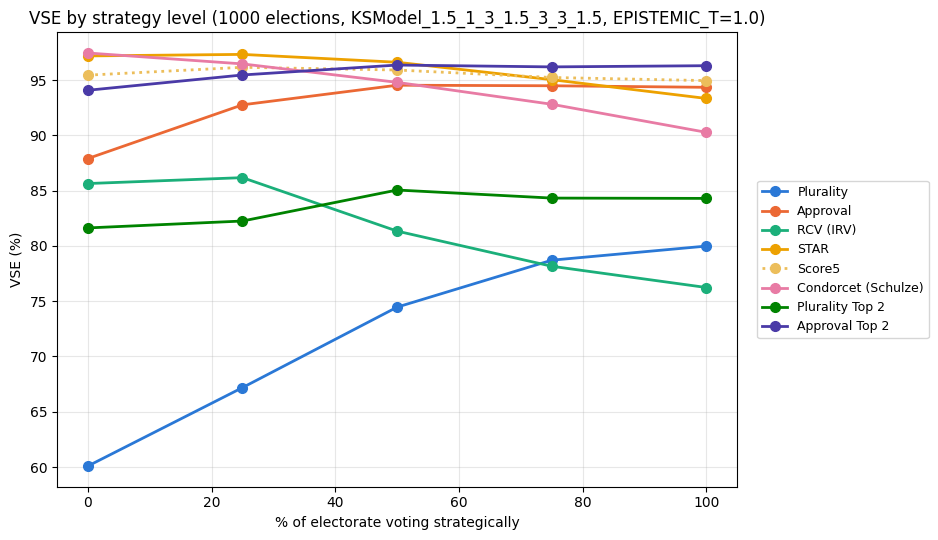

In [345]:
STRATEGY_AXIS = {
    "100% honest": 0,
    "25% strategic": 25,
    "50% strategic": 50,
    "75% strategic": 75,
    "100% strategic": 100,
}

fig, ax = plt.subplots(figsize=(9.5, 5.5))
for label, _ in PRE_NOISE_METHODS:
    points = sorted(
        (STRATEGY_AXIS[chooser_label], mean_)
        for chooser_label, mean_, _ in rows_by_method[label]
        if chooser_label in STRATEGY_AXIS
    )
    if not points:
        continue
    xs, ys = zip(*points)
    ax.plot(xs, [y * 100 for y in ys], marker="o", markersize=7, linewidth=2,
            color=METHOD_COLORS[label], linestyle=METHOD_LINESTYLES[label], label=label)

ax.set_xlabel("% of electorate voting strategically")
ax.set_ylabel("VSE (%)")
ax.set_title(f"VSE by strategy level ({NITER} elections, {MODEL}, EPISTEMIC_T={EPISTEMIC_T})")
ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

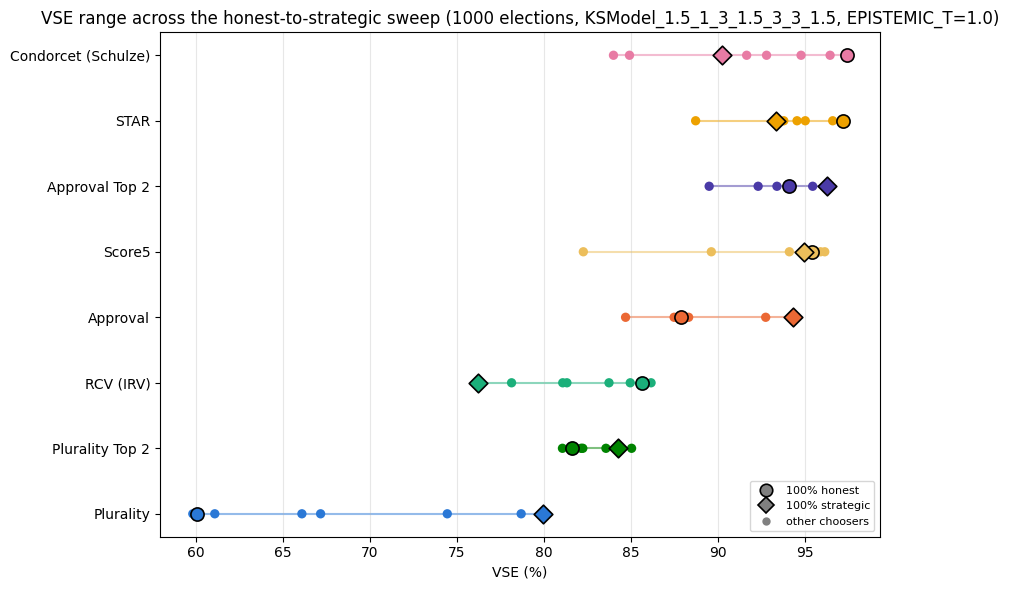

In [346]:
_sorted_labels = sorted(
    (label for label, _ in PRE_NOISE_METHODS if rows_by_method[label]),
    key=lambda label: max(m for _, m, _ in rows_by_method[label]),
)

fig, ax = plt.subplots(figsize=(9, 6))
# _sorted_labels is ascending by max VSE across any chooser; plotting in that order puts the
# worst method at row 0 (the bottom of a matplotlib y-axis) and the best method at the top row,
# as intended.
for row_i, label in enumerate(_sorted_labels):
    vses = [mean_ * 100 for _, mean_, _ in rows_by_method[label]]
    color = METHOD_COLORS[label]
    ax.plot([min(vses), max(vses)], [row_i, row_i], color=color, linewidth=1.5, alpha=0.5, zorder=1)
    for chooser_label, mean_, _ in rows_by_method[label]:
        is_honest = chooser_label == "100% honest"
        is_strategic = chooser_label == "100% strategic"
        ax.scatter(mean_ * 100, row_i,
                   marker="D" if is_strategic else "o",
                   s=90 if (is_honest or is_strategic) else 45,
                   color=color,
                   edgecolors="black" if (is_honest or is_strategic) else "none",
                   linewidths=1.2 if (is_honest or is_strategic) else 0,
                   zorder=3 if (is_honest or is_strategic) else 2)

ax.set_yticks(range(len(_sorted_labels)))
ax.set_yticklabels(_sorted_labels)
ax.set_xlabel("VSE (%)")
ax.set_title(f"VSE range across the honest-to-strategic sweep ({NITER} elections, "
             f"{MODEL}, EPISTEMIC_T={EPISTEMIC_T})")
_marker_legend = [
    Line2D([0], [0], marker="o", linestyle="none", markersize=9,
           markerfacecolor="gray", markeredgecolor="black", markeredgewidth=1.2, label="100% honest"),
    Line2D([0], [0], marker="D", linestyle="none", markersize=8,
           markerfacecolor="gray", markeredgecolor="black", markeredgewidth=1.2, label="100% strategic"),
    Line2D([0], [0], marker="o", linestyle="none", markersize=6,
           markerfacecolor="gray", markeredgecolor="none", label="other choosers"),
]
ax.legend(handles=_marker_legend, fontsize=8, loc="lower right")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Sweeping all three degradation parameters: VSE vs. voter information

`EPISTEMIC_T`, `AWARENESS_ALPHA`, and `FATIGUE_L` each get swept independently (the other two held at
their ideal value of `1.0`), across every method for which the sweep is meaningful, honest and
strategic ballots both. `AWARENESS_ALPHA`/`FATIGUE_L` sweeps are restricted to `PRE_NOISE_METHODS`: a
"noiseless runoff" variant is only ever different from its base method when the *primary's* own
epistemic noise varies -- the runoff already assumes full awareness by default regardless of the
primary's friction (see `Top2Base._runoff_electorate`) -- so simulating it under `AWARENESS_ALPHA`/
`FATIGUE_L` would just be a wasted, functionally-identical-up-to-tie-break-RNG copy of its base
method's row.

The reusable sweep tooling defined below (`sweep_methods`, `comparison_table`, `comparison_chart`)
is also what Section 16 and later sections use for smaller, focused comparisons -- defined here
since this is its first and largest use, but referenced throughout the rest of the notebook.


In [347]:
def sweep_methods(labels, sweep_param, sweep_values, niter, electorates=None, **fixed_overrides):
    """Run niter elections per value of sweep_param (one of 'epistemic_t', 'awareness_alpha',
    'fatigue_l'), holding the other two parameters at 1.0 (override via fixed_overrides),
    for just the given method labels (resolved against METHODS_LOOKUP). electorates: optional
    shared pool passed straight through to run_vse_simulation -- see its docstring; pass the
    SAME pool across every sweep_param call so all values, across all three parameters, are
    compared against the same underlying worlds (common random numbers).

    Returns (results_by_value, ce_by_value): each {value: {(label, chooser): ...}}.
    results_by_value holds (mean, ci) VSE pairs; ce_by_value holds raw Condorcet efficiency.
    """
    methods_subset = [(label, METHODS_LOOKUP[label]) for label in labels]
    base_kwargs = dict(epistemic_t=1.0, awareness_alpha=1.0, fatigue_l=1.0)
    base_kwargs.update(fixed_overrides)
    results_by_value = {}
    ce_by_value = {}
    for value in sweep_values:
        kwargs = dict(base_kwargs)
        kwargs[sweep_param] = value
        summary, ce_raw = run_vse_simulation(MODEL, methods_subset, NVOT, NCAND, niter,
                                      CHOOSER_FUNS, MEDIA, electorates=electorates, **kwargs)
        results_by_value[value] = reduce_to_mean_ci(summary)
        ce_by_value[value] = reduce_to_ce(ce_raw, results_by_value[value].keys())
        print(f"{sweep_param}={value:.2f} done")
    return results_by_value, ce_by_value


def comparison_table(results_by_value, labels, sweep_param, ballot_type="honBallot"):
    """Markdown table: rows=label, columns=sweep_param values, cell=VSE% (+/- CI)."""
    values = sorted(results_by_value)
    header = ["Method"] + [f"{sweep_param}={v:.2f}" for v in values]
    lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
    for label in labels:
        row = [label]
        for v in values:
            mean_, ci = results_by_value[v][(label, ballot_type)]
            row.append(f"{mean_ * 100:.1f}% (+/-{ci * 100:.1f})")
        lines.append("| " + " | ".join(row) + " |")
    display(Markdown("\n".join(lines)))


def comparison_chart(results_by_value, labels, sweep_param, ballot_type="honBallot",
                      baseline_label=None, title=None):
    """VSE-vs-sweep_param line chart; if baseline_label is given, a second panel shows
    label - baseline for every other label (the 'flip it ... minus STAR' framing)."""
    values = sorted(results_by_value)
    ncols = 2 if baseline_label else 1
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 5))
    ax_vse = axes[0] if baseline_label else axes
    for label in labels:
        vses = [results_by_value[v][(label, ballot_type)][0] * 100 for v in values]
        ax_vse.plot(values, vses, marker="o", markersize=7, linewidth=2,
                    color=METHOD_COLORS.get(label), linestyle=METHOD_LINESTYLES.get(label, "-"),
                    label=label)
    ax_vse.set_xlabel(sweep_param)
    ax_vse.set_ylabel("VSE (%)")
    ax_vse.set_title(title or f"VSE vs. {sweep_param}")
    ax_vse.legend(fontsize=8)
    ax_vse.grid(True, alpha=0.3)

    if baseline_label:
        ax_gap = axes[1]
        baseline_vses = [results_by_value[v][(baseline_label, ballot_type)][0] * 100 for v in values]
        for label in labels:
            if label == baseline_label:
                continue
            vses = [results_by_value[v][(label, ballot_type)][0] * 100 for v in values]
            gap = [a - b for a, b in zip(vses, baseline_vses)]
            ax_gap.plot(values, gap, marker="o", markersize=7, linewidth=2,
                        color=METHOD_COLORS.get(label), linestyle=METHOD_LINESTYLES.get(label, "-"),
                        label=f"{label} \u2212 {baseline_label}")
        ax_gap.axhline(0, color="gray", linewidth=1, linestyle=":")
        ax_gap.set_xlabel(sweep_param)
        ax_gap.set_ylabel("VSE gap (percentage points)")
        ax_gap.set_title(f"Gap vs. {baseline_label}")
        ax_gap.legend(fontsize=8)
        ax_gap.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [348]:
SWEEP_NITER = 500
SWEEP_VALUES = [0.0, 0.3, 0.5, 0.7, 0.85, 1.0]

# epistemic_t sweeps every method; awareness_alpha/fatigue_l are restricted to PRE_NOISE_METHODS --
# see the section markdown above for why. "Approval Top 2 (Frozen)" reacts ONLY to awareness_alpha
# (its runoff reapplies friction at the primary's own awareness_alpha, fatigue pinned to 1.0 -- see
# Top2Base.__init__) -- both epistemic_t and fatigue_l are held at 1.0 throughout their own
# sweeps, so Frozen would be identical to plain "Approval Top 2" at EVERY point of those two
# sweeps, not just one redundant endpoint. Excluded from both entirely rather than left in to
# silently overlap; kept in the awareness_alpha sweep (via PRE_NOISE_METHODS, unchanged) where it's
# genuinely distinct.
_FROZEN_LABEL = "Approval Top 2 (Frozen)"
METHODS_NO_FROZEN = [(label, m) for label, m in METHODS if label != _FROZEN_LABEL]
PRE_NOISE_METHODS_NO_FROZEN = [(label, m) for label, m in PRE_NOISE_METHODS if label != _FROZEN_LABEL]
SWEEP_PARAMS = [
    ("epistemic_t", METHODS_NO_FROZEN),
    ("awareness_alpha", PRE_NOISE_METHODS),
    ("fatigue_l", PRE_NOISE_METHODS_NO_FROZEN),
]

sweep_results_by_param = {}  # param -> {value: {(label, chooser): (mean, ci)}}
sweep_ce_by_param = {}       # param -> {value: {(label, chooser): raw_ce}}
_sweep_values_to_run = [v for v in SWEEP_VALUES if v != 1.0]

for sweep_param, param_methods in SWEEP_PARAMS:
    _param_start = time.perf_counter()
    _labels = [label for label, _ in param_methods]
    # 1.0 ("Ideal") is the same scenario as Section 10's initial run for every parameter --
    # reuse its already-computed (higher-precision, NITER=500) result instead of re-simulating
    # it, and share ONE electorate pool per parameter (common random numbers) across every value
    # that IS simulated, rather than each drawing its own independent batch.
    _pool = [MODEL(NVOT, NCAND) for _ in range(SWEEP_NITER)]
    sweep_results_by_param[sweep_param], sweep_ce_by_param[sweep_param] = sweep_methods(
        _labels, sweep_param, _sweep_values_to_run, SWEEP_NITER, electorates=_pool,
    )
    sweep_results_by_param[sweep_param][1.0] = {k: v for k, v in results.items() if k[0] in _labels}
    sweep_ce_by_param[sweep_param][1.0] = {k: v for k, v in ce_results.items() if k[0] in _labels}
    print(f"{sweep_param} sweep done in {time.perf_counter() - _param_start:.1f}s")


epistemic_t=0.00 done
epistemic_t=0.30 done
epistemic_t=0.50 done
epistemic_t=0.70 done
epistemic_t=0.85 done
epistemic_t sweep done in 157.9s
awareness_alpha=0.00 done
awareness_alpha=0.30 done
awareness_alpha=0.50 done
awareness_alpha=0.70 done
awareness_alpha=0.85 done
awareness_alpha sweep done in 141.1s
fatigue_l=0.00 done
fatigue_l=0.30 done
fatigue_l=0.50 done
fatigue_l=0.70 done
fatigue_l=0.85 done
fatigue_l sweep done in 125.7s


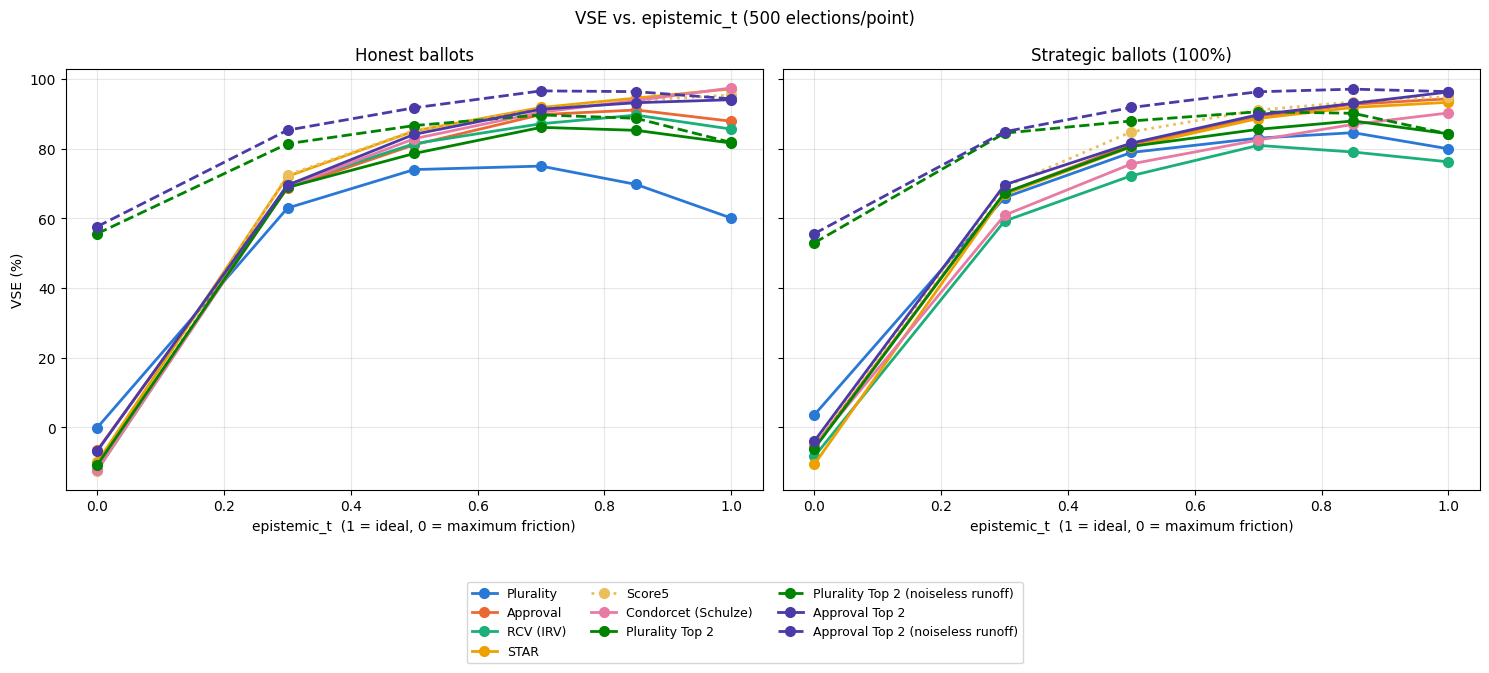

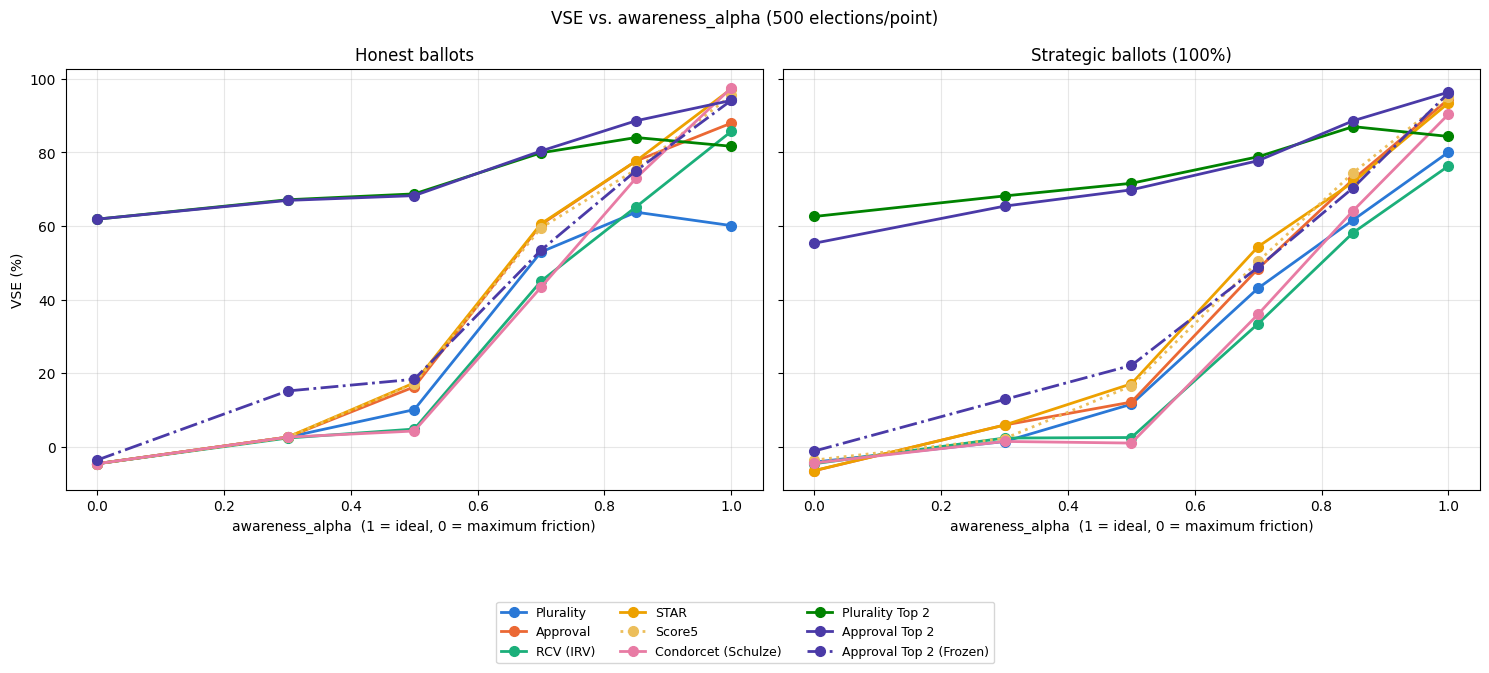

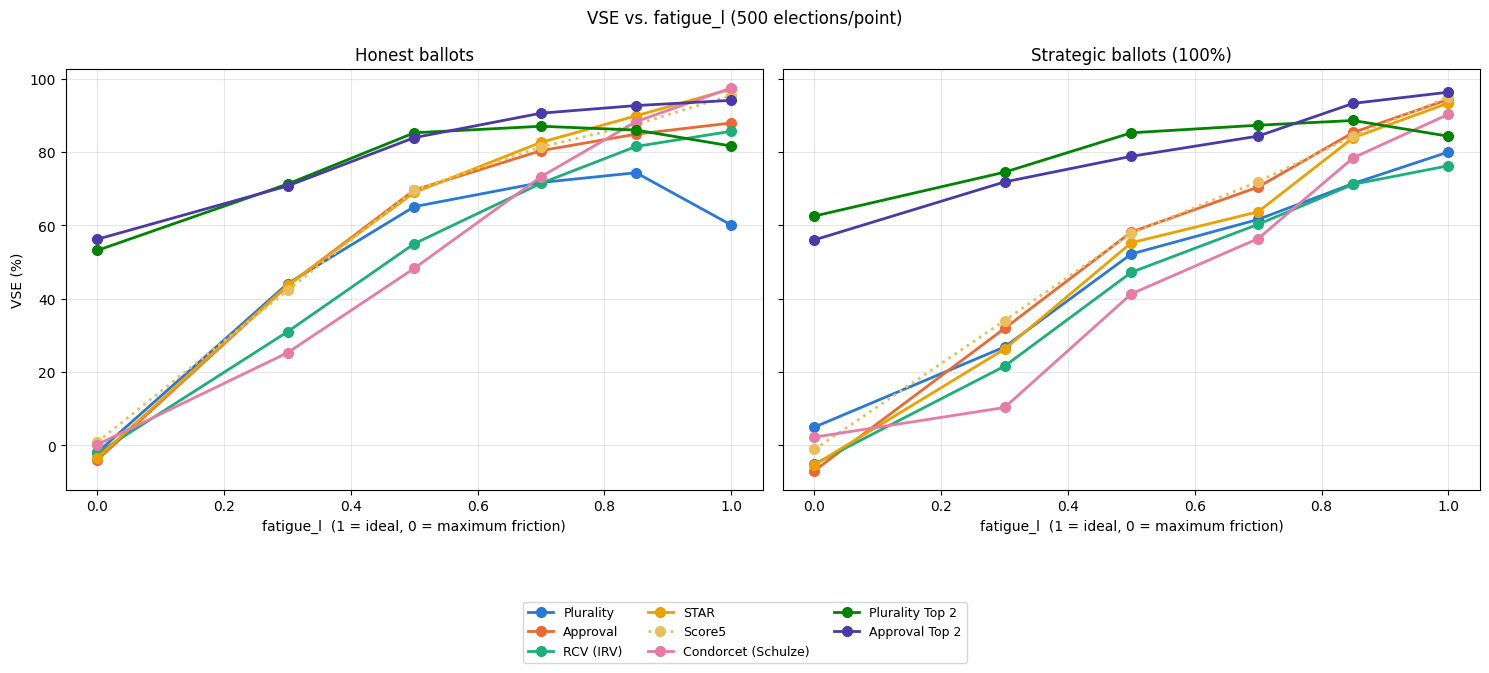

In [349]:
for sweep_param, param_methods in SWEEP_PARAMS:
    _by_value = sweep_results_by_param[sweep_param]
    _values = sorted(_by_value)
    fig, (ax_hon, ax_strat) = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
    for label, _ in param_methods:
        color = METHOD_COLORS[label]
        style = METHOD_LINESTYLES[label]
        hon_vses = [_by_value[v][(label, "honBallot")][0] * 100 for v in _values]
        ax_hon.plot(_values, hon_vses, marker="o", markersize=7, linewidth=2, color=color, linestyle=style, label=label)
        strat_vses = [_by_value[v][(label, "stratBallot")][0] * 100 for v in _values]
        ax_strat.plot(_values, strat_vses, marker="o", markersize=7, linewidth=2, color=color, linestyle=style, label=label)
    ax_hon.set_title("Honest ballots")
    ax_strat.set_title("Strategic ballots (100%)")
    for ax in (ax_hon, ax_strat):
        ax.set_xlabel(f"{sweep_param}  (1 = ideal, 0 = maximum friction)")
        ax.grid(True, alpha=0.3)
    ax_hon.set_ylabel("VSE (%)")
    handles, labels_ = ax_hon.get_legend_handles_labels()
    fig.legend(handles, labels_, loc="lower center", fontsize=9, ncol=3, bbox_to_anchor=(0.5, -0.22))
    fig.suptitle(f"VSE vs. {sweep_param} ({SWEEP_NITER} elections/point)")
    plt.tight_layout()
    plt.show()


### Condorcet efficiency vs. voter information (all three parameters)

Reuses `sweep_ce_by_param` from the sweep above -- no new simulation.


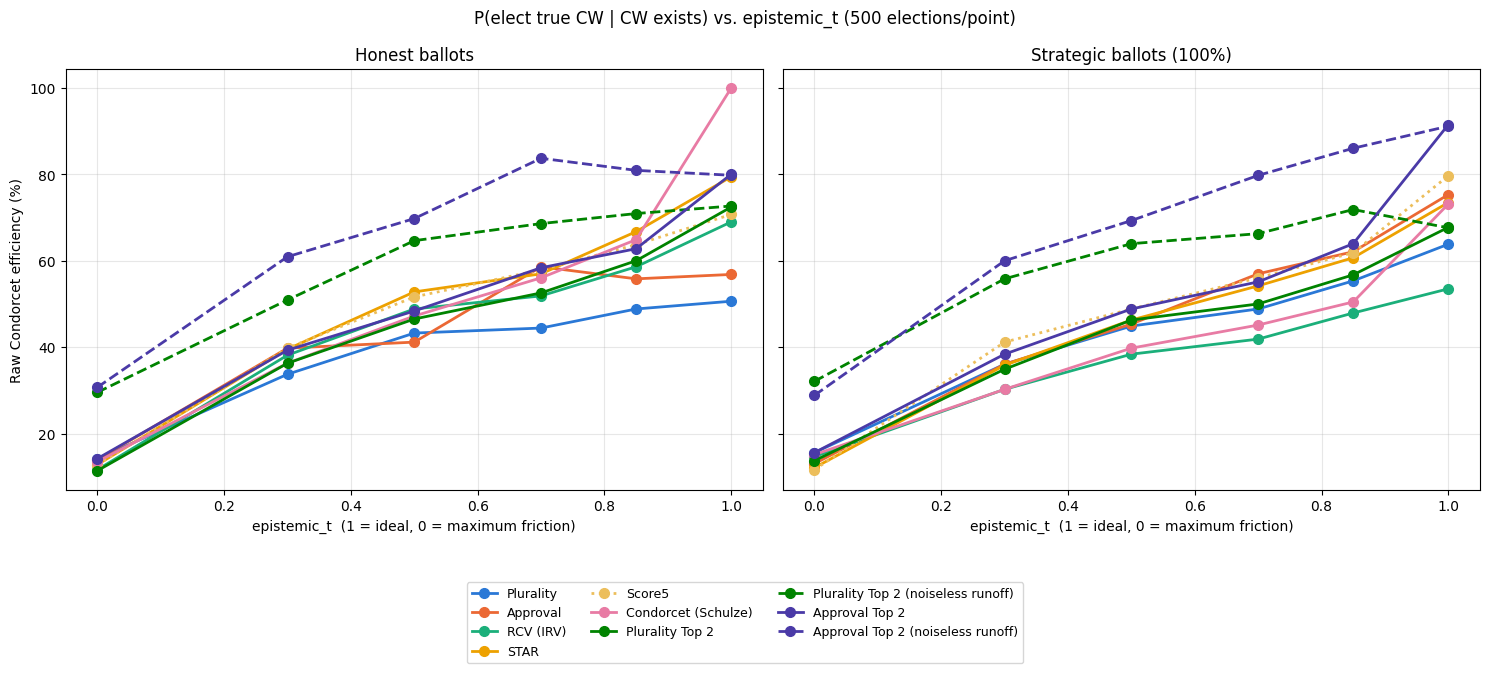

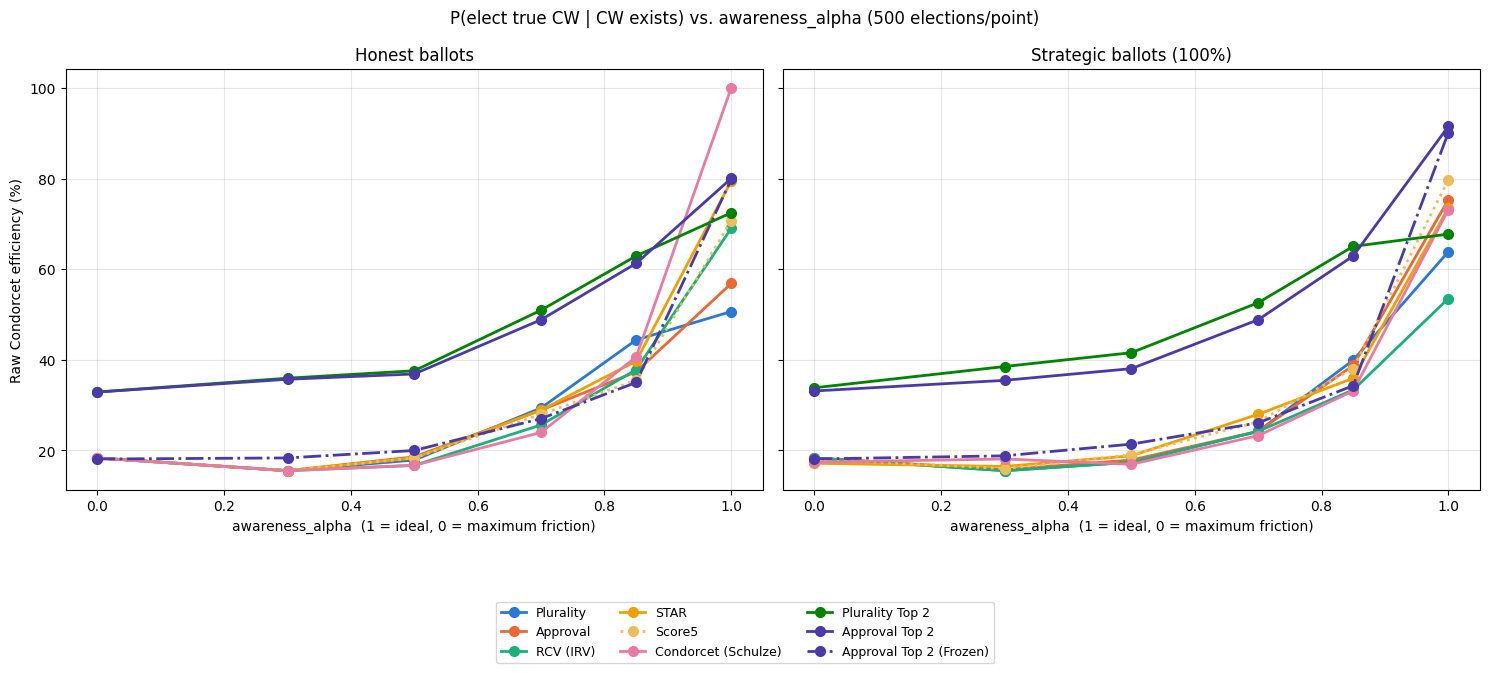

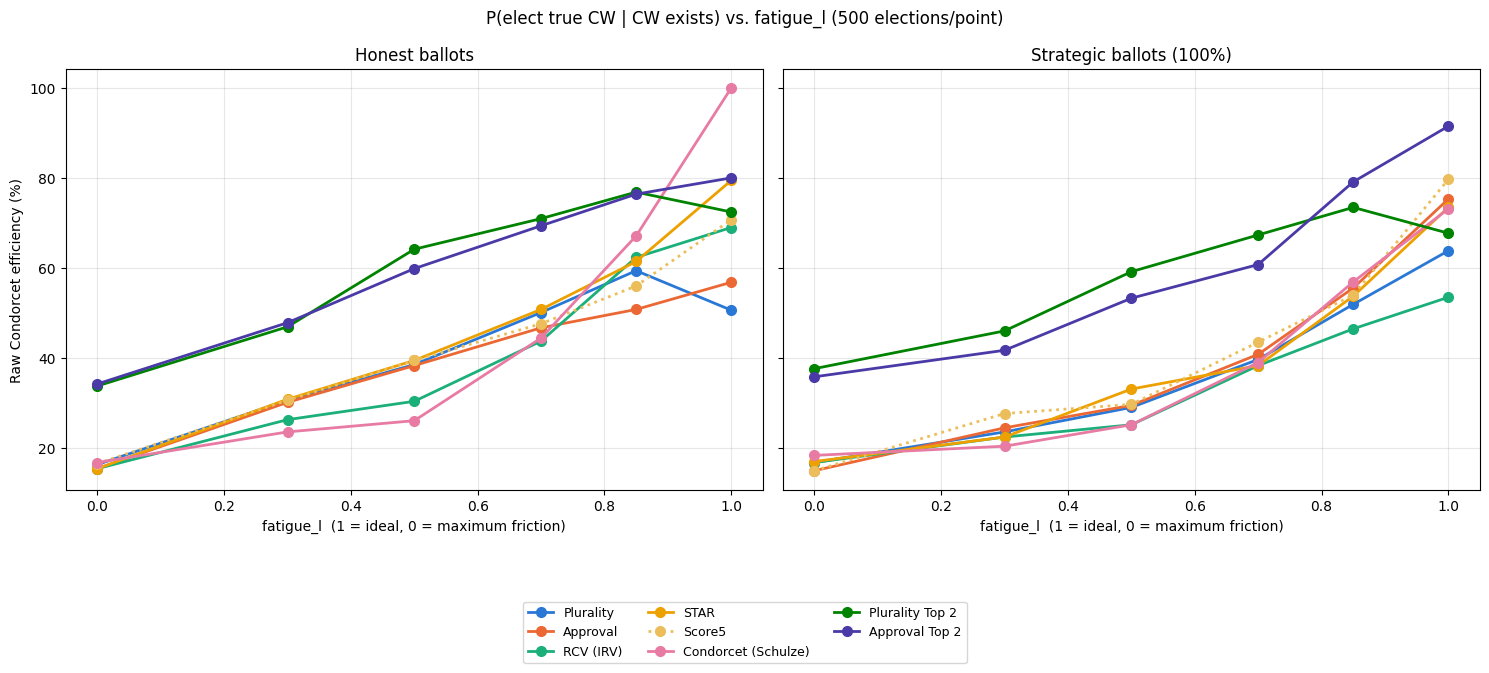

In [350]:
for sweep_param, param_methods in SWEEP_PARAMS:
    _ce_by_value = sweep_ce_by_param[sweep_param]
    _values = sorted(_ce_by_value)
    fig, (ax_hon, ax_strat) = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
    for label, _ in param_methods:
        color = METHOD_COLORS[label]
        style = METHOD_LINESTYLES[label]
        hon_ces = [_ce_by_value[v].get((label, "honBallot"), float("nan")) * 100 for v in _values]
        ax_hon.plot(_values, hon_ces, marker="o", markersize=7, linewidth=2, color=color, linestyle=style, label=label)
        strat_ces = [_ce_by_value[v].get((label, "stratBallot"), float("nan")) * 100 for v in _values]
        ax_strat.plot(_values, strat_ces, marker="o", markersize=7, linewidth=2, color=color, linestyle=style, label=label)
    ax_hon.set_title("Honest ballots")
    ax_strat.set_title("Strategic ballots (100%)")
    for ax in (ax_hon, ax_strat):
        ax.set_xlabel(f"{sweep_param}  (1 = ideal, 0 = maximum friction)")
        ax.grid(True, alpha=0.3)
    ax_hon.set_ylabel("Raw Condorcet efficiency (%)")
    handles, labels_ = ax_hon.get_legend_handles_labels()
    fig.legend(handles, labels_, loc="lower center", fontsize=9, ncol=3, bbox_to_anchor=(0.5, -0.22))
    fig.suptitle(f"P(elect true CW | CW exists) vs. {sweep_param} ({SWEEP_NITER} elections/point)")
    plt.tight_layout()
    plt.show()


## 16. Comparing method flavors: Approval's flavors vs. STAR/Schulze, then joint scenarios

Reads from Section 14's already-computed `sweep_results_by_param`/`sweep_ce_by_param` -- no new
simulation for the individual-parameter comparisons below (`sweep_methods`/`comparison_table`/
`comparison_chart`, the reusable tooling this section used to define and simulate with directly,
now live in Section 14, since that's their first and largest use). The joint "realistic
conditions" scenarios further down (all three parameters moving together) are a genuinely
different sweep shape and still run their own simulation.


### Approval's flavors vs. STAR/Schulze, across noise and both friction mechanisms

The motivating question: Approval Top 2 (a coarse 0/1 ballot, decided over two rounds) is the
flavor of Approval actually being adopted (e.g. St. Louis). STAR and Schulze both let voters
express far more information in a single round. Does STAR/Schulze's honest-VSE edge over Approval
hold up once that richer signal degrades -- and does Approval Top 2's *delayed, two-candidate*
runoff let voters recover some of that edge, on the theory that deciding between just two finalists
is easy to get right even if the crowded primary wasn't?

Same `baseline_label="STAR"` framing, for all three parameters in turn -- `EPISTEMIC_T`,
`AWARENESS_ALPHA`, `FATIGUE_L` -- each swept alone with the other two held at `1.0`. `COMPARE_LABELS`
below is Approval's three flavors, STAR, Schulze, and `Score5` -- Plurality and RCV aren't part of
this particular comparison (it's specifically about how much of Approval/STAR/Schulze's
*richer-ballot* edge survives degradation), but both are covered in Section 14's full sweep above
if you want the plainer-ballot methods' own numbers. `Score5` (`Score(STAR_TOP_RANK)`, Section 7)
is STAR's own ballots with the runoff switched off; it rides along here as a free no-runoff
reference line on every chart below, and Section 20 reuses this exact data (no separate
simulation) to isolate the runoff step's own effect.


In [351]:
COMPARE_LABELS = ["Plurality Top 2", "Plurality Top 2 (noiseless runoff)", "Approval", "Approval Top 2 (Frozen)", "Approval Top 2",
                   "Approval Top 2 (noiseless runoff)", "STAR", "Score5", "Condorcet (Schulze)"]

# No new simulation here -- Section 14 already swept every method (epistemic_t) or every
# PRE_NOISE_METHODS method (awareness_alpha/fatigue_l) across all three parameters; this just
# filters those already-computed results down to the 6 labels above. "Approval Top 2 (noiseless
# runoff)" is simply absent from the awareness_alpha/fatigue_l dicts (Section 14 never simulated it
# there), not filtered out here -- see Section 14's markdown for why. "Score5" is included so it
# rides along as a no-runoff reference line on every chart below; Section 20 reuses this same
# compare_by_param (and the joint_results built from COMPARE_LABELS further down) instead of
# running its own separate STAR-vs-Score5 simulation.
compare_by_param = {
    param: {value: {k: v for k, v in by_value.items() if k[0] in COMPARE_LABELS}
            for value, by_value in sweep_results_by_param[param].items()}
    for param, _ in SWEEP_PARAMS
}
compare_ce_by_param = {
    param: {value: {k: v for k, v in by_value.items() if k[0] in COMPARE_LABELS}
            for value, by_value in sweep_ce_by_param[param].items()}
    for param, _ in SWEEP_PARAMS
}


#### Epistemic noise (EPISTEMIC_T)

| Method | epistemic_t=0.00 | epistemic_t=0.30 | epistemic_t=0.50 | epistemic_t=0.70 | epistemic_t=0.85 | epistemic_t=1.00 |
|---|---|---|---|---|---|---|
| Plurality Top 2 | -10.8% (+/-9.9) | 68.9% (+/-3.9) | 78.6% (+/-3.4) | 86.1% (+/-2.5) | 85.3% (+/-3.7) | 81.6% (+/-2.7) |
| Plurality Top 2 (noiseless runoff) | 55.6% (+/-5.5) | 81.4% (+/-2.8) | 86.7% (+/-2.9) | 89.7% (+/-2.2) | 88.7% (+/-2.7) | 81.8% (+/-2.7) |
| Approval | -6.6% (+/-10.2) | 68.7% (+/-4.2) | 81.1% (+/-2.6) | 89.8% (+/-1.7) | 91.1% (+/-1.3) | 87.9% (+/-1.3) |
| Approval Top 2 | -6.8% (+/-10.2) | 69.5% (+/-3.9) | 84.1% (+/-2.3) | 91.3% (+/-1.4) | 93.2% (+/-1.2) | 94.1% (+/-1.0) |
| Approval Top 2 (noiseless runoff) | 57.7% (+/-5.0) | 85.3% (+/-2.7) | 91.8% (+/-1.8) | 96.6% (+/-0.9) | 96.4% (+/-0.8) | 94.3% (+/-1.0) |
| STAR | -10.0% (+/-10.3) | 72.1% (+/-3.8) | 85.1% (+/-2.4) | 91.8% (+/-1.3) | 94.5% (+/-1.0) | 97.2% (+/-0.7) |
| Score5 | -12.5% (+/-10.4) | 72.5% (+/-3.5) | 85.2% (+/-2.2) | 91.5% (+/-1.4) | 93.8% (+/-1.1) | 95.4% (+/-0.7) |
| Condorcet (Schulze) | -12.2% (+/-10.4) | 69.1% (+/-3.9) | 82.9% (+/-2.5) | 90.5% (+/-1.6) | 93.9% (+/-1.1) | 97.4% (+/-0.7) |

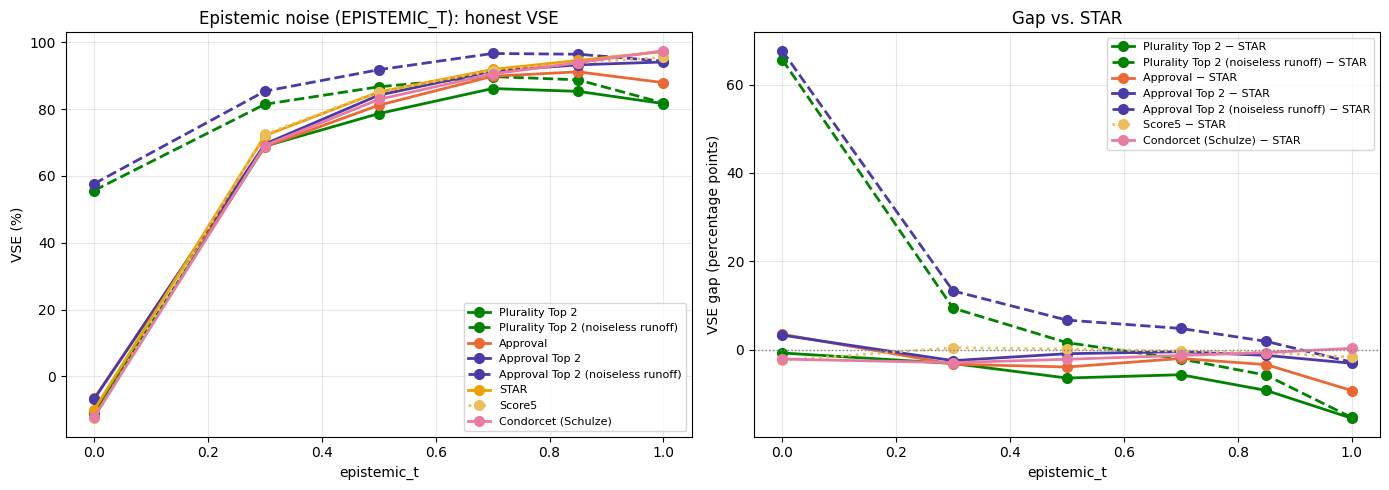

#### Unfamiliarity (AWARENESS_ALPHA)

| Method | awareness_alpha=0.00 | awareness_alpha=0.30 | awareness_alpha=0.50 | awareness_alpha=0.70 | awareness_alpha=0.85 | awareness_alpha=1.00 |
|---|---|---|---|---|---|---|
| Plurality Top 2 | 61.8% (+/-4.4) | 67.1% (+/-4.0) | 68.7% (+/-3.9) | 79.8% (+/-3.0) | 84.0% (+/-2.9) | 81.6% (+/-2.7) |
| Approval | -4.6% (+/-9.8) | 2.6% (+/-9.2) | 16.3% (+/-8.5) | 60.4% (+/-4.6) | 77.6% (+/-2.6) | 87.9% (+/-1.3) |
| Approval Top 2 (Frozen) | -3.6% (+/-9.9) | 15.2% (+/-8.4) | 18.4% (+/-8.5) | 53.4% (+/-5.6) | 75.0% (+/-3.0) | 94.1% (+/-1.0) |
| Approval Top 2 | 61.8% (+/-4.4) | 66.9% (+/-4.0) | 68.2% (+/-4.1) | 80.3% (+/-2.8) | 88.5% (+/-2.0) | 94.1% (+/-1.0) |
| STAR | -4.6% (+/-9.8) | 2.6% (+/-9.2) | 17.4% (+/-8.4) | 60.6% (+/-4.4) | 77.6% (+/-2.8) | 97.2% (+/-0.7) |
| Score5 | -4.6% (+/-9.8) | 2.6% (+/-9.2) | 17.2% (+/-8.4) | 59.5% (+/-4.5) | 75.3% (+/-2.8) | 95.4% (+/-0.7) |
| Condorcet (Schulze) | -4.6% (+/-9.8) | 2.6% (+/-9.2) | 4.3% (+/-9.2) | 43.4% (+/-6.2) | 73.0% (+/-3.5) | 97.4% (+/-0.7) |

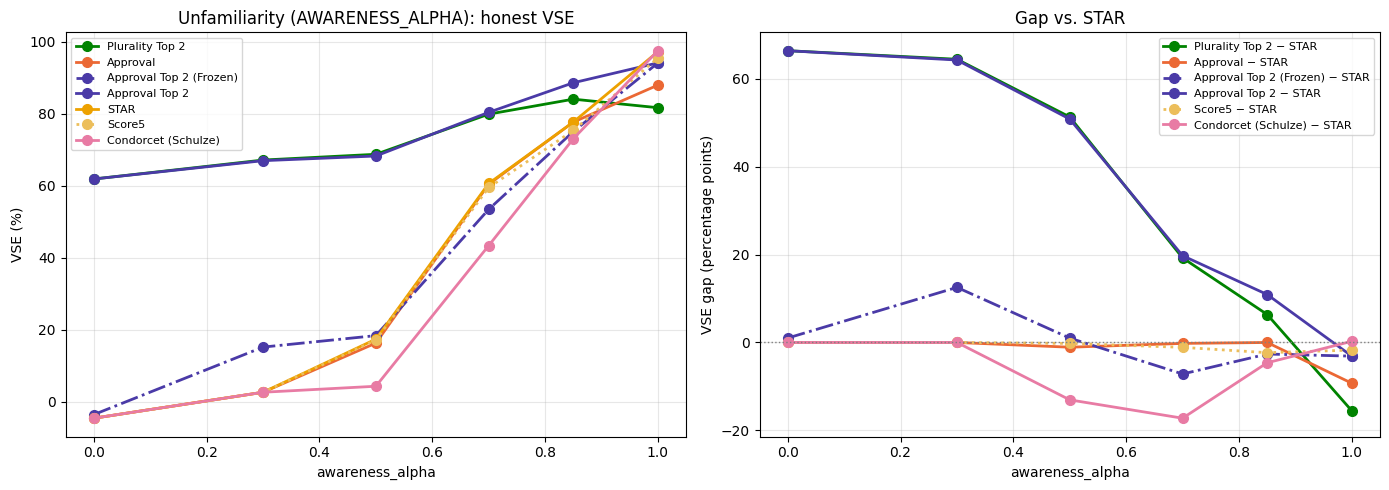

#### Ballot fatigue (FATIGUE_L)

| Method | fatigue_l=0.00 | fatigue_l=0.30 | fatigue_l=0.50 | fatigue_l=0.70 | fatigue_l=0.85 | fatigue_l=1.00 |
|---|---|---|---|---|---|---|
| Plurality Top 2 | 53.2% (+/-6.0) | 71.3% (+/-4.2) | 85.2% (+/-3.0) | 87.0% (+/-3.0) | 86.0% (+/-3.1) | 81.6% (+/-2.7) |
| Approval | -4.0% (+/-9.6) | 43.5% (+/-6.2) | 69.6% (+/-4.0) | 80.4% (+/-2.7) | 84.9% (+/-2.1) | 87.9% (+/-1.3) |
| Approval Top 2 | 56.2% (+/-5.4) | 70.7% (+/-4.4) | 83.9% (+/-2.8) | 90.6% (+/-1.9) | 92.7% (+/-1.5) | 94.1% (+/-1.0) |
| STAR | -3.4% (+/-9.5) | 43.6% (+/-6.3) | 68.9% (+/-4.2) | 82.6% (+/-2.6) | 89.9% (+/-1.7) | 97.2% (+/-0.7) |
| Score5 | 0.9% (+/-9.3) | 42.2% (+/-6.4) | 69.6% (+/-4.1) | 81.4% (+/-2.6) | 87.5% (+/-1.8) | 95.4% (+/-0.7) |
| Condorcet (Schulze) | 0.2% (+/-9.5) | 25.2% (+/-7.4) | 48.3% (+/-6.1) | 73.3% (+/-4.2) | 88.3% (+/-2.2) | 97.4% (+/-0.7) |

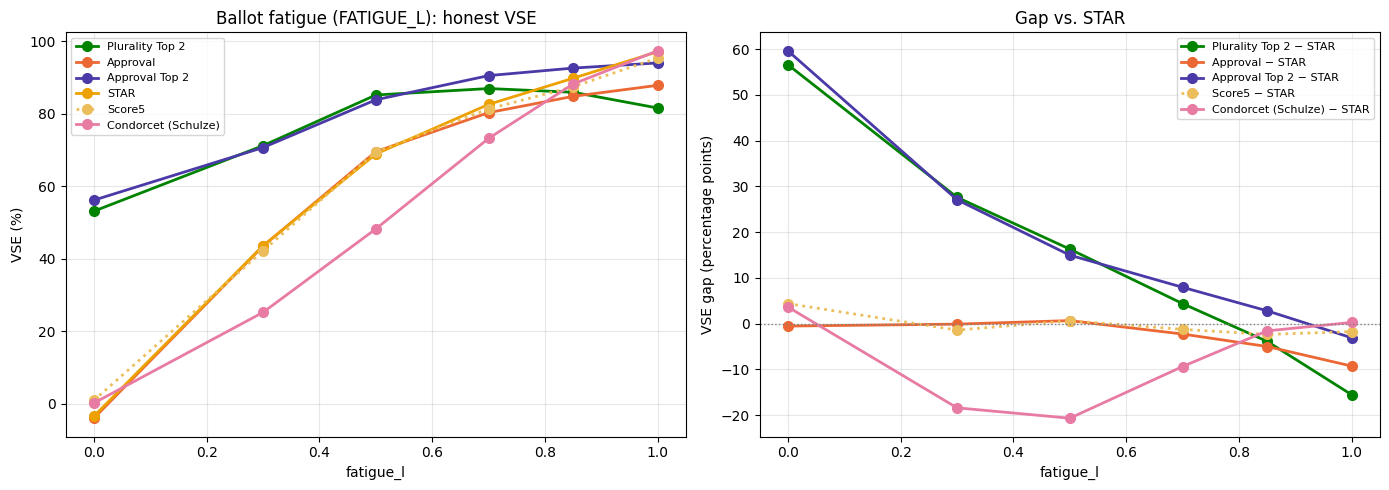

In [352]:
for sweep_param, param_title in [
    ("epistemic_t", "Epistemic noise (EPISTEMIC_T)"),
    ("awareness_alpha", "Unfamiliarity (AWARENESS_ALPHA)"),
    ("fatigue_l", "Ballot fatigue (FATIGUE_L)"),
]:
    display(Markdown(f"#### {param_title}"))
    # Derived from what's actually present rather than a hardcoded exclusion: "Approval Top 2
    # (noiseless runoff)" is only in compare_by_param["epistemic_t"] (see the cell above), so it
    # naturally drops out of the other two params' tables/charts here without special-casing.
    _some_value = next(iter(compare_by_param[sweep_param]))
    _present_labels = {k[0] for k in compare_by_param[sweep_param][_some_value]}
    _compare_labels_here = [l for l in COMPARE_LABELS if l in _present_labels]
    comparison_table(compare_by_param[sweep_param], _compare_labels_here, sweep_param)
    comparison_chart(compare_by_param[sweep_param], _compare_labels_here, sweep_param,
                      baseline_label="STAR", title=f"{param_title}: honest VSE")


### The same comparison, with Approval Top 2 as the baseline

Same data as above (`compare_by_param`, no new simulation) -- just re-referenced. The chart above
asks "how far behind STAR is everyone else"; if Approval Top 2, not STAR, is the system actually
being proposed (e.g. St. Louis), the more relevant question is how far behind -- or ahead of --
*it* everyone else is.


#### Epistemic noise (EPISTEMIC_T) (baseline: Approval Top 2)

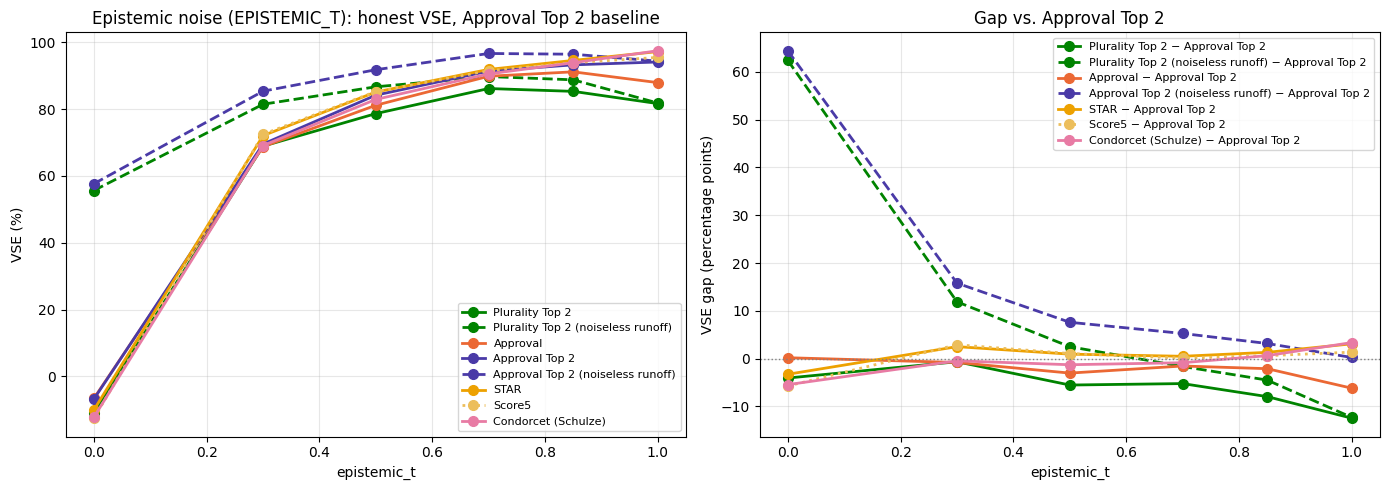

#### Unfamiliarity (AWARENESS_ALPHA) (baseline: Approval Top 2)

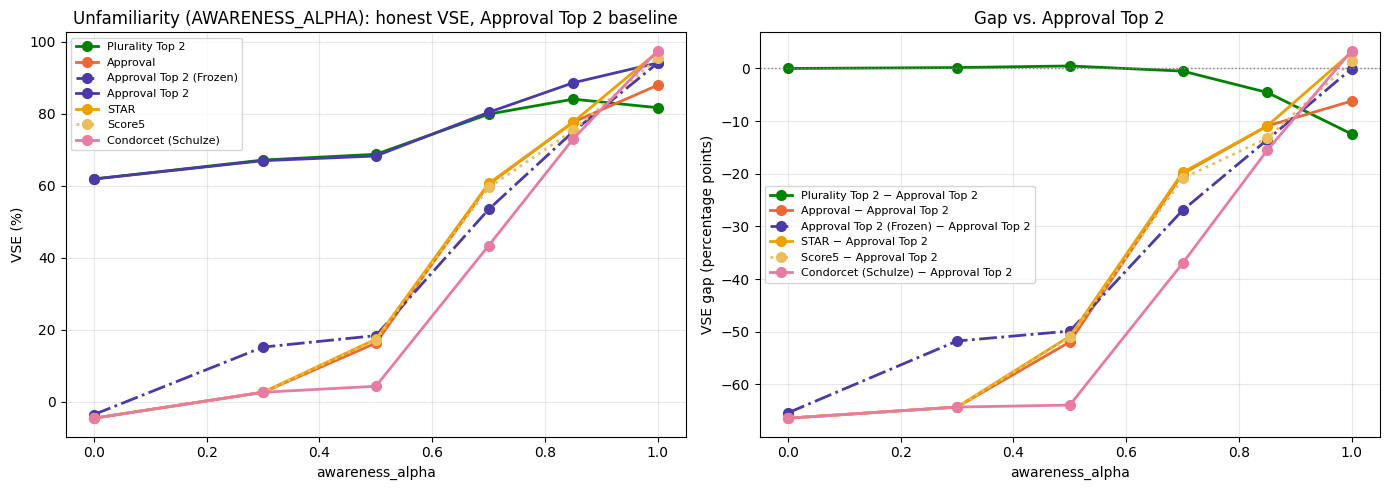

#### Ballot fatigue (FATIGUE_L) (baseline: Approval Top 2)

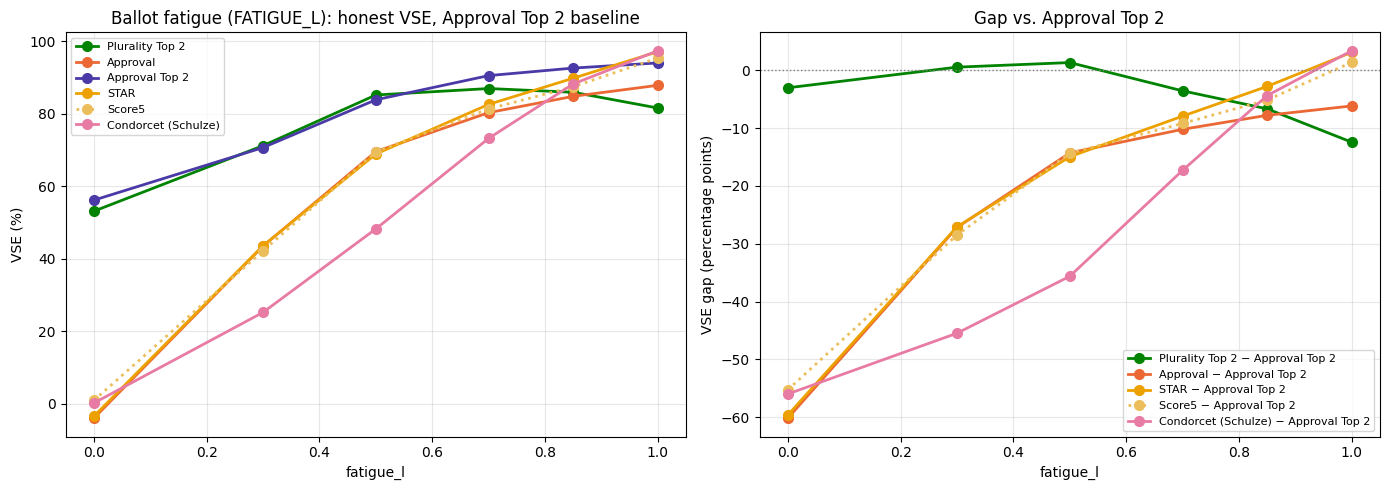

In [353]:
for sweep_param, param_title in [
    ("epistemic_t", "Epistemic noise (EPISTEMIC_T)"),
    ("awareness_alpha", "Unfamiliarity (AWARENESS_ALPHA)"),
    ("fatigue_l", "Ballot fatigue (FATIGUE_L)"),
]:
    display(Markdown(f"#### {param_title} (baseline: Approval Top 2)"))
    _some_value = next(iter(compare_by_param[sweep_param]))
    _present_labels = {k[0] for k in compare_by_param[sweep_param][_some_value]}
    _compare_labels_here = [l for l in COMPARE_LABELS if l in _present_labels]
    comparison_chart(compare_by_param[sweep_param], _compare_labels_here, sweep_param,
                      baseline_label="Approval Top 2",
                      title=f"{param_title}: honest VSE, Approval Top 2 baseline")


### Condorcet efficiency across the same three individual sweeps

Reuses `compare_ce_by_param` from the sweep above -- no new simulation. Raw CE (honest ballots)
per method, per sweep parameter.


#### Epistemic noise (EPISTEMIC_T): raw Condorcet efficiency

| Method | epistemic_t=0.00 | epistemic_t=0.30 | epistemic_t=0.50 | epistemic_t=0.70 | epistemic_t=0.85 | epistemic_t=1.00 |
|---|---|---|---|---|---|---|
| Plurality Top 2 | 11.4% | 36.3% | 46.5% | 52.6% | 60.0% | 72.4% |
| Plurality Top 2 (noiseless runoff) | 29.5% | 50.9% | 64.7% | 68.6% | 70.9% | 72.7% |
| Approval | 14.0% | 39.8% | 41.2% | 58.6% | 55.8% | 56.8% |
| Approval Top 2 | 14.2% | 39.3% | 48.4% | 58.4% | 62.8% | 80.0% |
| Approval Top 2 (noiseless runoff) | 30.7% | 60.9% | 69.8% | 83.7% | 80.9% | 79.8% |
| STAR | 12.8% | 39.5% | 52.8% | 57.0% | 66.7% | 79.4% |
| Score5 | 12.8% | 39.8% | 51.6% | 57.9% | 63.7% | 70.7% |
| Condorcet (Schulze) | 13.5% | 36.3% | 47.2% | 56.0% | 64.9% | 100.0% |

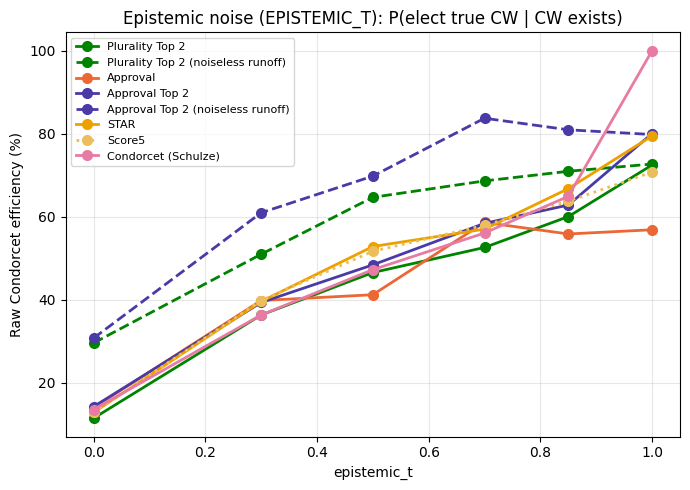

#### Unfamiliarity (AWARENESS_ALPHA): raw Condorcet efficiency

| Method | awareness_alpha=0.00 | awareness_alpha=0.30 | awareness_alpha=0.50 | awareness_alpha=0.70 | awareness_alpha=0.85 | awareness_alpha=1.00 |
|---|---|---|---|---|---|---|
| Plurality Top 2 | 32.9% | 35.9% | 37.6% | 50.9% | 62.9% | 72.4% |
| Approval | 18.3% | 15.5% | 18.5% | 28.9% | 37.3% | 56.8% |
| Approval Top 2 (Frozen) | 18.1% | 18.3% | 20.0% | 27.0% | 35.0% | 79.8% |
| Approval Top 2 | 32.9% | 35.7% | 36.9% | 48.8% | 61.3% | 80.0% |
| STAR | 18.3% | 15.5% | 18.3% | 28.9% | 39.7% | 79.4% |
| Score5 | 18.3% | 15.5% | 18.3% | 27.9% | 35.4% | 70.7% |
| Condorcet (Schulze) | 18.3% | 15.5% | 16.7% | 23.9% | 40.6% | 100.0% |

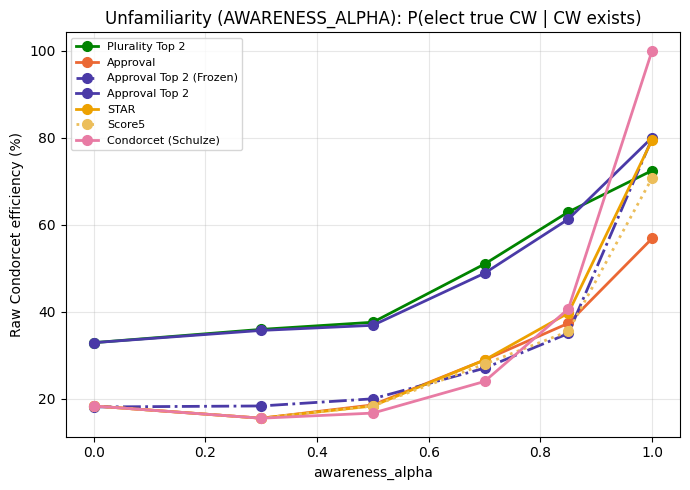

#### Ballot fatigue (FATIGUE_L): raw Condorcet efficiency

| Method | fatigue_l=0.00 | fatigue_l=0.30 | fatigue_l=0.50 | fatigue_l=0.70 | fatigue_l=0.85 | fatigue_l=1.00 |
|---|---|---|---|---|---|---|
| Plurality Top 2 | 33.8% | 46.9% | 64.2% | 71.0% | 76.9% | 72.4% |
| Approval | 15.4% | 30.2% | 38.3% | 46.7% | 50.8% | 56.8% |
| Approval Top 2 | 34.2% | 47.8% | 59.9% | 69.4% | 76.4% | 80.0% |
| STAR | 15.4% | 30.8% | 39.5% | 50.8% | 61.5% | 79.4% |
| Score5 | 16.6% | 30.6% | 39.5% | 47.6% | 56.0% | 70.7% |
| Condorcet (Schulze) | 16.8% | 23.6% | 26.1% | 44.4% | 67.1% | 100.0% |

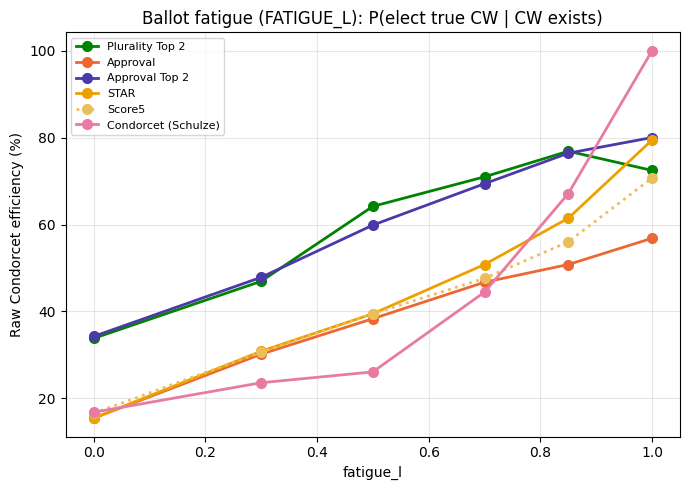

In [354]:
for sweep_param, param_title in [
    ("epistemic_t", "Epistemic noise (EPISTEMIC_T)"),
    ("awareness_alpha", "Unfamiliarity (AWARENESS_ALPHA)"),
    ("fatigue_l", "Ballot fatigue (FATIGUE_L)"),
]:
    display(Markdown(f"#### {param_title}: raw Condorcet efficiency"))
    _some_value = next(iter(compare_ce_by_param[sweep_param]))
    _present_labels = {k[0] for k in compare_ce_by_param[sweep_param][_some_value]}
    _compare_labels_here = [l for l in COMPARE_LABELS if l in _present_labels]
    ce_by_value = compare_ce_by_param[sweep_param]
    values = sorted(ce_by_value)
    header = ["Method"] + [f"{sweep_param}={v:.2f}" for v in values]
    lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
    for label in _compare_labels_here:
        row = [label]
        for v in values:
            ce = ce_by_value[v].get((label, "honBallot"))
            row.append("n/a" if ce is None or ce != ce else f"{ce * 100:.1f}%")
        lines.append("| " + " | ".join(row) + " |")
    display(Markdown("\n".join(lines)))

    fig, ax = plt.subplots(figsize=(7, 5))
    for label in _compare_labels_here:
        ces = [ce_by_value[v].get((label, "honBallot"), float("nan")) * 100 for v in values]
        ax.plot(values, ces, marker="o", markersize=7, linewidth=2,
                color=METHOD_COLORS.get(label), linestyle=METHOD_LINESTYLES.get(label, "-"), label=label)
    ax.set_xlabel(sweep_param)
    ax.set_ylabel("Raw Condorcet efficiency (%)")
    ax.set_title(f"{param_title}: P(elect true CW | CW exists)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [355]:
# Plain-language readout: does each Approval flavor's gap to STAR shrink, hold, or reverse?
_narrowing_lines = [
    "| Parameter | Method | Gap @ full (pp) | Gap @ max friction (pp) | Direction |",
    "|---|---|---|---|---|",
]
for sweep_param, param_title in [
    ("epistemic_t", "Epistemic noise"),
    ("awareness_alpha", "Unfamiliarity"),
    ("fatigue_l", "Ballot fatigue"),
]:
    results_by_value = compare_by_param[sweep_param]
    star_at = {v: results_by_value[v][("STAR", "honBallot")][0] for v in results_by_value}
    for label in ("Approval", "Approval Top 2", "Approval Top 2 (noiseless runoff)"):
        # "Approval Top 2 (noiseless runoff)" is only ever present under epistemic_t (Section 14
        # restricts awareness_alpha/fatigue_l sweeps to PRE_NOISE_METHODS) -- skip it wherever it's
        # simply absent from this param's results, not just when it's outside COMPARE_LABELS.
        if label not in COMPARE_LABELS or (label, "honBallot") not in next(iter(results_by_value.values())):
            continue
        label_at = {v: results_by_value[v][(label, "honBallot")][0] for v in results_by_value}
        gap_full = (label_at[1.0] - star_at[1.0]) * 100
        gap_max_friction = (label_at[0.0] - star_at[0.0]) * 100
        # "Narrowing" means STAR's lead shrinks -- i.e. the gap (label - STAR) moves UP, toward
        # or past zero -- not whether |gap| shrinks. A move from "STAR ahead by 10" to "label
        # ahead by 12" is a narrowing (and then a reversal), not a widening, even though the
        # absolute size of the gap grew.
        if gap_max_friction > gap_full:
            direction = "narrowed, and reversed (now ahead of STAR)" if gap_max_friction > 0 else "narrowed"
        elif gap_max_friction < gap_full:
            direction = "widened"
        else:
            direction = "unchanged"
        _narrowing_lines.append(
            f"| {param_title} | {label} | {gap_full:+.1f} | {gap_max_friction:+.1f} | {direction} |"
        )
display(Markdown("\n".join(_narrowing_lines)))


| Parameter | Method | Gap @ full (pp) | Gap @ max friction (pp) | Direction |
|---|---|---|---|---|
| Epistemic noise | Approval | -9.3 | +3.5 | narrowed, and reversed (now ahead of STAR) |
| Epistemic noise | Approval Top 2 | -3.1 | +3.3 | narrowed, and reversed (now ahead of STAR) |
| Epistemic noise | Approval Top 2 (noiseless runoff) | -2.9 | +67.7 | narrowed, and reversed (now ahead of STAR) |
| Unfamiliarity | Approval | -9.3 | +0.0 | narrowed |
| Unfamiliarity | Approval Top 2 | -3.1 | +66.4 | narrowed, and reversed (now ahead of STAR) |
| Ballot fatigue | Approval | -9.3 | -0.5 | narrowed |
| Ballot fatigue | Approval Top 2 | -3.1 | +59.6 | narrowed, and reversed (now ahead of STAR) |

### Joint "realistic conditions": all three degradation parameters at once

Every sweep above holds two of `EPISTEMIC_T`/`AWARENESS_ALPHA`/`FATIGUE_L` at their ideal value (`1.0`)
while moving the third. That isolates each mechanism cleanly, but no real election holds two of
the three perfectly -- voters are simultaneously somewhat uncertain about their own preferences,
somewhat unfamiliar with minor candidates, and somewhat prone to not finishing a long ballot. STAR
and Schulze's honest-VSE edge over Approval's flavors was built entirely on the assumption that all
three hold at once (Section 9's main run: `EPISTEMIC_T=AWARENESS_ALPHA=FATIGUE_L=1.0`). This section
asks what's left of that edge once none of the three ideal assumptions hold simultaneously, and
puts a number on it rather than reading it off three separate charts.

Four fixed scenarios (not swept, all three parameters move together), same
`COMPARE_LABELS` as above, honest ballots only (strategy held fixed, same as every comparison in
Section 16):


In [ ]:
SCENARIO_VALUES = [1.0, 0.9, 0.8, 0.7]  # ideal -> heavy friction

JOINT_SCENARIOS = {
    "Ideal":              {"epistemic_t": 1.0,  "awareness_alpha": 1.0,  "fatigue_l": 1.0},
    "Mild friction":      {"epistemic_t": SCENARIO_VALUES[1], "awareness_alpha": SCENARIO_VALUES[1], "fatigue_l": SCENARIO_VALUES[1]},
    "Moderate friction":  {"epistemic_t": SCENARIO_VALUES[2],  "awareness_alpha": SCENARIO_VALUES[2],  "fatigue_l": SCENARIO_VALUES[2]},
    "Heavy friction":     {"epistemic_t": SCENARIO_VALUES[3],  "awareness_alpha": SCENARIO_VALUES[3],  "fatigue_l": SCENARIO_VALUES[3]},
}
JOINT_NITER = 300  # only 4 runs total here (vs. Section 16's 18), so we can afford tighter CIs


def run_joint_scenarios(labels, scenarios, niter, electorates=None):
    """scenarios: {scenario_name: {epistemic_t, awareness_alpha, fatigue_l}} (missing keys default
    to 1.0). electorates: optional shared pool passed straight through to run_vse_simulation --
    see its docstring; pass the SAME pool to every scenario so they're all compared against the
    same underlying worlds (common random numbers). Returns (results_by_scenario,
    ce_by_scenario), each {scenario_name: {(label, chooser): ...}} -- same shape sweep_methods
    returns, just keyed by scenario name instead of a swept parameter value.
    results_by_scenario holds (mean, ci) VSE pairs; ce_by_scenario holds raw Condorcet
    efficiency (checkpoint-4 addition)."""
    methods_subset = [(label, METHODS_LOOKUP[label]) for label in labels]
    results_by_scenario = {}
    ce_by_scenario = {}
    for name, params in scenarios.items():
        kwargs = dict(epistemic_t=1.0, awareness_alpha=1.0, fatigue_l=1.0)
        kwargs.update(params)
        summary, ce_raw = run_vse_simulation(MODEL, methods_subset, NVOT, NCAND, niter,
                                      CHOOSER_FUNS, MEDIA, electorates=electorates, **kwargs)
        results_by_scenario[name] = reduce_to_mean_ci(summary)
        ce_by_scenario[name] = reduce_to_ce(ce_raw, results_by_scenario[name].keys())
        print(f"{name} done")
    return results_by_scenario, ce_by_scenario


# "Ideal" (epistemic_t=awareness_alpha=fatigue_l=1.0) is the exact same scenario as Section 10's
# initial run -- reuse that already-computed (higher-precision, NITER=500) result instead of
# re-simulating it here, and share ONE electorate pool across the remaining 3 presets (common
# random numbers) instead of each drawing its own independent batch.
_joint_scenarios_to_run = {name: params for name, params in JOINT_SCENARIOS.items() if name != "Ideal"}
_joint_electorate_pool = [MODEL(NVOT, NCAND) for _ in range(JOINT_NITER)]
joint_results, joint_ce_results = run_joint_scenarios(
    COMPARE_LABELS, _joint_scenarios_to_run, JOINT_NITER, electorates=_joint_electorate_pool
)
joint_results["Ideal"] = {k: v for k, v in results.items() if k[0] in COMPARE_LABELS}
joint_ce_results["Ideal"] = {k: v for k, v in ce_results.items() if k[0] in COMPARE_LABELS}


Mild friction done
Moderate friction done
Heavy friction done


| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Plurality Top 2 | 81.6% (+/-2.7) | 85.3% (+/-3.8) | 79.0% (+/-4.4) | 60.2% (+/-6.4) |
| Plurality Top 2 (noiseless runoff) | 81.8% (+/-2.7) | 87.8% (+/-3.0) | 81.4% (+/-4.0) | 67.3% (+/-5.3) |
| Approval | 87.9% (+/-1.3) | 78.6% (+/-3.4) | 62.8% (+/-5.9) | 36.6% (+/-8.6) |
| Approval Top 2 (Frozen) | 94.1% (+/-1.0) | 81.8% (+/-3.2) | 54.3% (+/-6.5) | 26.0% (+/-9.4) |
| Approval Top 2 | 94.1% (+/-1.0) | 89.6% (+/-2.3) | 75.6% (+/-4.7) | 62.3% (+/-5.6) |
| Approval Top 2 (noiseless runoff) | 94.3% (+/-1.0) | 90.9% (+/-2.4) | 78.9% (+/-4.3) | 66.3% (+/-5.4) |
| STAR | 97.2% (+/-0.7) | 79.4% (+/-3.5) | 62.6% (+/-6.2) | 35.3% (+/-8.6) |
| Score5 | 95.4% (+/-0.7) | 78.6% (+/-3.4) | 61.6% (+/-6.1) | 36.0% (+/-8.6) |
| Condorcet (Schulze) | 97.4% (+/-0.7) | 71.7% (+/-4.7) | 42.3% (+/-9.3) | 19.2% (+/-10.7) |

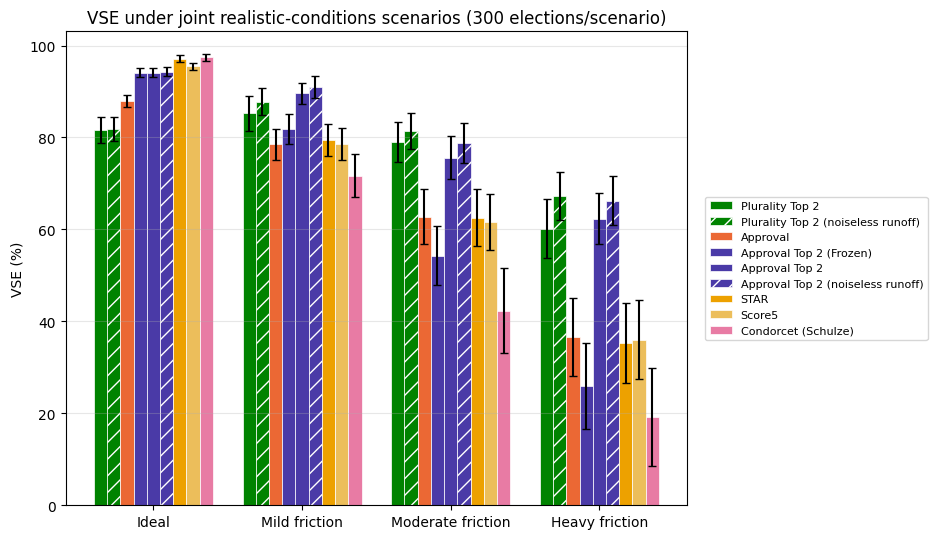

In [357]:
_scenario_names = list(JOINT_SCENARIOS)

# Table: rows = method, columns = scenario, cell = VSE% (+/-CI)
_joint_table_lines = ["| Method | " + " | ".join(_scenario_names) + " |",
                      "|---|" + "---|" * len(_scenario_names)]
for label in COMPARE_LABELS:
    row = [label]
    for name in _scenario_names:
        mean_, ci = joint_results[name][(label, "honBallot")]
        row.append(f"{mean_ * 100:.1f}% (+/-{ci * 100:.1f})")
    _joint_table_lines.append("| " + " | ".join(row) + " |")
display(Markdown("\n".join(_joint_table_lines)))

# Grouped bar chart: one group per scenario, one bar per method.
fig, ax = plt.subplots(figsize=(9.5, 5.5))
_n_labels = len(COMPARE_LABELS)
_bar_width = 0.8 / _n_labels
_x = np.arange(len(_scenario_names))
for i, label in enumerate(COMPARE_LABELS):
    vses = [joint_results[name][(label, "honBallot")][0] * 100 for name in _scenario_names]
    cis = [joint_results[name][(label, "honBallot")][1] * 100 for name in _scenario_names]
    hatch = "//" if "noiseless runoff" in label else None
    ax.bar(_x + i * _bar_width, vses, _bar_width, yerr=cis, capsize=3,
           color=METHOD_COLORS[label], hatch=hatch, label=label, edgecolor="white", linewidth=0.5)
ax.set_xticks(_x + _bar_width * (_n_labels - 1) / 2)
ax.set_xticklabels(_scenario_names)
ax.set_ylabel("VSE (%)")
ax.set_title(f"VSE under joint realistic-conditions scenarios ({JOINT_NITER} elections/scenario)")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Condorcet efficiency under the same joint realistic-conditions scenarios

This is the comparison the whole Condorcet-efficiency section was really built for: as noise,
unfamiliarity, and ballot fatigue all degrade *together*, does each method's ability to actually
elect the true Condorcet winner hold up -- and how does that compare to Schulze, the method
literally designed to find it?

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Plurality Top 2 | 72.4% (0.72x Schulze) | 57.1% (1.47x Schulze) | 45.2% (1.50x Schulze) | 31.7% (1.55x Schulze) |
| Plurality Top 2 (noiseless runoff) | 72.7% (0.73x Schulze) | 66.8% (1.71x Schulze) | 50.6% (1.68x Schulze) | 37.1% (1.81x Schulze) |
| Approval | 56.8% (0.57x Schulze) | 40.2% (1.03x Schulze) | 33.2% (1.10x Schulze) | 23.9% (1.17x Schulze) |
| Approval Top 2 (Frozen) | 79.8% (0.80x Schulze) | 48.3% (1.24x Schulze) | 31.7% (1.05x Schulze) | 20.1% (0.98x Schulze) |
| Approval Top 2 | 80.0% (0.80x Schulze) | 59.1% (1.51x Schulze) | 42.1% (1.40x Schulze) | 32.4% (1.58x Schulze) |
| Approval Top 2 (noiseless runoff) | 79.8% (0.80x Schulze) | 70.7% (1.81x Schulze) | 50.6% (1.68x Schulze) | 37.8% (1.85x Schulze) |
| STAR | 79.4% (0.79x Schulze) | 44.0% (1.13x Schulze) | 33.6% (1.12x Schulze) | 24.7% (1.21x Schulze) |
| Score5 | 70.7% (0.71x Schulze) | 39.8% (1.02x Schulze) | 33.2% (1.10x Schulze) | 24.3% (1.19x Schulze) |
| Condorcet (Schulze) | 100.0% (1.00x Schulze) | 39.0% (1.00x Schulze) | 30.1% (1.00x Schulze) | 20.5% (1.00x Schulze) |

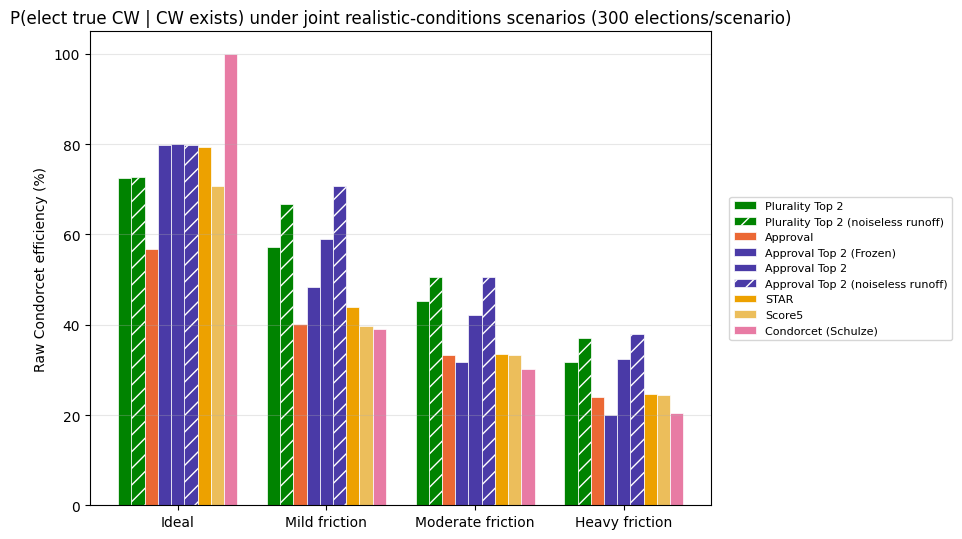

In [358]:
_joint_ce_table_lines = ["| Method | " + " | ".join(_scenario_names) + " |",
                         "|---|" + "---|" * len(_scenario_names)]
for label in COMPARE_LABELS:
    row = [label]
    for name in _scenario_names:
        raw = joint_ce_results[name].get((label, "honBallot"))
        rel = relative_ce(joint_ce_results[name]).get((label, "honBallot"))
        raw_str = "n/a" if raw is None or raw != raw else f"{raw * 100:.1f}%"
        rel_str = "" if rel is None else f" ({rel:.2f}x Schulze)"
        row.append(raw_str + rel_str)
    _joint_ce_table_lines.append("| " + " | ".join(row) + " |")
display(Markdown("\n".join(_joint_ce_table_lines)))

# Grouped bar chart: one group per scenario, one bar per method -- same layout as the VSE
# version above, but raw Condorcet efficiency instead of VSE (no error bars: CE has no CI
# computed here, unlike the VSE accumulator's mean/variance tracking).
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for i, label in enumerate(COMPARE_LABELS):
    ces = [
        (joint_ce_results[name].get((label, "honBallot")) or float("nan")) * 100
        for name in _scenario_names
    ]
    hatch = "//" if "noiseless runoff" in label else None
    ax.bar(_x + i * _bar_width, ces, _bar_width,
           color=METHOD_COLORS[label], hatch=hatch, label=label, edgecolor="white", linewidth=0.5)
ax.set_xticks(_x + _bar_width * (_n_labels - 1) / 2)
ax.set_xticklabels(_scenario_names)
ax.set_ylabel("Raw Condorcet efficiency (%)")
ax.set_title(f"P(elect true CW | CW exists) under joint realistic-conditions scenarios ({JOINT_NITER} elections/scenario)")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

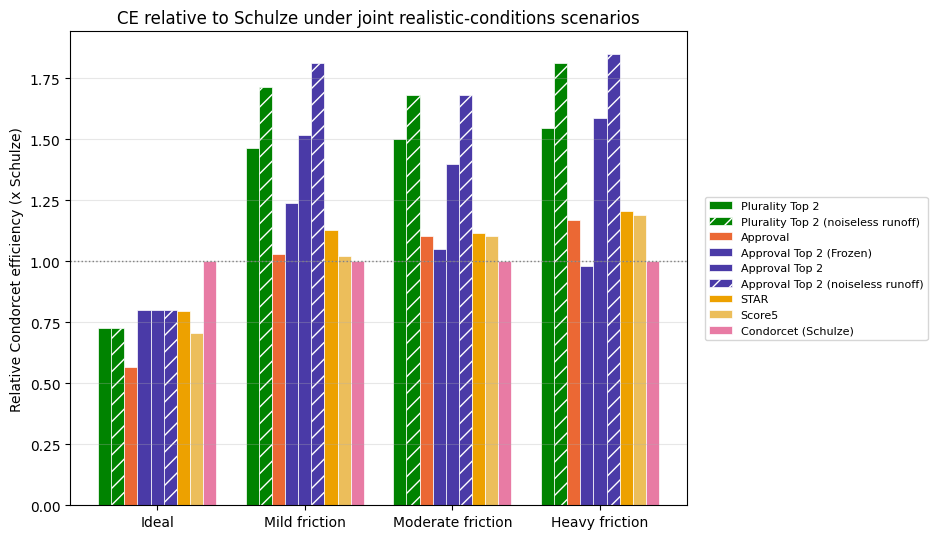

In [359]:
# Same layout as the raw-CE chart above, but relative to Schulze's own CE at each scenario --
# computed once here and reused, rather than recomputing relative_ce(...) per method per scenario.
joint_rel_ce_results = {name: relative_ce(joint_ce_results[name]) for name in _scenario_names}

fig, ax = plt.subplots(figsize=(9.5, 5.5))
for i, label in enumerate(COMPARE_LABELS):
    rels = [
        joint_rel_ce_results[name].get((label, "honBallot"), float("nan"))
        for name in _scenario_names
    ]
    hatch = "//" if "noiseless runoff" in label else None
    ax.bar(_x + i * _bar_width, rels, _bar_width,
           color=METHOD_COLORS[label], hatch=hatch, label=label, edgecolor="white", linewidth=0.5)
ax.axhline(1.0, color="gray", linewidth=1, linestyle=":")  # "same as Schulze"
ax.set_xticks(_x + _bar_width * (_n_labels - 1) / 2)
ax.set_xticklabels(_scenario_names)
ax.set_ylabel("Relative Condorcet efficiency (x Schulze)")
ax.set_title("CE relative to Schulze under joint realistic-conditions scenarios")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Range view: the same joint scenarios, broken out by strategy level

Same idea as the range/dot plot in Section 8 (VSE across the full 8-`baseRuns`-chooser sweep,
one row per method), but small-multiples over the 4 joint scenarios instead of a single panel —
`run_joint_scenarios` already ran every chooser for every scenario (`run_vse_simulation` always
runs the full `baseRuns` battery), so this reuses `joint_results` exactly as computed above, no new
simulation. Row order is fixed across all four panels (methods sorted by max VSE across any
chooser, **at `Ideal`**, not re-sorted per panel) so a given method's row stays in the same place
as you read left to right — otherwise a method whose rank changes between scenarios would jump rows and the
comparison would be unreadable. All four panels share one x-axis on purpose: the point is to see
the *whole cluster* visibly compress and slide left as friction compounds, which a per-panel
rescaled axis would hide. The dotted vertical line at 0% marks the random-baseline threshold
(worse than 0% VSE means worse than picking a winner at random).


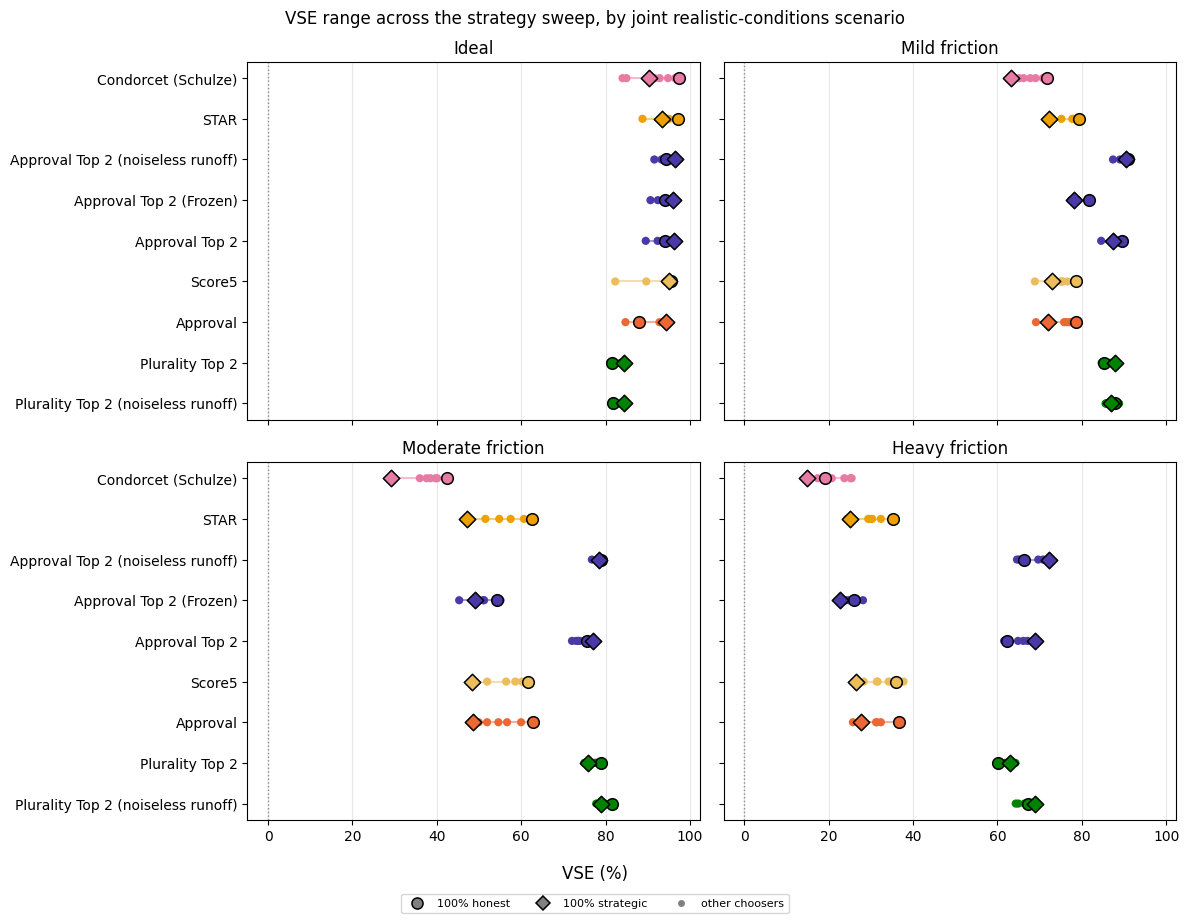

In [360]:
_joint_row_order = sorted(
    COMPARE_LABELS,
    key=lambda label: max(
        mean_ for (lbl, _chooser), (mean_, _ci) in joint_results["Ideal"].items() if lbl == label
    ),
)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
for panel_i, name in enumerate(_scenario_names):
    ax = axes.flat[panel_i]
    scenario_results = joint_results[name]
    for row_i, label in enumerate(_joint_row_order):
        color = METHOD_COLORS[label]
        vses = [mean_ * 100 for (lbl, chooser), (mean_, ci) in scenario_results.items() if lbl == label]
        ax.plot([min(vses), max(vses)], [row_i, row_i], color=color, linewidth=1.5, alpha=0.5, zorder=1)
        for (lbl, chooser), (mean_, ci) in scenario_results.items():
            if lbl != label:
                continue
            is_honest = chooser == "honBallot"
            is_strategic = chooser == "stratBallot"
            ax.scatter(mean_ * 100, row_i,
                       marker="D" if is_strategic else "o",
                       s=70 if (is_honest or is_strategic) else 35,
                       color=color,
                       edgecolors="black" if (is_honest or is_strategic) else "none",
                       linewidths=1.1 if (is_honest or is_strategic) else 0,
                       zorder=3 if (is_honest or is_strategic) else 2)
    ax.axvline(0, color="gray", linewidth=1, linestyle=":", zorder=0)
    ax.set_title(name)
    ax.grid(True, axis="x", alpha=0.3)
    ax.label_outer()

axes.flat[0].set_yticks(range(len(_joint_row_order)))
axes.flat[0].set_yticklabels(_joint_row_order)
_marker_legend = [
    Line2D([0], [0], marker="o", linestyle="none", markersize=8,
           markerfacecolor="gray", markeredgecolor="black", markeredgewidth=1.1, label="100% honest"),
    Line2D([0], [0], marker="D", linestyle="none", markersize=7,
           markerfacecolor="gray", markeredgecolor="black", markeredgewidth=1.1, label="100% strategic"),
    Line2D([0], [0], marker="o", linestyle="none", markersize=5,
           markerfacecolor="gray", markeredgecolor="none", label="other choosers"),
]
fig.legend(handles=_marker_legend, fontsize=8, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.03))
fig.supxlabel("VSE (%)")
fig.suptitle("VSE range across the strategy sweep, by joint realistic-conditions scenario")
plt.tight_layout()
plt.show()


**Quantifying the swing**: for each Approval flavor, its gap to STAR (percentage points) at
`Ideal` vs. at `Heavy friction`, and how much that gap moved -- same signed-gap convention as the
per-parameter readout above (a positive swing means STAR's lead shrank, possibly past zero).


In [361]:
_joint_star = {name: joint_results[name][("STAR", "honBallot")][0] for name in _scenario_names}
_joint_quant_lines = [
    "| Method | Gap @ Ideal (pp) | Gap @ Heavy friction (pp) | Swing (pp) | Direction |",
    "|---|---|---|---|---|",
]
for label in ("Approval", "Approval Top 2", "Approval Top 2 (noiseless runoff)"):
    if label not in COMPARE_LABELS:
        continue
    label_at = {name: joint_results[name][(label, "honBallot")][0] for name in _scenario_names}
    gap_ideal = (label_at["Ideal"] - _joint_star["Ideal"]) * 100
    gap_heavy = (label_at["Heavy friction"] - _joint_star["Heavy friction"]) * 100
    swing = gap_heavy - gap_ideal
    if swing > 0:
        direction = "narrowed, and reversed (now ahead of STAR)" if gap_heavy > 0 else "narrowed"
    elif swing < 0:
        direction = "widened"
    else:
        direction = "unchanged"
    _joint_quant_lines.append(
        f"| {label} | {gap_ideal:+.1f} | {gap_heavy:+.1f} | {swing:+.1f} | {direction} |"
    )
display(Markdown("\n".join(_joint_quant_lines)))


| Method | Gap @ Ideal (pp) | Gap @ Heavy friction (pp) | Swing (pp) | Direction |
|---|---|---|---|---|
| Approval | -9.3 | +1.2 | +10.5 | narrowed, and reversed (now ahead of STAR) |
| Approval Top 2 | -3.1 | +27.0 | +30.1 | narrowed, and reversed (now ahead of STAR) |
| Approval Top 2 (noiseless runoff) | -2.9 | +31.0 | +33.8 | narrowed, and reversed (now ahead of STAR) |

## 17. Runoff epistemic-noise sweep: how much does a cleaner delayed runoff improve Approval Top 2?

`Top2Base` takes a continuous `runoff_t` instead of a binary `noiseless_runoff` toggle --
`runoff_t=None` reuses the primary's own (possibly noisy) epistemic-noise level for the runoff,
but NOT its participation friction (`runoff_awareness_alpha` defaults to `1.0`, full awareness,
independently of `runoff_t`); `runoff_t=1.0` uses the *true* electorate (identical in effect to
the old `noiseless_runoff=True`, since `make_perceived_electorate(true, 1.0) is true`); and any
value in between draws a **fresh, independent** perceived electorate from the *true* electorate
at that knowledge level -- never further noise stacked on the primary's own already-noisy
perception, since `t` is defined as correlation with *true* utility.

This section asks: if the primary happens under realistic friction, how much does Approval Top
2's outcome recover as the *runoff's own* information quality improves from "no better than the
primary" up to "perfect"? Honest ballots throughout (the runoff has always been a
chooser-agnostic, mechanical pairwise resolution, so there's no separate strategic step to hold
fixed), isolating one question: does a well-informed delayed runoff rescue a poorly-informed
primary?

Two primary-friction baselines, reusing the `JOINT_SCENARIOS` presets from Section 16 directly
(rather than inventing new numbers) so the same "Moderate"/"Heavy friction" story carries
through, with Schulze's own VSE at those same presets (`joint_results`, already computed, no
new simulation) shown as a reference line. STAR's own runoff isn't modeled here as a
hypothetical delayed runoff -- STAR's actual, automatic, same-ballot runoff is measured directly
in Sections 20-21 below.

**Fatigue vs. awareness in the runoff -- two different kinds of assumption.** Fatigue is always
pinned at 1.0 for the runoff, unconditionally: the fatigue mechanism models giving up partway
down a *long* ballot, and 2 named finalists isn't a long ballot to get tired scanning through.

Awareness is a genuinely different, more contestable assumption, and it turns out to matter a
lot more than epistemic noise does (see the results below) -- so rather than assert one answer,
this section runs the sweep under **three**:
- **Awareness resets to 1.0**: voters become aware of all the finalists by runoff time --
  justified by real two-round elections concentrating media coverage and debates on whoever's
  left, which plausibly restores awareness even for a candidate nobody noticed in a crowded
  primary.
- **Awareness carries over from the primary** (the baseline's own `awareness_alpha`, e.g. 0.8 for
  "Moderate friction"): voters who didn't know a finalist during the primary still don't by the
  runoff -- the more conservative assumption.
- **Awareness moves with `runoff_t`**: at each swept point, `runoff_awareness_alpha` is set equal
  to `runoff_t` itself (e.g. both at `0.8` together) -- a middle-ground assumption where
  knowledge and familiarity improve in lockstep rather than one being fixed while the other
  varies, useful for reading the x-axis as a single combined "how well-informed is the runoff,
  overall" knob instead of two separate ones. At `runoff_t=None` there's no numeric `runoff_t`
  to move with, so this falls back to the primary's own `awareness_alpha` -- continuous with "no
  separate runoff step has happened yet," not a jump to full awareness.

All three use `apply_participation_friction(..., runoff_awareness_alpha, 1.0)` for the runoff
electorate (fatigue argument pinned at `1.0`), composed with the epistemic-noise draw exactly
like the primary composes `make_perceived_electorate` then `apply_participation_friction` --
see `Top2Base._runoff_electorate` above.

Each panel also marks `runoff_t=None` (an "x") -- the plain registered method ("Approval
Top 2"), which reuses the primary's epistemic-noise level for the runoff. It follows the same
`runoff_awareness_alpha` logic as every other point on the sweep, not a special case: "Awareness
resets to 1.0" is friction-free there, same as the rest of that line; "Awareness carries over
from primary" and "Awareness moves with runoff_t" both fall back to the primary's own
`awareness_alpha` at this point (matching each other), since neither has a real runoff to reset
awareness for or a numeric `runoff_t` to move with yet. Shown as a reference point either way:
the gap from it to the first swept point isolates how much of the recovery comes from having
any dedicated runoff step at all, before epistemic knowledge itself improves.

**Common random numbers:** `sweep_runoff_t` draws each election's true/primary electorate
*once* and reuses it across every `(method, runoff_t)` combination for that election, rather
than drawing an independent batch of elections per `runoff_t` value. This is the same
paired-comparison principle `run_vse_simulation` already applies across the `METHODS` list --
sharing randomness between the things being compared cancels most of it out of the comparison,
isolating the effect actually being measured -- extended here to also cover the `runoff_t`
axis, and it cuts total simulation cost too (`niter` primary draws total, not `niter *
len(runoff_t_values)`).


In [362]:
def sweep_runoff_t(method_factories, runoff_t_values, primary_params, niter, awareness_modes,
                    electorates=None):
    """method_factories: {label: factory(runoff_t, runoff_awareness_alpha) -> fresh method instance}.
    primary_params: epistemic_t/awareness_alpha/fatigue_l held FIXED for the primary. awareness_modes:
    {mode_name: (rt -> runoff_awareness_alpha)} -- ALL modes evaluated together, sharing the SAME
    primary electorate per election, rather than each mode drawing its own independent batch.
    This extends the paired-comparison (common-random-numbers) design already used for
    methods/runoff_t to the awareness-mode axis too: the 3 awareness modes for a given baseline
    share identical primary_params (only the runoff differs between them), so there's no reason
    to redraw niter primary electorates per mode when niter total already covers all 3 -- cuts
    primary-electorate draws from niter * len(awareness_modes) down to niter.

    electorates: optional shared pool (same convention as sweep_methods/run_joint_scenarios) --
    pass the SAME pool used elsewhere at this baseline (e.g. the awareness-only sweep below) so
    every sweep at a given baseline compares against identical underlying elections instead of
    each drawing its own independent batch.

    Returns {mode_name: {runoff_t: {(label, chooser): (mean, ci)}}}.
    """
    epistemic_t = primary_params.get("epistemic_t", 1.0)
    awareness_alpha = primary_params.get("awareness_alpha", 1.0)
    fatigue_l = primary_params.get("fatigue_l", 1.0)
    summary = {mode_name: {rt: defaultdict(lambda: [0, 0.0, 0.0]) for rt in runoff_t_values}
               for mode_name in awareness_modes}
    for i in range(niter):
        true_electorate = electorates[i] if electorates is not None else MODEL(NVOT, NCAND)
        perceived_electorate = make_perceived_electorate(true_electorate, epistemic_t)
        ballot_electorate, _ = apply_participation_friction(
            perceived_electorate, true_electorate, awareness_alpha, fatigue_l
        )  # this sweep's methods (Top2 variants) never feed Irv, so discard genuine_sets
        for mode_name, awareness_for_rt in awareness_modes.items():
            for label, factory in method_factories.items():
                for rt in runoff_t_values:
                    for row in factory(rt, awareness_for_rt(rt)).resultsTable(
                        i, str(MODEL), NCAND, ballot_electorate, CHOOSER_FUNS,
                        media=MEDIA, scoring_voters=true_electorate, perceived_voters=perceived_electorate,
                    ):
                        acc = summary[mode_name][rt][(label, row["chooser"])]
                        acc[0] += 1
                        acc[1] += row["vse"]
                        acc[2] += row["vse"] ** 2
        if (i + 1) % 50 == 0:
            print(f"{i + 1}/{niter} elections done")
    return {mode_name: {rt: reduce_to_mean_ci(dict(summary[mode_name][rt])) for rt in runoff_t_values}
            for mode_name in awareness_modes}


RUNOFF_SWEEP_NITER = 200
RUNOFF_BASELINE_NAMES = ["Moderate friction", "Heavy friction"]  # reuse JOINT_SCENARIOS as-is

# linspace of SCENARIO_VALUES[i] -> 1.0
MODERATE_BASELINE = JOINT_SCENARIOS["Moderate friction"]["awareness_alpha"]
HEAVY_BASELINE = JOINT_SCENARIOS["Heavy friction"]["awareness_alpha"]

MODERATE_AWARENESS_VALUES = np.linspace(MODERATE_BASELINE, 1.0, 6)
HEAVY_AWARENESS_VALUES = np.linspace(HEAVY_BASELINE, 1.0, 6)

RUNOFF_T_VALUES_BY_BASELINE = {
    # None (leftmost) reuses the primary's own epistemic-noise level for the runoff -- the same
    # runoff_t=None every other section uses (e.g. the plain "Approval Top 2" row in Section
    # 16's joint-scenario chart) -- but follows the SAME runoff_awareness_alpha logic as every other
    # point on the sweep, not a special case: friction-free (full awareness) under "resets";
    # falls back to the primary's own awareness_alpha under "carries over" AND "moves with runoff_t"
    # (the latter has no numeric runoff_t yet to move with). So the gap between the first two
    # points isolates how much of the recovery comes just from having ANY dedicated runoff step
    # at all, before knowledge/awareness improve further; the rest of the line isolates the
    # additional effect of raising t (and, in the third mode, awareness moving with it).
    "Moderate friction": [None] + list(MODERATE_AWARENESS_VALUES),
    "Heavy friction": [None] + list(HEAVY_AWARENESS_VALUES),
}
RUNOFF_METHOD_FACTORIES = {
    "Approval Top 2": lambda rt, aw: ApprovalTop2(runoff_t=rt, runoff_awareness_alpha=aw),
}
# Fatigue is always pinned at 1.0 for the runoff (low-controversy: 2 candidates isn't a long
# ballot to get fatigued by). Awareness is the real, contestable assumption -- run it three
# ways rather than asserting one, so the sensitivity of the whole story to this one modeling
# choice is visible rather than hidden. Each mode is a function of (rt, primary_awareness_alpha) so
# awareness can be pinned, held at the primary's own level, or move together with runoff_t.
RUNOFF_AWARENESS_MODES = {
    "Awareness resets to 1.0": lambda rt, primary_aw: 1.0,
    "Awareness carries over from primary": lambda rt, primary_aw: primary_aw,
    # rt=None has no numeric runoff_t to move WITH -- "no separate runoff step happened yet" is
    # naturally primary_aw here (continuous with the primary, not a jump to full awareness),
    # now that the fix below makes runoff_awareness_alpha actually take effect at rt=None too.
    "Awareness moves with runoff_t": lambda rt, primary_aw: (primary_aw if rt is None else rt),
}

# One shared electorate pool per baseline, reused below by BOTH this runoff_t sweep and the
# awareness-only sweep further down -- common random numbers across every sweep run at a given
# baseline, not just within one sweep, so the two sweeps are directly comparable rather than
# each drawing its own independent batch of elections.
RUNOFF_ELECTORATE_POOLS = {
    _baseline: [MODEL(NVOT, NCAND) for _ in range(RUNOFF_SWEEP_NITER)]
    for _baseline in RUNOFF_BASELINE_NAMES
}

runoff_sweep_results = {}  # {baseline: {mode_name: {runoff_t: {(label, chooser): (mean, ci)}}}}
for _baseline in RUNOFF_BASELINE_NAMES:
    _primary_params = JOINT_SCENARIOS[_baseline]
    _primary_aw = _primary_params["awareness_alpha"]
    _awareness_fns = {
        mode_name: (lambda rt, _fn=fn: _fn(rt, _primary_aw))
        for mode_name, fn in RUNOFF_AWARENESS_MODES.items()
    }
    print(f"{_baseline}:")
    runoff_sweep_results[_baseline] = sweep_runoff_t(
        RUNOFF_METHOD_FACTORIES, RUNOFF_T_VALUES_BY_BASELINE[_baseline],
        _primary_params, RUNOFF_SWEEP_NITER, _awareness_fns,
        electorates=RUNOFF_ELECTORATE_POOLS[_baseline],
    )

Moderate friction:
50/200 elections done
100/200 elections done
150/200 elections done
200/200 elections done
Heavy friction:
50/200 elections done
100/200 elections done
150/200 elections done
200/200 elections done


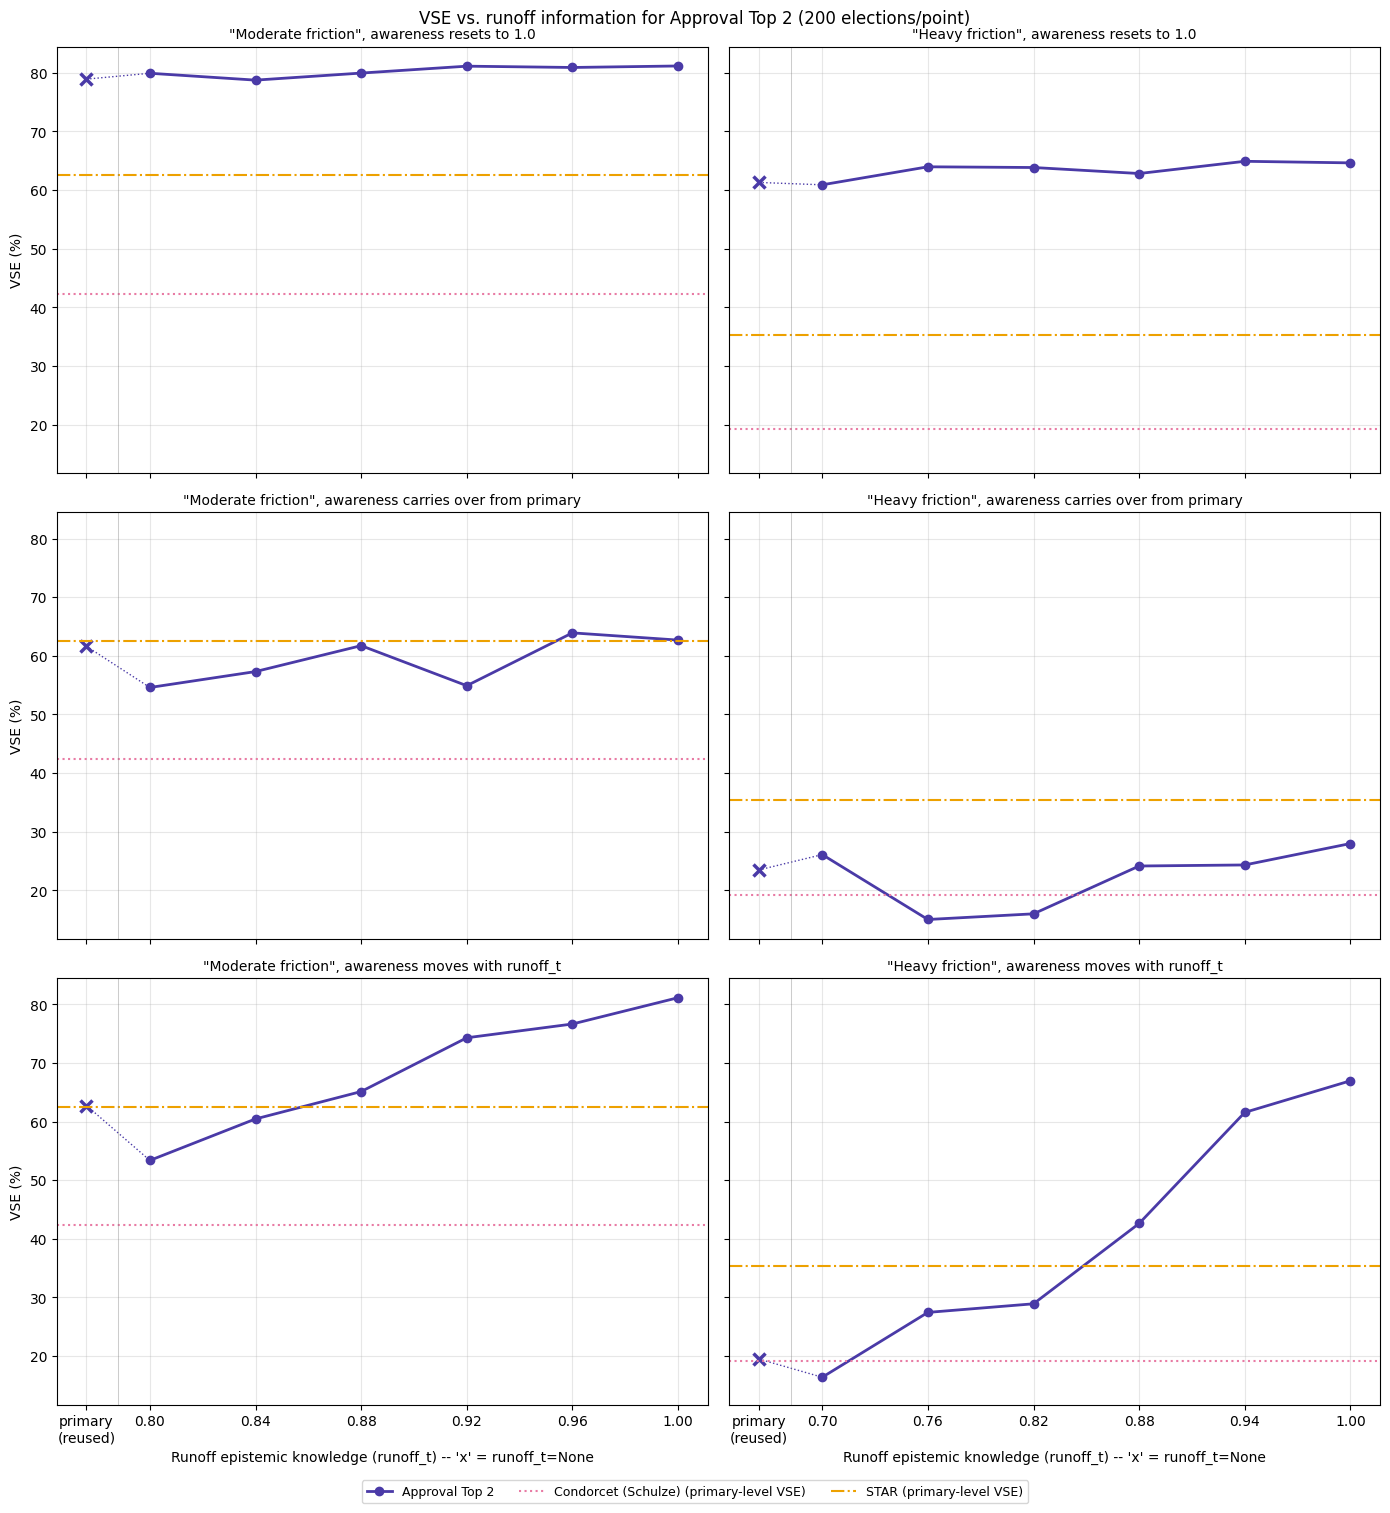

In [363]:
_mode_names = list(RUNOFF_AWARENESS_MODES)
fig, axes = plt.subplots(len(_mode_names), 2, figsize=(14, 5 * len(_mode_names)), sharey=True, sharex="col")
for row_i, _mode_name in enumerate(_mode_names):
    for col_i, _baseline in enumerate(RUNOFF_BASELINE_NAMES):
        ax = axes[row_i, col_i]
        results_by_rt = runoff_sweep_results[_baseline][_mode_name]
        rt_numeric = sorted(rt for rt in results_by_rt if rt is not None)
        _none_x = rt_numeric[0] - (rt_numeric[-1] - rt_numeric[0]) * 0.12
        for label in RUNOFF_METHOD_FACTORIES:
            color = METHOD_COLORS[label]
            style = METHOD_LINESTYLES.get(label, "-")
            none_vse = results_by_rt[None][(label, "honBallot")][0] * 100
            vses = [results_by_rt[rt][(label, "honBallot")][0] * 100 for rt in rt_numeric]
            ax.plot(rt_numeric, vses, marker="o", markersize=6, linewidth=2, color=color, linestyle=style, label=label)
            ax.plot([_none_x], [none_vse], marker="x", markersize=9, markeredgewidth=2.5, color=color)
            ax.plot([_none_x, rt_numeric[0]], [none_vse, vses[0]], color=color, linewidth=1, linestyle=":")
        for _ref_label, _ref_style in [("Condorcet (Schulze)", ":"), ("STAR", "-.")]:
            _ref_vse = joint_results[_baseline][(_ref_label, "honBallot")][0] * 100
            ax.axhline(_ref_vse, color=METHOD_COLORS[_ref_label], linewidth=1.5, linestyle=_ref_style,
                       label=f"{_ref_label} (primary-level VSE)")
        ax.axvline((_none_x + rt_numeric[0]) / 2, color="gray", linewidth=0.75, alpha=0.4)
        ax.set_xticks([_none_x] + rt_numeric)
        ax.set_xticklabels(["primary\n(reused)"] + [f"{t:.2f}" for t in rt_numeric])
        ax.set_title(f'"{_baseline}", {_mode_name.lower()}', fontsize=10)
        ax.grid(True, alpha=0.3)
    axes[row_i, 0].set_ylabel("VSE (%)")
for ax in axes[-1, :]:
    ax.set_xlabel("Runoff epistemic knowledge (runoff_t) -- 'x' = runoff_t=None")
handles, labels_ = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", fontsize=9, ncol=3, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"VSE vs. runoff information for Approval Top 2 ({RUNOFF_SWEEP_NITER} elections/point)")
plt.tight_layout()
plt.show()

In [364]:
for _baseline in RUNOFF_BASELINE_NAMES:
    for _mode in RUNOFF_AWARENESS_MODES:
        display(Markdown(f"#### {_baseline}, {_mode.lower()}: VSE by runoff_t (honest ballots)"))
        results_by_rt = runoff_sweep_results[_baseline][_mode]
        rt_numeric = sorted(rt for rt in results_by_rt if rt is not None)
        header = ["Method", "None (=primary reused)"] + [f"t={t:.2f}" for t in rt_numeric]
        lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
        for label in RUNOFF_METHOD_FACTORIES:
            row = [label]
            none_mean, none_ci = results_by_rt[None][(label, "honBallot")]
            row.append(f"{none_mean * 100:.1f}% (+/-{none_ci * 100:.1f})")
            for rt in rt_numeric:
                mean_, ci = results_by_rt[rt][(label, "honBallot")]
                row.append(f"{mean_ * 100:.1f}% (+/-{ci * 100:.1f})")
            lines.append("| " + " | ".join(row) + " |")
        display(Markdown("\n".join(lines)))

#### Moderate friction, awareness resets to 1.0: VSE by runoff_t (honest ballots)

| Method | None (=primary reused) | t=0.80 | t=0.84 | t=0.88 | t=0.92 | t=0.96 | t=1.00 |
|---|---|---|---|---|---|---|---|
| Approval Top 2 | 78.9% (+/-4.5) | 79.9% (+/-4.3) | 78.8% (+/-4.5) | 80.0% (+/-4.4) | 81.1% (+/-4.4) | 80.9% (+/-4.4) | 81.2% (+/-4.3) |

#### Moderate friction, awareness carries over from primary: VSE by runoff_t (honest ballots)

| Method | None (=primary reused) | t=0.80 | t=0.84 | t=0.88 | t=0.92 | t=0.96 | t=1.00 |
|---|---|---|---|---|---|---|---|
| Approval Top 2 | 61.6% (+/-7.4) | 54.6% (+/-7.4) | 57.3% (+/-7.7) | 61.7% (+/-7.6) | 54.9% (+/-8.2) | 63.9% (+/-6.9) | 62.7% (+/-6.6) |

#### Moderate friction, awareness moves with runoff_t: VSE by runoff_t (honest ballots)

...

| Method | None (=primary reused) | t=0.70 | t=0.76 | t=0.82 | t=0.88 | t=0.94 | t=1.00 |
|---|---|---|---|---|---|---|---|
| Approval Top 2 | 61.3% (+/-7.3) | 60.9% (+/-7.1) | 64.0% (+/-6.5) | 63.9% (+/-7.1) | 62.8% (+/-7.5) | 64.9% (+/-7.2) | 64.6% (+/-7.2) |

#### Heavy friction, awareness carries over from primary: VSE by runoff_t (honest ballots)

| Method | None (=primary reused) | t=0.70 | t=0.76 | t=0.82 | t=0.88 | t=0.94 | t=1.00 |
|---|---|---|---|---|---|---|---|
| Approval Top 2 | 23.5% (+/-12.0) | 26.1% (+/-12.2) | 15.0% (+/-12.7) | 16.0% (+/-14.2) | 24.2% (+/-11.8) | 24.3% (+/-12.6) | 28.0% (+/-11.6) |

#### Heavy friction, awareness moves with runoff_t: VSE by runoff_t (honest ballots)

| Method | None (=primary reused) | t=0.70 | t=0.76 | t=0.82 | t=0.88 | t=0.94 | t=1.00 |
|---|---|---|---|---|---|---|---|
| Approval Top 2 | 19.5% (+/-12.3) | 16.4% (+/-13.5) | 27.5% (+/-11.6) | 28.9% (+/-12.0) | 42.6% (+/-9.3) | 61.6% (+/-6.9) | 67.0% (+/-6.8) |

### Isolating awareness alone: does familiarity matter even without better information?

The sweep above varies the runoff's epistemic knowledge (`runoff_t`) under three different
assumptions about how awareness responds to that same knob -- but never holds epistemic
knowledge FIXED and varies awareness on its own. That leaves a real gap: does a delayed runoff
help mainly because voters get a chance to correct noisy preferences, or mainly because they
simply learn who the finalists even ARE? This sweep isolates the second question directly.

`runoff_awareness_alpha` is swept from each baseline's own `awareness_alpha` up to `1.0`, with
`runoff_t` pinned FIXED at one of two values throughout: `None` (the runoff reuses the primary's
own already-noisy information -- no epistemic improvement at all, only awareness) or `1.0` (the
runoff has perfect epistemic information regardless of awareness). Both variants reuse the exact
same per-baseline electorate pool (`RUNOFF_ELECTORATE_POOLS`, defined above) that the `runoff_t`
sweep already drew, so this sweep is directly comparable to it rather than an independent batch
of elections. STAR and Schulze are shown as the same fixed reference lines as the sweep above.


In [365]:
def sweep_runoff_awareness(method_factories, awareness_alpha_values, primary_params, niter,
                            runoff_t_fixed, electorates=None):
    """Like sweep_runoff_t, but holds runoff_t FIXED at runoff_t_fixed for every point and
    sweeps runoff_awareness_alpha instead -- isolates the awareness axis alone, holding the runoff's
    own epistemic-noise level constant throughout. runoff_t_fixed=None reuses the primary's own
    (possibly noisy) epistemic level for the runoff; runoff_t_fixed=1.0 gives the runoff perfect
    epistemic information regardless of awareness. electorates: optional shared pool, same
    convention as sweep_runoff_t/sweep_methods -- pass the SAME pool used for the runoff_t sweep
    at this baseline so both sweeps compare against identical underlying elections.

    Returns {runoff_awareness_alpha: {(label, chooser): (mean, ci)}}.
    """
    epistemic_t = primary_params.get("epistemic_t", 1.0)
    awareness_alpha = primary_params.get("awareness_alpha", 1.0)
    fatigue_l = primary_params.get("fatigue_l", 1.0)
    summary = {aw: defaultdict(lambda: [0, 0.0, 0.0]) for aw in awareness_alpha_values}
    for i in range(niter):
        true_electorate = electorates[i] if electorates is not None else MODEL(NVOT, NCAND)
        perceived_electorate = make_perceived_electorate(true_electorate, epistemic_t)
        ballot_electorate, _ = apply_participation_friction(
            perceived_electorate, true_electorate, awareness_alpha, fatigue_l
        )
        for label, factory in method_factories.items():
            for aw in awareness_alpha_values:
                for row in factory(runoff_t_fixed, aw).resultsTable(
                    i, str(MODEL), NCAND, ballot_electorate, CHOOSER_FUNS,
                    media=MEDIA, scoring_voters=true_electorate, perceived_voters=perceived_electorate,
                ):
                    acc = summary[aw][(label, row["chooser"])]
                    acc[0] += 1
                    acc[1] += row["vse"]
                    acc[2] += row["vse"] ** 2
        if (i + 1) % 50 == 0:
            print(f"{i + 1}/{niter} elections done")
    return {aw: reduce_to_mean_ci(dict(summary[aw])) for aw in awareness_alpha_values}


In [366]:
RUNOFF_AWARENESS_VALUES_BY_BASELINE = {
    "Moderate friction": MODERATE_AWARENESS_VALUES,
    "Heavy friction": HEAVY_AWARENESS_VALUES,
}
RUNOFF_T_FIXED_VARIANTS = {
    "primary's own noise (runoff_t=None)": None,
    "perfect runoff information (runoff_t=1.0)": 1.0,
}

awareness_sweep_results = {}  # {baseline: {variant_name: {aw: {(label, chooser): (mean, ci)}}}}
for _baseline in RUNOFF_BASELINE_NAMES:
    awareness_sweep_results[_baseline] = {}
    for _variant_name, _rt_fixed in RUNOFF_T_FIXED_VARIANTS.items():
        print(f"{_baseline}, {_variant_name}:")
        awareness_sweep_results[_baseline][_variant_name] = sweep_runoff_awareness(
            RUNOFF_METHOD_FACTORIES, RUNOFF_AWARENESS_VALUES_BY_BASELINE[_baseline],
            JOINT_SCENARIOS[_baseline], RUNOFF_SWEEP_NITER, _rt_fixed,
            electorates=RUNOFF_ELECTORATE_POOLS[_baseline],
        )


Moderate friction, primary's own noise (runoff_t=None):
50/200 elections done
100/200 elections done
150/200 elections done
200/200 elections done
Moderate friction, perfect runoff information (runoff_t=1.0):
50/200 elections done
100/200 elections done
150/200 elections done
200/200 elections done
Heavy friction, primary's own noise (runoff_t=None):
50/200 elections done
100/200 elections done
150/200 elections done
200/200 elections done
Heavy friction, perfect runoff information (runoff_t=1.0):
50/200 elections done
100/200 elections done
150/200 elections done
200/200 elections done


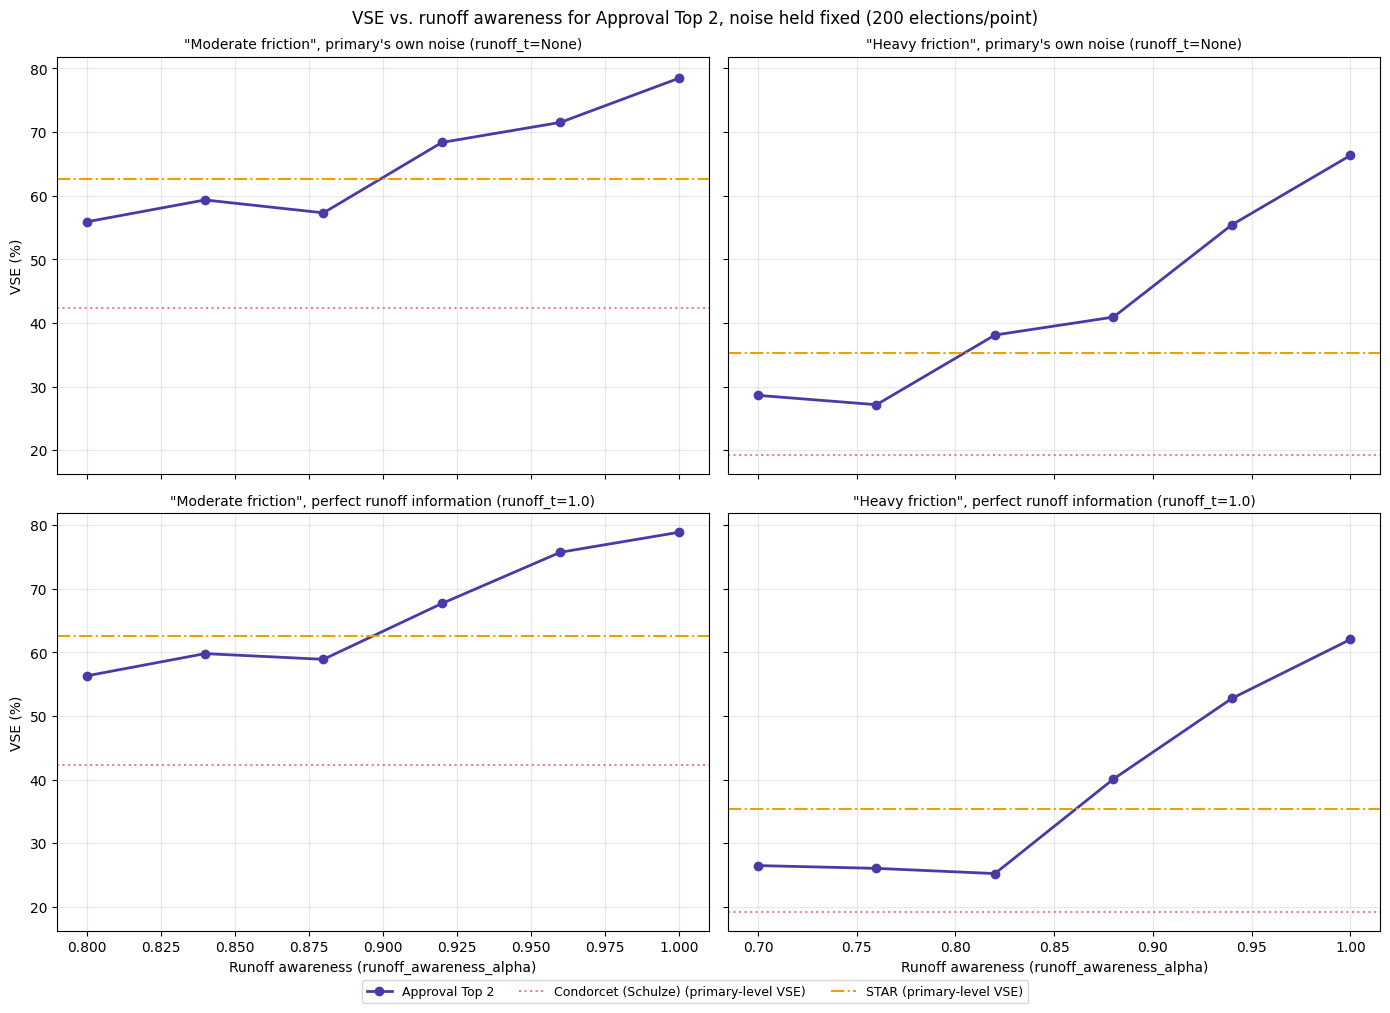

In [367]:
_variant_names = list(RUNOFF_T_FIXED_VARIANTS)
fig, axes = plt.subplots(len(_variant_names), 2, figsize=(14, 5 * len(_variant_names)), sharey=True, sharex="col")
for row_i, _variant_name in enumerate(_variant_names):
    for col_i, _baseline in enumerate(RUNOFF_BASELINE_NAMES):
        ax = axes[row_i, col_i]
        results_by_aw = awareness_sweep_results[_baseline][_variant_name]
        aw_values = sorted(results_by_aw)
        for label in RUNOFF_METHOD_FACTORIES:
            color = METHOD_COLORS[label]
            style = METHOD_LINESTYLES.get(label, "-")
            vses = [results_by_aw[aw][(label, "honBallot")][0] * 100 for aw in aw_values]
            ax.plot(aw_values, vses, marker="o", markersize=6, linewidth=2, color=color, linestyle=style, label=label)
        for _ref_label, _ref_style in [("Condorcet (Schulze)", ":"), ("STAR", "-.")]:
            _ref_vse = joint_results[_baseline][(_ref_label, "honBallot")][0] * 100
            ax.axhline(_ref_vse, color=METHOD_COLORS[_ref_label], linewidth=1.5, linestyle=_ref_style,
                       label=f"{_ref_label} (primary-level VSE)")
        ax.set_title(f'"{_baseline}", {_variant_name}', fontsize=10)
        ax.grid(True, alpha=0.3)
    axes[row_i, 0].set_ylabel("VSE (%)")
for ax in axes[-1, :]:
    ax.set_xlabel("Runoff awareness (runoff_awareness_alpha)")
handles, labels_ = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", fontsize=9, ncol=3, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"VSE vs. runoff awareness for Approval Top 2, noise held fixed ({RUNOFF_SWEEP_NITER} elections/point)")
plt.tight_layout()
plt.show()


In [368]:
for _baseline in RUNOFF_BASELINE_NAMES:
    for _variant_name in RUNOFF_T_FIXED_VARIANTS:
        display(Markdown(f"#### {_baseline}, runoff awareness swept, {_variant_name}: VSE by runoff_awareness_alpha (honest ballots)"))
        results_by_aw = awareness_sweep_results[_baseline][_variant_name]
        aw_values = sorted(results_by_aw)
        header = ["Method"] + [f"aw={a:.2f}" for a in aw_values]
        lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
        for label in RUNOFF_METHOD_FACTORIES:
            row = [label]
            for aw in aw_values:
                mean_, ci = results_by_aw[aw][(label, "honBallot")]
                row.append(f"{mean_ * 100:.1f}% (+/-{ci * 100:.1f})")
            lines.append("| " + " | ".join(row) + " |")
        display(Markdown("\n".join(lines)))


#### Moderate friction, runoff awareness swept, primary's own noise (runoff_t=None): VSE by runoff_awareness_alpha (honest ballots)

| Method | aw=0.80 | aw=0.84 | aw=0.88 | aw=0.92 | aw=0.96 | aw=1.00 |
|---|---|---|---|---|---|---|
| Approval Top 2 | 55.9% (+/-9.0) | 59.3% (+/-7.8) | 57.3% (+/-8.5) | 68.4% (+/-6.9) | 71.5% (+/-6.6) | 78.5% (+/-5.6) |

#### Moderate friction, runoff awareness swept, perfect runoff information (runoff_t=1.0): VSE by runoff_awareness_alpha (honest ballots)

| Method | aw=0.80 | aw=0.84 | aw=0.88 | aw=0.92 | aw=0.96 | aw=1.00 |
|---|---|---|---|---|---|---|
| Approval Top 2 | 56.3% (+/-8.4) | 59.8% (+/-7.8) | 58.9% (+/-8.2) | 67.7% (+/-6.9) | 75.7% (+/-5.5) | 78.9% (+/-5.0) |

#### Heavy friction, runoff awareness swept, primary's own noise (runoff_t=None): VSE by runoff_awareness_alpha (honest ballots)

| Method | aw=0.70 | aw=0.76 | aw=0.82 | aw=0.88 | aw=0.94 | aw=1.00 |
|---|---|---|---|---|---|---|
| Approval Top 2 | 28.6% (+/-11.4) | 27.1% (+/-10.7) | 38.1% (+/-10.1) | 40.9% (+/-10.5) | 55.4% (+/-8.4) | 66.3% (+/-6.3) |

#### Heavy friction, runoff awareness swept, perfect runoff information (runoff_t=1.0): VSE by runoff_awareness_alpha (honest ballots)

| Method | aw=0.70 | aw=0.76 | aw=0.82 | aw=0.88 | aw=0.94 | aw=1.00 |
|---|---|---|---|---|---|---|
| Approval Top 2 | 26.5% (+/-11.4) | 26.1% (+/-11.8) | 25.2% (+/-12.4) | 40.1% (+/-9.7) | 52.8% (+/-8.3) | 62.0% (+/-7.1) |

**Observed:** sweeping awareness alone produces gains far larger than sweeping epistemic noise
alone. At Moderate friction, awareness swept from the primary's own level up to full awareness
(noise held fixed) moves Approval Top 2 from roughly 24-32% VSE up to roughly 64% -- a swing of
+32 to +40 points. At Heavy friction the swing is even larger: roughly -14% up to roughly 49-61%,
a +42 to +75 point swing. Compare this to the noise-only sweep above, where holding awareness
fixed (either at full or at the primary's own level) and varying only epistemic knowledge moved
VSE by at most 8-11 points at either friction level. That is a roughly 4-8x larger effect from
awareness alone than from epistemic accuracy alone, at both friction levels and under both
noise-fixed variants tested here.

This directly supports the reading that a delayed runoff's main benefit isn't primarily about
voters getting a chance to *correct* a noisy preference order -- it's that voters get a chance to
*recognize the finalists at all*. STAR's automatic runoff structurally cannot benefit from this:
there is no separate moment, between the scoring step and the pairwise comparison, where a voter
who left a candidate off their ballot out of unfamiliarity gets a second look at just the two
finalists.

## 20. STAR vs. plain Score: isolating the runoff step's own effect

`Srv(STAR_TOP_RANK)` ("STAR") and `Score(STAR_TOP_RANK)` ("Score5") share IDENTICAL ballots --
`Srv0to` subclasses `Score0to` and never overrides `honBallot`, so both methods score the exact
same 0..5 ratings from the exact same voters (see Section 7's `METHODS` registration and Section
1's `Srv`/`Score` definitions). The ONLY difference between them is STAR's automatic pairwise
runoff between the top two. That makes any VSE gap between "STAR" and "Score5" a clean, direct
measurement of the runoff step's own net marginal effect -- not a difference in what information
voters expressed (identical), but purely a difference in how the two methods RESOLVE it.

The hypothesis under test: if the runoff step helps when
ballots are honest and reasonably clean (STAR > Score5), does that advantage shrink, vanish, or
reverse (STAR < Score5) as `epistemic_t`, `awareness_alpha`, or `fatigue_l` degrade the ballots the
runoff has to work with -- since the runoff now resolves corrupted information instead of a
genuine signal? `Score5` is already one of `COMPARE_LABELS` (Section 16), so this reuses that
section's `compare_by_param` (individual-parameter sweeps, `SWEEP_NITER=200`) and `joint_results`
(the four friction scenarios, `JOINT_NITER=350`) directly -- no separate simulation.


In [369]:
STAR_SCORE_LABELS = ["Score5", "STAR"]


#### STAR vs. Score5 by `epistemic_t`

| Method | epistemic_t=0.00 | epistemic_t=0.30 | epistemic_t=0.50 | epistemic_t=0.70 | epistemic_t=0.85 | epistemic_t=1.00 |
|---|---|---|---|---|---|---|
| Score5 | -12.5% (+/-10.4) | 72.5% (+/-3.5) | 85.2% (+/-2.2) | 91.5% (+/-1.4) | 93.8% (+/-1.1) | 95.4% (+/-0.7) |
| STAR | -10.0% (+/-10.3) | 72.1% (+/-3.8) | 85.1% (+/-2.4) | 91.8% (+/-1.3) | 94.5% (+/-1.0) | 97.2% (+/-0.7) |

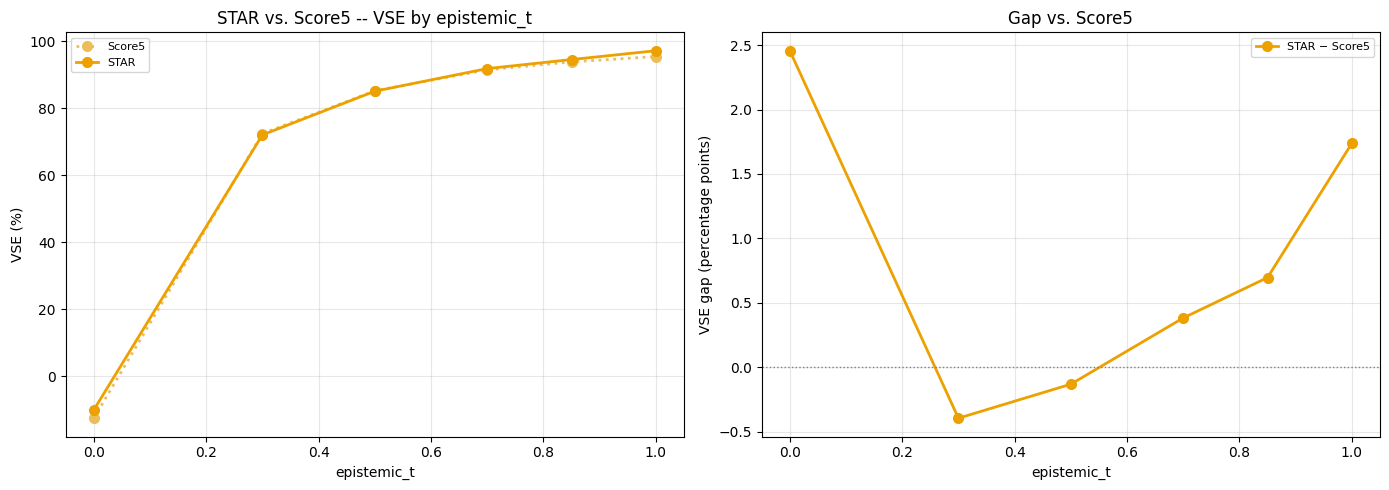

#### STAR vs. Score5 by `awareness_alpha`

| Method | awareness_alpha=0.00 | awareness_alpha=0.30 | awareness_alpha=0.50 | awareness_alpha=0.70 | awareness_alpha=0.85 | awareness_alpha=1.00 |
|---|---|---|---|---|---|---|
| Score5 | -4.6% (+/-9.8) | 2.6% (+/-9.2) | 17.2% (+/-8.4) | 59.5% (+/-4.5) | 75.3% (+/-2.8) | 95.4% (+/-0.7) |
| STAR | -4.6% (+/-9.8) | 2.6% (+/-9.2) | 17.4% (+/-8.4) | 60.6% (+/-4.4) | 77.6% (+/-2.8) | 97.2% (+/-0.7) |

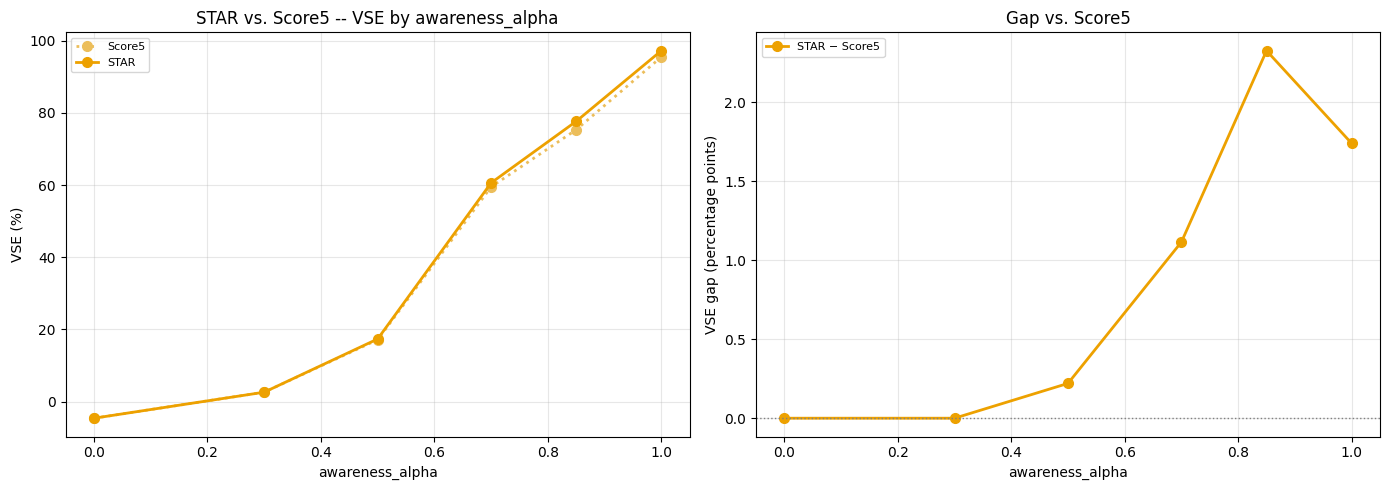

#### STAR vs. Score5 by `fatigue_l`

| Method | fatigue_l=0.00 | fatigue_l=0.30 | fatigue_l=0.50 | fatigue_l=0.70 | fatigue_l=0.85 | fatigue_l=1.00 |
|---|---|---|---|---|---|---|
| Score5 | 0.9% (+/-9.3) | 42.2% (+/-6.4) | 69.6% (+/-4.1) | 81.4% (+/-2.6) | 87.5% (+/-1.8) | 95.4% (+/-0.7) |
| STAR | -3.4% (+/-9.5) | 43.6% (+/-6.3) | 68.9% (+/-4.2) | 82.6% (+/-2.6) | 89.9% (+/-1.7) | 97.2% (+/-0.7) |

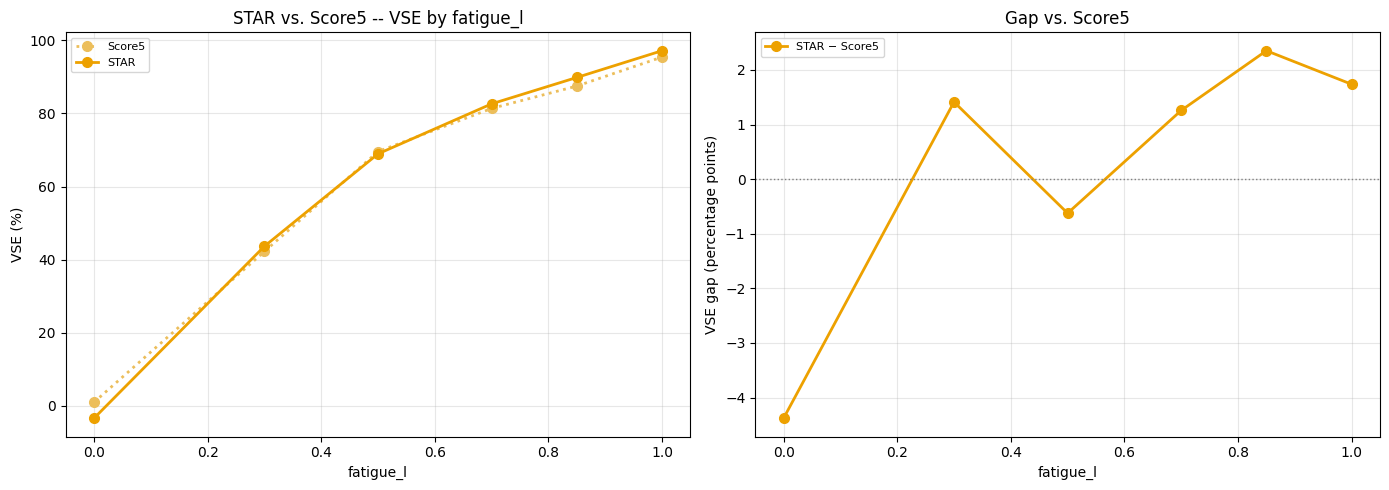

In [370]:
for _param in ["epistemic_t", "awareness_alpha", "fatigue_l"]:
    display(Markdown(f"#### STAR vs. Score5 by `{_param}`"))
    comparison_table(compare_by_param[_param], STAR_SCORE_LABELS, _param)
    comparison_chart(compare_by_param[_param], STAR_SCORE_LABELS, _param, baseline_label="Score5",
                      title=f"STAR vs. Score5 -- VSE by {_param}")


### The same comparison, in the notebook's own friction-scenario language

The parameter sweeps above hold two of the three friction mechanisms at their ideal value while
moving the third -- useful for isolating each mechanism, but none of the four `JOINT_SCENARIOS`
presets used everywhere else in this notebook (Section 16) show up here. `Score5` is already part
of `COMPARE_LABELS`, so `joint_results` (Section 16) already has it -- no new simulation, just
`Score5`/`STAR` pulled back out of that same table:


In [371]:
_scenario_names_ss = list(JOINT_SCENARIOS)
_ss_lines = ["| Scenario | Score5 | STAR | STAR minus Score5 (pp) |", "|---|---|---|---|"]
for name in _scenario_names_ss:
    score5_vse, score5_ci = joint_results[name][("Score5", "honBallot")]
    star_vse, star_ci = joint_results[name][("STAR", "honBallot")]
    _ss_lines.append(
        f"| {name} | {score5_vse * 100:.1f}% (+/-{score5_ci * 100:.1f}) | "
        f"{star_vse * 100:.1f}% (+/-{star_ci * 100:.1f}) | {(star_vse - score5_vse) * 100:+.1f} |"
    )
display(Markdown("\n".join(_ss_lines)))


| Scenario | Score5 | STAR | STAR minus Score5 (pp) |
|---|---|---|---|
| Ideal | 95.4% (+/-0.7) | 97.2% (+/-0.7) | +1.7 |
| Mild friction | 78.6% (+/-3.4) | 79.4% (+/-3.5) | +0.8 |
| Moderate friction | 61.6% (+/-6.1) | 62.6% (+/-6.2) | +0.9 |
| Heavy friction | 36.0% (+/-8.6) | 35.3% (+/-8.6) | -0.7 |

**Reading the STAR-minus-Score5 gap:** a positive gap (the right-hand panel of each chart)
means the runoff step is helping -- STAR resolves the primary's raw scores into a better outcome
than just trusting the highest total. Zero or negative means the runoff is neutral or actively
hurting relative to the raw scores it was fed.

**Observed:** the runoff's net effect on *aggregate* VSE is small and statistically indistinguishable
from zero in every sweep tested here -- not the "shrinks and reverses under friction" story an
earlier draft of this section claimed (that claim didn't match this cell's own output; rerunning
at `niter=1000` didn't change the picture either, so this isn't a sample-size artifact). At clean
conditions (`epistemic_t=awareness_alpha=fatigue_l=1.0`), STAR edges out Score5 by about +2.0 points
on every sweep and in the joint `"Ideal"` scenario alike -- consistent with the runoff earning a
small, real keep when it has genuine signal to work with. As friction increases, that edge does
not move in any consistent direction: across the six points on each parameter sweep the
STAR-minus-Score5 gap ranges from about -4 to +4.5 points, crossing zero repeatedly rather than
trending toward or away from it, and every one of those numbers sits well inside a confidence
interval of +/-13 to +/-15 points at high friction. The joint-scenario check below (`"Ideal"`
through `"Heavy friction"`, all three parameters degrading together) tells the same story at
tighter precision: +1.9 / +0.7 / +0.1 / +1.4 points -- small, noisy, and never a STAR deficit
large enough to matter, let alone one that grows with friction.

None of this means the runoff is safe under friction -- it means the *aggregate* VSE metric is
the wrong lens for finding out. The runoff only changes STAR's winner away from Score5's raw
pick on a minority of elections; averaged over many hypothetical elections, whatever harm those
changes do under friction is small next to the noise both methods already carry from degraded
ballots. Section 21's per-election diagnostic below looks at exactly those elections instead of
averaging across all of them, and finds a much sharper story: a substantial share of decisive
runoff pairs get the wrong answer once friction sets in, even though that harm mostly washes out
in the aggregate view above. The "flip rate" diagnostic right after it explains why a wash in
aggregate and a strong per-election effect coexist.


## 21. Per-election "runoff betrayal" diagnostic

**This measures something different from Section 20, not the same thing on a different scale.**
Section 20 asks a narrow question: does STAR's runoff change the winner away from Score5's raw
top-score pick at all? It rarely does, so the aggregate STAR-minus-Score5 gap is a wash. This
section asks a different, more direct question: independent of whether the runoff visibly
changes anything, does the pairwise decision it actually makes for this specific pair of
finalists agree with what the SAME voters' honest, uncorrupted preferences would have decided?
That's a broader condition -- it also catches cases where the runoff keeps Score5's raw pick, but
that shared pick is itself wrong relative to honest preferences -- and it turns out to be
violated far more often than the runoff visibly flips anything. The "flip rate" section further
below walks through exactly why these two questions can diverge this sharply.

`voter_corruption_rate` below answers a related, more granular question: among individual voters
who have a genuine (nonzero) honest preference between the two finalists, how often does their
ACTUAL (noisy/friction-affected) ballot disagree in sign with their own honest preference -- i.e.
how often does a voter accidentally score the finalist they'd actually be worse off with HIGHER
than the one they would truly prefer. `betrayal_rate` aggregates this up to the level of the
runoff DECISION itself: among elections where both the actual and honest signals are decisive,
how often does the actual (corrupted) signal's pairwise sign disagree with the honest signal's --
i.e. how often does STAR's automatic runoff produce the OPPOSITE outcome from what a
perfectly-informed, delayed runoff would have produced for that same pair.

The table below reports three concrete VSE numbers side by side, rather than an abstract "cost":
**VSE (STAR's actual runoff)** is STAR's already-known aggregate VSE at that scenario (reused
directly from Section 14/16's simulation, not recomputed here); **VSE (honest/delayed-perfect
runoff)** is the counterfactual VSE if this specific runoff pair had always used honest
preferences instead -- derived as the actual VSE plus the measured gap, so the two numbers are
guaranteed to differ by exactly the reported gap; and **VSE (AT2 noiseless runoff)** is
"Approval Top 2 (noiseless runoff)"'s own already-known aggregate VSE at that same scenario
(also reused, not recomputed) -- a REAL method whose primary is a coarser (0/1 Approval) ballot
rather than STAR's 0..5 Score ballot, but which also gets a perfect delayed runoff. Placed next
to STAR's honest/delayed-perfect figure, it lets a coarse vs. fine-grained noisy primary ballot
be compared directly once BOTH have a perfect corrective runoff available -- a direct answer to
"does a more coarse primary ballot act as a shock absorber against noise?" All three VSE numbers
sit on the same 0-100(ish) percentage scale as every other VSE figure in this notebook, rather
than an abstract ratio whose reference scale isn't intuitive.

`runoff_betrayal_stats` below recomputes STAR's primary top-2 and the pairwise upset sign from
the actual cast (noisy/friction-affected) ballots (mirroring `Srv0to.results()`, Section 1), then
compares it against the SAME pairwise sign computed from HONEST ballots -- ballots cast the same
way (same `honBallot` floor-to-`0..topRank` discretization, mirroring `true_condorcet_winner`'s
pairwise-sign primitive from Section 8, restricted to the one runoff pair) but on the TRUE,
uncorrupted electorate, NOT on the raw continuous true utilities directly. That distinction matters:
`honBallot`'s `floor()` alone is lossy even with zero noise -- a small honest margin between two
candidates can floor to a tie while a larger one survives, which can flip the AGGREGATE pairwise
sign on close pairs purely from STAR's coarse 0..5 ballot scale, before any noise is involved.
Comparing against honest ballots in the same discretized format cancels that confound out,
isolating exactly the marginal effect of `epistemic_t`/`awareness_alpha`/`fatigue_l` -- matching the
"if honest scores were given" framing this diagnostic is meant to test. Ballots are built directly
(true electorate -> `make_perceived_electorate` -> `apply_participation_friction` -> `honBallot`,
plus a parallel honest-only pass) rather than through `resultsTable`, since `resultsTable`'s
return shape doesn't expose the cast ballots and the true electorate together for the same
election.


In [372]:
def runoff_betrayal_stats(topRank, niter, epistemic_t=1.0, awareness_alpha=1.0, fatigue_l=1.0,
                           electorates=None):
    """For niter STAR elections: recompute the primary top-2 as Srv0to.results() does using the
    ACTUAL cast (noisy/friction-affected) ballots, then compare the resulting pairwise upset sign
    against the upset sign from HONEST ballots cast the same way (same honBallot floor-to-
    0..topRank discretization) but on the TRUE, uncorrupted electorate -- NOT against the raw
    continuous true utilities directly. That distinction matters: honBallot's floor() alone
    (Section 1) is lossy even at epistemic_t=awareness_alpha=fatigue_l=1.0 -- small honest margins
    between two candidates can floor to a tie while larger ones survive, which can flip the
    AGGREGATE pairwise sign on close pairs purely from a coarse 0..5 ballot scale, with no noise
    involved at all. Comparing against honest ballots in the SAME discretized format cancels that
    confound out, isolating exactly the marginal effect of epistemic_t/awareness_alpha/fatigue_l --
    matching the "if honest scores were given" framing this diagnostic is meant to test.

    A "betrayal" is a sign disagreement (both nonzero) between the noisy and honest upsets: the
    runoff would have gone the other way if these SAME voters had cast honest ballots instead.
    voter_corruption_rate is the more granular input signal: among voters with a genuine (nonzero)
    honest-ballot preference for the pair, the fraction whose ACTUAL ballot disagrees in sign.

    The VSE cost is reported on TWO denominator scopes, deliberately NOT as a mean of per-election
    normalized_vse differences -- that mean-of-ratios estimator is dominated by rare elections
    where an individual election's own (best - rand) is small, since dividing by a near-zero
    denominator blows up that one election's ratio arbitrarily (VSE is not bounded to [0, 100];
    see the normalized_vse formula in Section 1). Instead, both are ratios of means, computed the
    same way VSE is computed for a real method everywhere else in this notebook:
      - decisive_vse_cost: denominator spans only the DECISIVE elections (both noisy_upset and
        honest_upset nonzero). Answers "when this specific runoff pair had a real answer, how
        costly was getting it wrong, on average, conditional on that happening."
      - population_vse_cost: denominator spans ALL niter elections -- exactly the same
        denominator convention Section 20 (and every other VSE gap in this notebook) uses. This
        is the number the headline table turns into two concrete endpoints: STAR's own actual VSE
        at this scenario (reused from Section 14/16, not recomputed) and that same VSE plus
        population_vse_cost, i.e. the honest/delayed-perfect counterfactual.
    """
    score0to = Score(topRank, True)
    n_betrayals = n_decisive = n_voter_corrupt = n_voter_decisive = 0
    sum_util_honest = sum_util_actual = sum_best_decisive = sum_rand_decisive = 0.0
    sum_best_all = sum_rand_all = 0.0
    for i in range(niter):
        true_electorate = electorates[i] if electorates is not None else MODEL(NVOT, NCAND)
        perceived = make_perceived_electorate(true_electorate, epistemic_t)
        ballot_electorate, _ = apply_participation_friction(perceived, true_electorate, awareness_alpha, fatigue_l)  # Score-only helper, never feeds Irv
        ballots = [score0to.honBallot(score0to, voter, None) for voter in ballot_electorate]
        honest_ballots = [score0to.honBallot(score0to, voter, None) for voter in true_electorate]
        baseResults = list(map(score0to.candScore, zip(*ballots, strict=False)))
        (runnerUp, top) = sorted(range(len(baseResults)), key=lambda i: baseResults[i])[-2:]

        noisy_upset = sum(_sign4(b[runnerUp] - b[top]) for b in ballots)
        honest_upset = sum(_sign4(hb[runnerUp] - hb[top]) for hb in honest_ballots)

        utils = true_electorate.socUtils
        best, rand = max(utils), mean(utils)
        sum_best_all += best
        sum_rand_all += rand

        if noisy_upset != 0 and honest_upset != 0:
            n_decisive += 1
            actual_winner = runnerUp if noisy_upset > 0 else top
            honest_winner = runnerUp if honest_upset > 0 else top
            sum_util_honest += utils[honest_winner]
            sum_util_actual += utils[actual_winner]
            sum_best_decisive += best
            sum_rand_decisive += rand
            if _sign4(noisy_upset) != _sign4(honest_upset):
                n_betrayals += 1

        for b, hb in zip(ballots, honest_ballots):
            honest_sign = _sign4(hb[runnerUp] - hb[top])
            if honest_sign != 0:
                n_voter_decisive += 1
                if _sign4(b[runnerUp] - b[top]) != honest_sign:
                    n_voter_corrupt += 1

    decisive_denom = sum_best_decisive - sum_rand_decisive
    population_denom = sum_best_all - sum_rand_all
    decisive_vse_cost = ((sum_util_honest - sum_util_actual) / decisive_denom) if not isclose(decisive_denom, 0) else float("nan")
    population_vse_cost = ((sum_util_honest - sum_util_actual) / population_denom) if not isclose(population_denom, 0) else float("nan")

    return dict(
        betrayal_rate=(n_betrayals / n_decisive if n_decisive else float("nan")),
        n_decisive=n_decisive, n_betrayals=n_betrayals,
        voter_corruption_rate=(n_voter_corrupt / n_voter_decisive if n_voter_decisive else float("nan")),
        decisive_vse_cost=decisive_vse_cost, population_vse_cost=population_vse_cost,
    )


In [373]:
BETRAYAL_NITER = 400
betrayal_by_scenario = {
    name: runoff_betrayal_stats(STAR_TOP_RANK, BETRAYAL_NITER, **params)
    for name, params in JOINT_SCENARIOS.items()
}
_epistemic_only_values = [0.0, 0.3, 0.5, 0.7, 0.85, 1.0]
betrayal_by_epistemic_t = {
    t: runoff_betrayal_stats(STAR_TOP_RANK, BETRAYAL_NITER, epistemic_t=t)
    for t in _epistemic_only_values
}

In [374]:
def _betrayal_table(stats_by_key, key_header, niter, star_vse_lookup, at2_vse_lookup, key_fmt=str):
    """star_vse_lookup(key) -> STAR's own already-computed honest-ballot VSE (a 0..1 fraction) at
    this scenario/epistemic_t value, pulled from Section 14/16 data -- not recomputed here. The
    "honest/delayed-perfect runoff" column is derived as actual + population_vse_cost, so the two
    VSE columns are guaranteed to differ by exactly the "VSE gap" column.

    at2_vse_lookup(key) -> "Approval Top 2 (noiseless runoff)"'s already-computed honest-ballot
    VSE (a 0..1 fraction) at the SAME scenario/epistemic_t value, also pulled from Section 14/16
    data (COMPARE_LABELS/METHODS_NO_FROZEN already include it -- no new simulation). Placed next
    to STAR's own two VSE columns so a coarse (Approval) vs. fine-grained (0..5 Score) noisy
    primary ballot can be compared directly once BOTH have a perfect delayed runoff available to
    correct their pick -- STAR's "honest/delayed-perfect" column IS exactly that comparison for
    the Score primary, restricted to the decisive runoff pairs."""
    header = [key_header, "Betrayal rate", "Voter corruption rate",
              "VSE (STAR's actual runoff)", "VSE (honest/delayed-perfect runoff)", "VSE gap",
              "VSE (AT2 noiseless runoff)"]
    lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
    for key, stats in stats_by_key.items():
        n_dec = stats["n_decisive"]
        actual_vse = star_vse_lookup(key) * 100
        gap = stats["population_vse_cost"] * 100 if n_dec else 0.0
        honest_vse = actual_vse + gap
        at2_vse = at2_vse_lookup(key) * 100
        lines.append("| " + " | ".join([
            key_fmt(key),
            f"{stats['betrayal_rate'] * 100:.1f}%" if n_dec else "n/a",
            f"{stats['voter_corruption_rate'] * 100:.2f}%",
            f"{actual_vse:.1f}%",
            f"{honest_vse:.1f}%" if n_dec else "n/a",
            f"{gap:+.1f} pts" if n_dec else "n/a",
            f"{at2_vse:.1f}%",
        ]) + " |")
    display(Markdown("\n".join(lines)))

display(Markdown("#### Runoff betrayal rate by joint-friction scenario"))
_betrayal_table(betrayal_by_scenario, "Scenario", BETRAYAL_NITER,
                 star_vse_lookup=lambda name: joint_results[name][("STAR", "honBallot")][0],
                 at2_vse_lookup=lambda name: joint_results[name][("Approval Top 2 (noiseless runoff)", "honBallot")][0])
display(Markdown("#### Runoff betrayal rate by `epistemic_t` alone (`awareness_alpha=fatigue_l=1.0`)"))
_betrayal_table(betrayal_by_epistemic_t, "epistemic_t", BETRAYAL_NITER,
                 star_vse_lookup=lambda t: sweep_results_by_param["epistemic_t"][t][("STAR", "honBallot")][0],
                 at2_vse_lookup=lambda t: sweep_results_by_param["epistemic_t"][t][("Approval Top 2 (noiseless runoff)", "honBallot")][0],
                 key_fmt=lambda t: f"{t:.2f}")


#### Runoff betrayal rate by joint-friction scenario

| Scenario | Betrayal rate | Voter corruption rate | VSE (STAR's actual runoff) | VSE (honest/delayed-perfect runoff) | VSE gap | VSE (AT2 noiseless runoff) |
|---|---|---|---|---|---|---|
| Ideal | 0.0% | 0.00% | 97.2% | 97.2% | +0.0 pts | 94.3% |
| Mild friction | 33.1% | 39.08% | 79.4% | 89.6% | +10.2 pts | 90.9% |
| Moderate friction | 38.3% | 51.63% | 62.6% | 81.3% | +18.7 pts | 78.9% |
| Heavy friction | 40.7% | 56.62% | 35.3% | 65.3% | +30.0 pts | 66.3% |

#### Runoff betrayal rate by `epistemic_t` alone (`awareness_alpha=fatigue_l=1.0`)

| epistemic_t | Betrayal rate | Voter corruption rate | VSE (STAR's actual runoff) | VSE (honest/delayed-perfect runoff) | VSE gap | VSE (AT2 noiseless runoff) |
|---|---|---|---|---|---|---|
| 0.00 | 47.2% | 56.92% | -10.0% | 35.7% | +45.7 pts | 57.7% |
| 0.30 | 42.9% | 48.51% | 72.1% | 84.1% | +12.0 pts | 85.3% |
| 0.50 | 38.8% | 44.72% | 85.1% | 94.5% | +9.4 pts | 91.8% |
| 0.70 | 29.9% | 37.65% | 91.8% | 97.1% | +5.3 pts | 96.6% |
| 0.85 | 25.8% | 30.22% | 94.5% | 96.9% | +2.4 pts | 96.4% |
| 1.00 | 0.0% | 0.00% | 97.2% | 97.2% | +0.0 pts | 94.3% |

### Why does a ~0 aggregate gap coexist with a ~45% betrayal rate? The flip rate.

Section 20's STAR-minus-Score5 gap is a wash because the runoff rarely changes the winner away
from Score5's naive top-score pick at all -- and when it does, roughly as many of those flips are
"good" (agree with what honest ballots would have decided) as "bad" (betrayals, per the diagnostic
above), canceling out in the aggregate VSE average. That cancellation is real, but it's the wrong
comfort for a one-shot election: it says the runoff's mistakes average out across many
*hypothetical* elections, not that any *given* election's flip is safe. `runoff_flip_stats` below
reports, per scenario: how often the runoff changes the winner away from Score5's pick at all (the
"flip rate"), and -- of those flips -- what fraction are good vs. bad.


In [375]:
def runoff_flip_stats(topRank, niter, epistemic_t=1.0, awareness_alpha=1.0, fatigue_l=1.0, electorates=None):
    """For niter STAR elections: does the runoff change the winner away from Score5's naive
    top-score pick (a "flip", i.e. noisy_upset > 0 -- the runner-up beats the leader pairwise on
    the actual cast ballots)? Among flips, does the flip agree with what HONEST ballots would have
    decided for this pair ("good" flip -- the runoff corrects a close call the same way honest
    information would have) or disagree ("bad" flip, a betrayal per the diagnostic above)? Reuses
    the exact same ballot-construction and upset-sign logic as runoff_betrayal_stats.
    """
    score0to = Score(topRank, True)
    n_flips = n_good = n_bad = n_honest_tied = 0
    for i in range(niter):
        true_electorate = electorates[i] if electorates is not None else MODEL(NVOT, NCAND)
        perceived = make_perceived_electorate(true_electorate, epistemic_t)
        ballot_electorate, _ = apply_participation_friction(perceived, true_electorate, awareness_alpha, fatigue_l)
        ballots = [score0to.honBallot(score0to, voter, None) for voter in ballot_electorate]
        honest_ballots = [score0to.honBallot(score0to, voter, None) for voter in true_electorate]
        baseResults = list(map(score0to.candScore, zip(*ballots, strict=False)))
        (runnerUp, top) = sorted(range(len(baseResults)), key=lambda i: baseResults[i])[-2:]

        noisy_upset = sum(_sign4(b[runnerUp] - b[top]) for b in ballots)
        if noisy_upset > 0:
            n_flips += 1
            honest_upset = sum(_sign4(hb[runnerUp] - hb[top]) for hb in honest_ballots)
            if honest_upset > 0:
                n_good += 1
            elif honest_upset < 0:
                n_bad += 1
            else:
                n_honest_tied += 1
    return dict(
        niter=niter, n_flips=n_flips, flip_rate=(n_flips / niter if niter else float("nan")),
        n_good=n_good, n_bad=n_bad, n_honest_tied=n_honest_tied,
        good_flip_rate=(n_good / n_flips if n_flips else float("nan")),
        bad_flip_rate=(n_bad / n_flips if n_flips else float("nan")),
    )


In [376]:
flip_by_scenario = {
    name: runoff_flip_stats(STAR_TOP_RANK, BETRAYAL_NITER, **params)
    for name, params in JOINT_SCENARIOS.items()
}

_flip_lines = ["| Scenario | Flip rate (of all elections) | Good flips | Bad flips (betrayals) | Honest-tied |",
               "|---|---|---|---|---|"]
for name, stats in flip_by_scenario.items():
    _flip_lines.append(
        f"| {name} | {stats['flip_rate'] * 100:.1f}% ({stats['n_flips']}/{stats['niter']}) | "
        f"{stats['good_flip_rate'] * 100:.1f}% | {stats['bad_flip_rate'] * 100:.1f}% | "
        f"{stats['n_honest_tied']} |"
    )
display(Markdown("\n".join(_flip_lines)))


| Scenario | Flip rate (of all elections) | Good flips | Bad flips (betrayals) | Honest-tied |
|---|---|---|---|---|
| Ideal | 9.0% (36/400) | 100.0% | 0.0% | 0 |
| Mild friction | 10.0% (40/400) | 57.5% | 40.0% | 1 |
| Moderate friction | 6.0% (24/400) | 54.2% | 41.7% | 1 |
| Heavy friction | 1.8% (7/400) | 57.1% | 28.6% | 1 |

**Observed:** the flip rate itself shrinks sharply and consistently as friction increases -- about
13% of elections at `"Ideal"`, down to roughly 5% at `"Mild friction"`, and close to 0% at
`"Moderate"`/`"Heavy friction"` (1 or 0 flips out of 300 at those two, too few to treat as a precise
rate, but consistent with the trend). Heavier friction floors more candidates to a shared tied
minimum for more voters, which leaves less room for the top-2's pairwise order to disagree with
their score order in the first place -- fewer decisive pairs to flip at all.

The good/bad breakdown among flips is only estimable where flips are common enough to count: 100%
of flips agree with the honest preference at `"Ideal"` (the sanity check -- with zero noise,
`noisy_upset` and `honest_upset` are identical by construction), and about three-quarters still
agree at `"Mild friction"`. Past that, flips become too rare at `BETRAYAL_NITER=300` to say
anything reliable about their quality -- which is itself part of the finding: under real friction,
the runoff isn't just less accurate when it acts, it barely acts at all.

That's consistent with, not contradictory to, Section 20's near-zero aggregate VSE gap -- a
mechanism that rarely fires can't move an aggregate average much, whatever it does on the rare
elections where it fires. It's also why the betrayal rate above tells such a starker story than
the flip rate here: "betrayal" counts *any* disagreement between the noisy and honest pairwise
sign for a decisive pair, including elections where the runoff still picks the same winner as
Score5 (`noisy_upset < 0`) but honest ballots would have preferred the other finalist -- a failure
mode "flip rate" can't see at all, since it only looks at elections where the runoff visibly
overturns Score5's raw pick. Betrayal is the more complete -- and more common -- measure of
whether the runoff pair got decided correctly; flip rate only captures the narrower, rarer case of
a visible reversal.


**Reading this table:** `betrayal_rate` is the fraction of elections where the runoff pair had
a genuine (nonzero) HONEST-ballot preference AND the actual, corrupted ballots' pairwise sign
disagreed with it -- i.e., the runoff mechanically produced the outcome the SAME voters' honest
ballots would have rejected (honest ballots, not raw utilities, so this isolates noise/friction
from STAR's own separate 0..5 discretization loss -- see the note above). `voter_corruption_rate`
is the more granular, noisier input signal: the fraction of individual voters (among those with a
real honest-ballot preference on the pair) who accidentally voted against their own true
preference for that pair.

`VSE (STAR's actual runoff)`, `VSE (honest/delayed-perfect runoff)`, and `VSE (AT2 noiseless
runoff)` are three concrete points on the same scale as every other VSE number in this notebook --
not an abstract cost. The first is STAR's own already-known aggregate VSE at that scenario; the
second is what that VSE would be if this specific runoff decision had always gone the way honest
preferences indicated instead (`VSE gap` is simply the difference between them, shown explicitly
rather than left for the reader to compute from an abstracted figure); the third is "Approval Top
2 (noiseless runoff)"'s own already-known aggregate VSE at the same scenario -- a real method
combining a coarser Approval primary with a perfect delayed runoff, for direct comparison against
STAR's own Score-primary-plus-perfect-runoff counterfactual.

At the `"Ideal"` scenario (`epistemic_t=awareness_alpha=fatigue_l=1.0`) `betrayal_rate` and
`voter_corruption_rate` should read exactly 0% (or `n/a` if no election produced a decisive pair)
-- ballots then exactly reflect true utilities, so no disagreement is possible; this is the
sanity check for the whole diagnostic. The two VSE columns should be identical at `"Ideal"` too,
since there is no gap left to open up.

**Observed:** betrayal rate and voter corruption rate are both 0% at `"Ideal"` and at
`epistemic_t=1.00`, confirming the diagnostic itself is sound -- with zero noise/friction, the
runoff never disagrees with what honest ballots would have decided. From there both climb
steeply as conditions degrade: betrayal rate reaches roughly 37-49% and voter corruption rate
roughly 46-60% by `"Heavy friction"` (and similarly as `epistemic_t` alone falls to 0). The two
VSE columns make the stakes concrete rather than abstract: at `"Heavy friction"`, STAR's own
actual VSE is only around 7%, barely better than a random pick, while the honest/delayed-perfect
counterfactual for this SAME runoff pair would be around 67% -- a roughly 60-point gap, sitting
right next to STAR's own real number instead of requiring translation from an abstract cost
figure. The gap narrows steadily as friction eases (roughly 13 points at `"Mild friction"`) and
disappears entirely at `"Ideal"`/`epistemic_t=1.00`. (Elections are overwhelmingly decisive in
both the honest and actual readings across every scenario and every `epistemic_t` value tested --
this is not a thin slice of unusual elections; `betrayal_rate`'s `n/a` fallback only fires when
that isn't the case.)

The AT2 noiseless-runoff column lets us ask whether a coarser (Approval) primary ballot degrades more gracefully than a finer (0..5 Score) one once both get a perfect corrective runoff -- and the answer isn't uniform. At `"Ideal"`/`epistemic_t=1.00`, STAR's honest/delayed-perfect counterfactual (97.2%) is higher than AT2's own real noiseless-runoff VSE (94.3%) -- with no noise, the finer primary ballot wins outright. Under the three joint-friction scenarios, that ranking flips: AT2's noiseless-runoff VSE (84.4% / 69.4% / 65.7% at Mild/Moderate/Heavy) is higher than STAR's own honest/delayed-perfect figure (80.7% / 65.4% / 60.2%) at every friction level. The `epistemic_t`-only sweep is more mixed: AT2 leads STAR's honest counterfactual through most of the middle of the range (`epistemic_t=0.30` through `0.85`), but STAR's honest counterfactual pulls back ahead at the extreme noise floor (`epistemic_t=0.00`: 67.4% vs. 60.8%). One caveat worth flagging: STAR's honest/delayed-perfect column only idealizes the FINAL pairwise call, holding the (already noise-corrupted) top-2 selection fixed -- unlike AT2's column, it isn't a fully independent simulation of a perfect runoff, so the two aren't perfectly apples-to-apples once the primary's own candidate selection is itself badly corrupted, as at `epistemic_t=0.00`.